
# TITLE_SLIDE
# Trinity University Football
## Offensive EPA Analysis

### Offensive Performance · Multi-Season Review

---

**Presented by:** Sebastian Trevino & Dr. Eduardo Cabral Balreira



## What We Set Out to Do

The goal of this project is simple:

> **Move beyond the box score and understand the true value of every offensive play.**

Traditional stats — yards, completions, yards per carry — tell us *what happened.*
They don't tell us if it was *good.*

- **A 4-yard gain on 3rd & 3** → Success. Drive continues.
- **A 4-yard gain on 3rd & 10** → Failure. Drive dies.

Averages treat both plays the same. **EPA does not.**



## Why Expected Points Added (EPA)?

At any moment — given **down, distance, and field position** — we can estimate how many points a team is expected to score on that drive.

**EPA measures how much a single play moves that number.**

| Result | What it means |
|---|---|
| EPA > 0 | Play helped us — moved chains, created leverage |
| EPA < 0 | Play hurt us — behind schedule, stalled drive |
| EPA = 0 | Neutral — no gain, no loss in scoring probability |

**Model baseline: +0.028 EPA per play.**
**Our average: +0.057 EPA per play.**
On average, we beat the baseline and produce positive  offensive value.
Beating this consistently separates productive series from stalled drives.



## What This Report Answers

Seven questions every offensive staff should be asking:

- **Are we generating positive value** play-to-play?
- **Where situationally do we succeed** — and where do we fail?
- **Are we calling the right plays** in the right situations?
- **Does our scheme** — personnel and formation — produce value?
- **Are we generating explosive plays**, and from where on the field?
- **How do our drives actually unfold** from first play to last?
- **What separates our wins from our losses?**


## HIDDEN_SLIDE Setup — Libraries & Data Load

In [1]:

import os
import re
import glob
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from plotly.io import to_html

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# ── Global style constants ─────────────────────────────────────────────────
TU_BLUE        = '#002868'
TU_GOLD        = '#C5960C'
WIN_COLOR      = '#1D9E75'
LOSS_COLOR     = '#C0392B'
RED            = '#C0392B'
LIGHT_GRAY     = '#F5F5F5'
MODEL_BASELINE = 0.028

# df and tu_df are injected from the calling session by build_report().
# No file I/O needed — the data is already in memory.
print(f"df:    {len(df):,} rows × {df.shape[1]} columns")
print(f"tu_df: {len(tu_df):,} rows")


## HIDDEN_SLIDE Data Reshaping

In [2]:

game_names = (
    df[df["odk"] == "o"]
    .groupby("game_id")[["team_name", "opp_name"]]
    .first()
    .reset_index()
)
df = df.drop(columns=["team_name", "opp_name"])
df = df.merge(game_names, on="game_id", how="left")

# Build Trinity-only dataframe
tu_df = (
    df[df['team_name'] == 'TU']
    .sort_values(['game_id', 'play'])
    .reset_index(drop=True)
)
print(f"TU rows: {len(tu_df):,}")

print("\n--- EP by odk ---")
print(tu_df.groupby('odk')['ep'].describe().round(3))
print("\n--- EPA by odk ---")
print(tu_df.groupby('odk')['epa'].describe().round(3))



## 1 · EPA by Down
> **So what?** Negative 1st down EPA = playing from behind all game. Negative 3rd down EPA = drives dying.


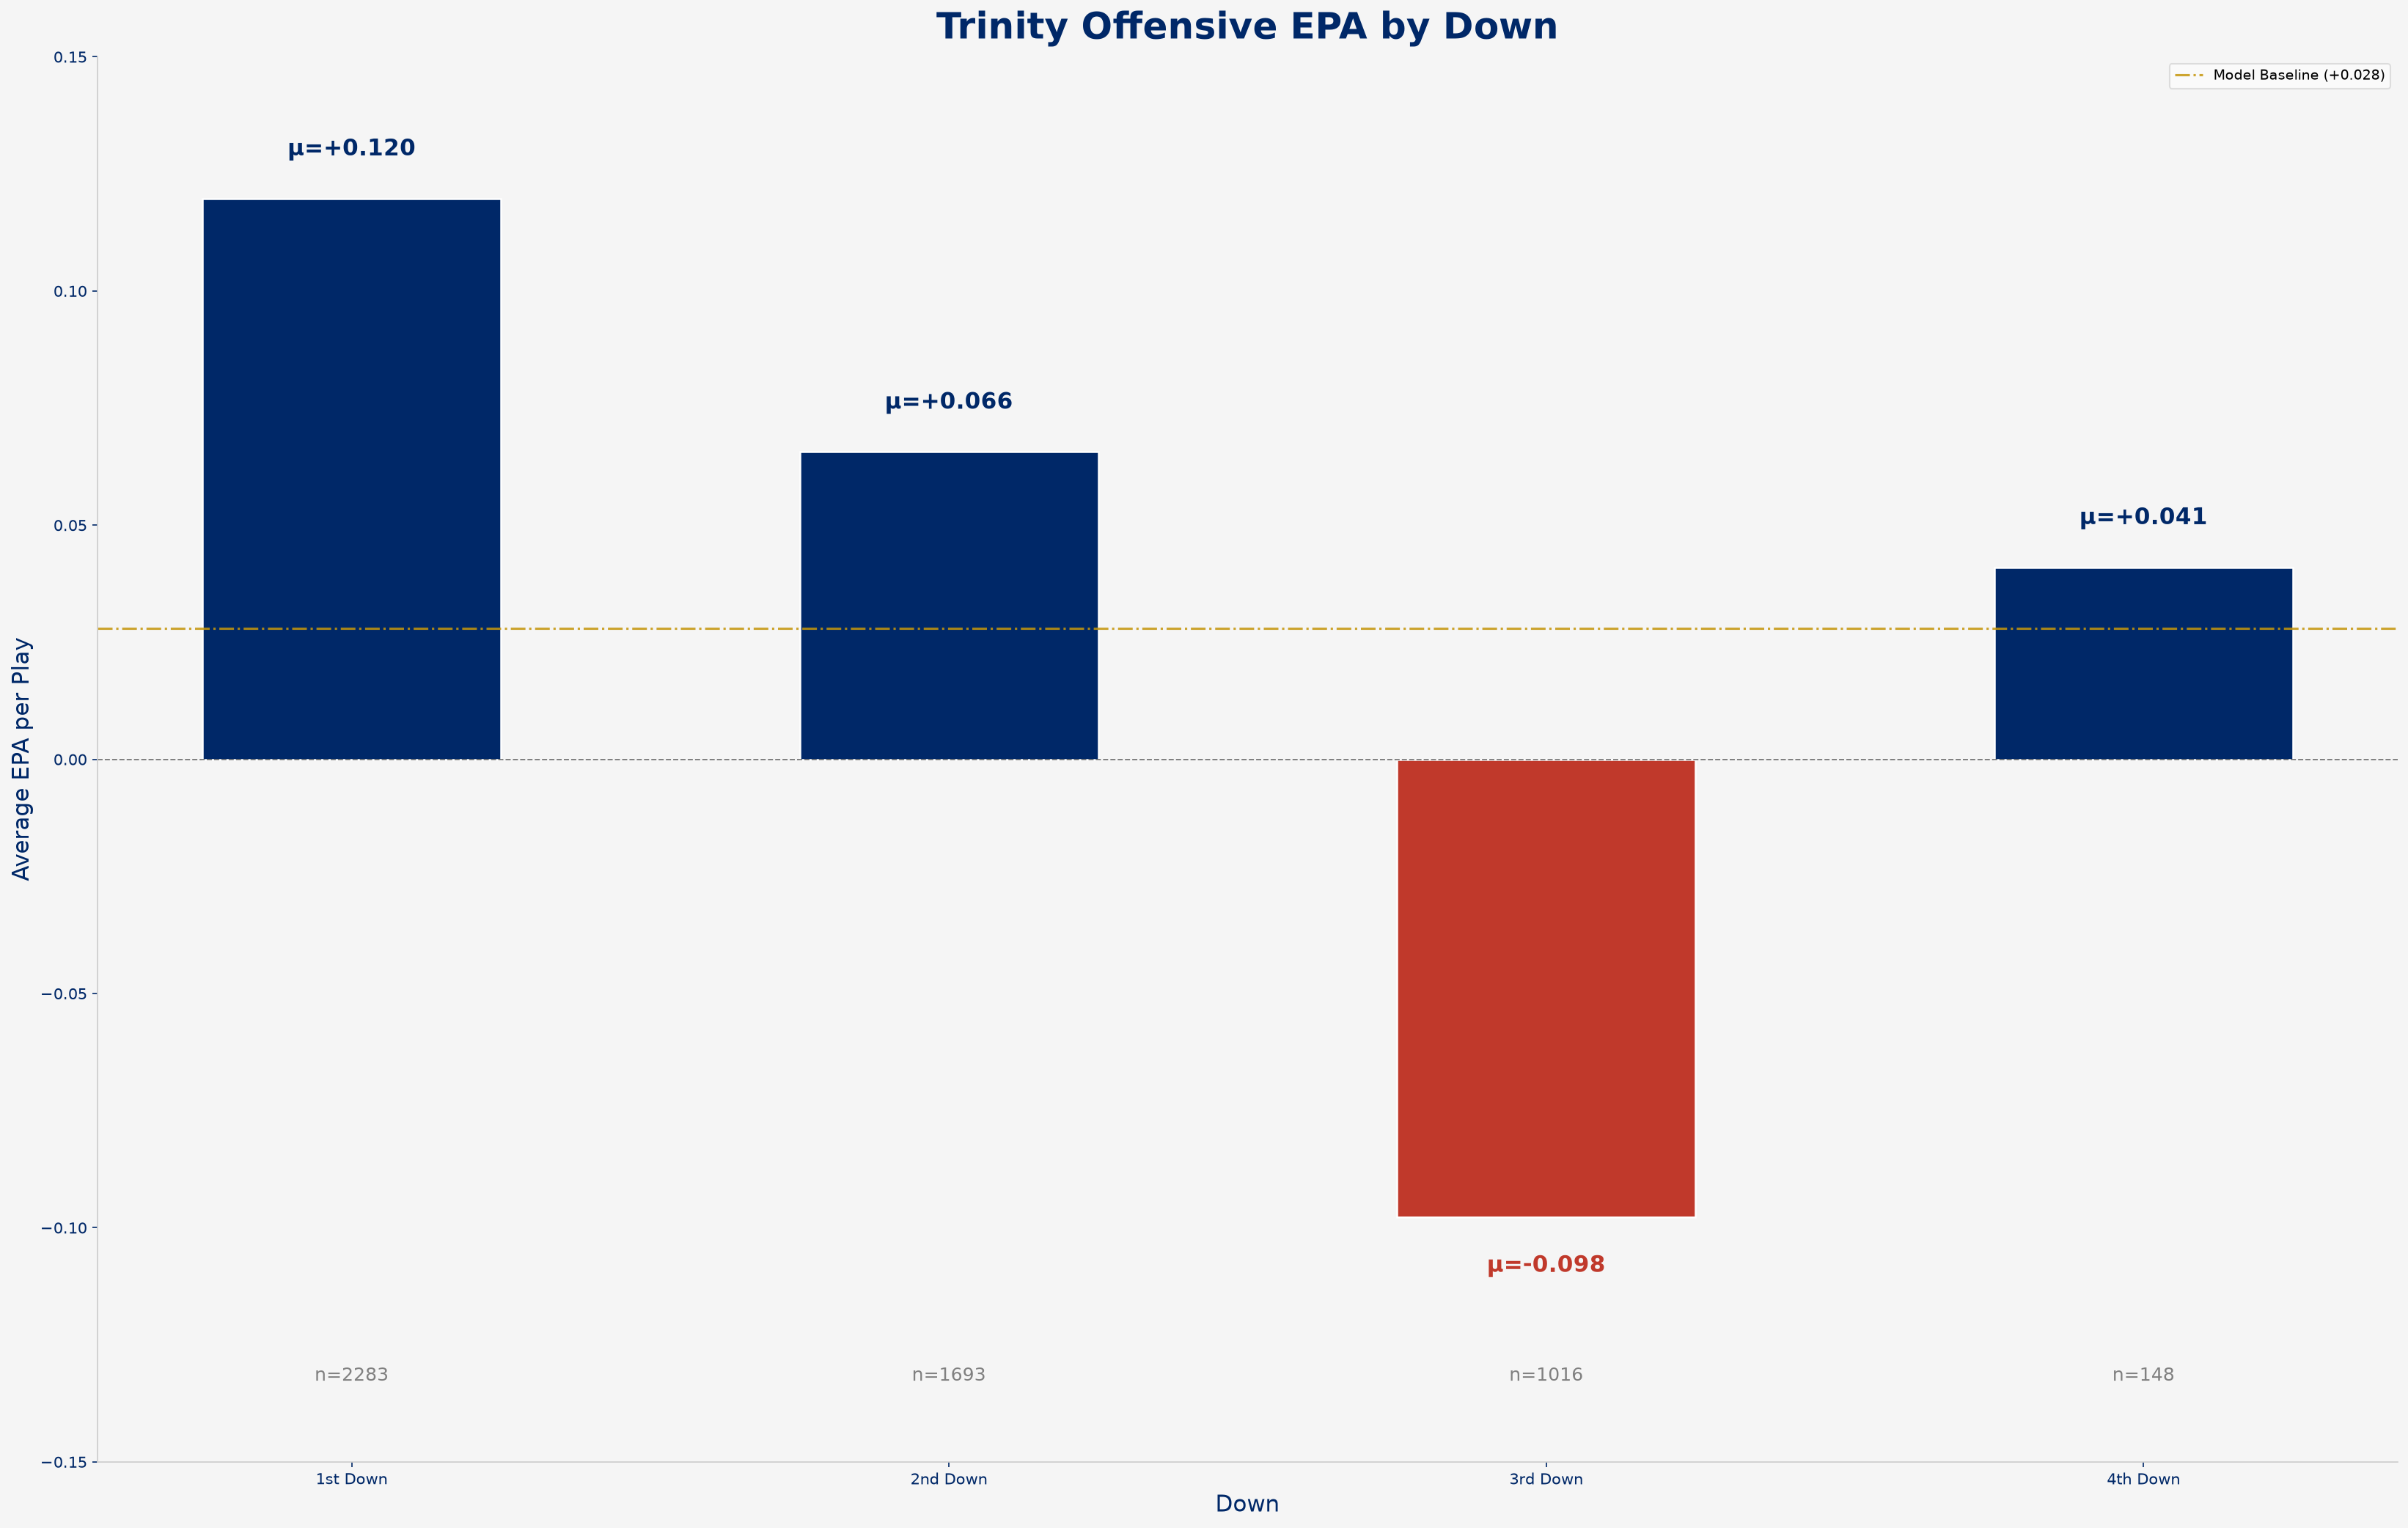

In [3]:

off_df = tu_df[(tu_df['odk'] == 'o') & (tu_df['epa'].notna())].copy()

down_df = (
    off_df[off_df['dn'].isin([1, 2, 3, 4])]
    .groupby('dn')['epa']
    .agg(['mean', 'sem', 'count'])
    .reset_index()
)
down_df['dn_label'] = down_df['dn'].map(
    {1: '1st Down', 2: '2nd Down', 3: '3rd Down', 4: '4th Down'}
)

fig, ax = plt.subplots(figsize=(22, 14))
fig.patch.set_facecolor(LIGHT_GRAY)
ax.set_facecolor(LIGHT_GRAY)

bars = ax.bar(
    down_df['dn_label'], down_df['mean'],
    color=[TU_BLUE if v >= 0 else RED for v in down_df['mean']],
    edgecolor='white', linewidth=1.2, width=0.5
)
ax.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.5)
ax.axhline(MODEL_BASELINE, color=TU_GOLD, linewidth=1.5, linestyle='-.',
           alpha=0.85, label='Model Baseline (+0.028)')
ax.legend(fontsize=9, framealpha=0.6, edgecolor='#CCCCCC')

for bar, row in zip(bars, down_df.itertuples()):
    label_y = row.mean + 0.008 if row.mean >= 0 else row.mean - 0.008
    va      = 'bottom' if row.mean >= 0 else 'top'
    ax.text(bar.get_x() + bar.get_width() / 2, label_y,
            f'μ={row.mean:+.3f}', ha='center', va=va,
            fontsize=15, fontweight='bold',
            color=TU_BLUE if row.mean >= 0 else RED)
    ax.text(bar.get_x() + bar.get_width() / 2, ax.get_ylim()[0] - 0.025,
            f'n={row.count}', ha='center', va='bottom', fontsize=12, color='gray')

ax.set_title('Trinity Offensive EPA by Down', fontsize=24,
             fontweight='bold', color=TU_BLUE, pad=12)
ax.set_xlabel('Down', fontsize=15, color=TU_BLUE)
ax.set_ylabel('Average EPA per Play', fontsize=15, color=TU_BLUE)
ax.tick_params(colors=TU_BLUE)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#CCCCCC')
ax.set_ylim(bottom=-0.15, top=0.15)
plt.tight_layout()
plt.show()



## 2 · EPA vs. Our Opponents
> **So what?** Green = win, Red = loss. Consistent negative EPA vs. a specific opponent signals a schematic problem worth targeting.


In [4]:

off_df = tu_df[(tu_df['odk'] == 'o') & (tu_df['epa'].notna())].copy()

game_meta = (
    off_df.groupby('game_id')
    .agg(opp_name=('opp_name','first'), game_date=('game_date','first'),
         win=('win','first'), mean_epa=('epa','mean'),
         sem_epa=('epa','sem'), n_plays=('epa','count'))
    .reset_index()
)
game_meta['game_date_parsed'] = pd.to_datetime(game_meta['game_date'], format='%m/%d/%Y')
game_meta['year'] = game_meta['game_date_parsed'].dt.year
game_meta['label'] = game_meta.apply(
    lambda r: f"{r['opp_name']} ({r['year']} {'W' if r['win']==1 else 'L'})", axis=1
)

all_years    = sorted(game_meta['year'].unique())
all_opps     = sorted(game_meta['opp_name'].unique())
overall_mean = off_df['epa'].mean()

fig       = go.Figure()
trace_map = {}

def make_trace(subset, sort_by, ascending, scope_key, visible):
    subset = subset.sort_values(sort_by, ascending=ascending).reset_index(drop=True)
    colors = [WIN_COLOR if w == 1 else LOSS_COLOR for w in subset['win']]
    hover  = [f"<b>{r['label']}</b><br>EPA/play: {r['mean_epa']:+.3f}<br>Plays: {int(r['n_plays'])}"
              for _, r in subset.iterrows()]
    idx = len(fig.data)
    fig.add_trace(go.Bar(
        x=subset['mean_epa'], y=subset['label'], orientation='h',
        marker_color=colors, marker_line_color='white', marker_line_width=1.2,
        text=hover, hovertemplate='%{text}<extra></extra>',
        visible=visible, name=scope_key, showlegend=False,
    ))
    trace_map[scope_key] = idx

season_scopes = ['All'] + [str(y) for y in all_years]
for scope in season_scopes:
    sub = game_meta if scope == 'All' else game_meta[game_meta['year'] == int(scope)]
    make_trace(sub.copy(), 'mean_epa', True, f'season_{scope}', visible=(scope == 'All'))

for opp in all_opps:
    make_trace(game_meta[game_meta['opp_name'] == opp].copy(),
               'game_date_parsed', True, f'opp_{opp}', visible=False)

total_traces = len(fig.data)
make_vis = lambda k: [i == trace_map[k] for i in range(total_traces)]

season_buttons = []
for scope in season_scopes:
    sub = game_meta if scope == 'All' else game_meta[game_meta['year'] == int(scope)]
    nw, nl = int(sub['win'].sum()), len(sub) - int(sub['win'].sum())
    season_buttons.append(dict(
        label=scope, method='update',
        args=[{'visible': make_vis(f'season_{scope}')},
              {'title.text': f'<b>TU Offensive EPA per Play by Opponent</b> — '
               f'{"All Seasons" if scope=="All" else scope}<br>'
               f'<sup>{len(sub)} games · {nw}W–{nl}L · Avg: {sub["mean_epa"].mean():+.3f}</sup>',
               'yaxis.autorange': True}]
    ))

opp_buttons = []
for opp in all_opps:
    sub = game_meta[game_meta['opp_name'] == opp].sort_values('game_date_parsed')
    nw, nl = int(sub['win'].sum()), len(sub) - int(sub['win'].sum())
    opp_buttons.append(dict(
        label=opp, method='update',
        args=[{'visible': make_vis(f'opp_{opp}')},
              {'title.text': f'<b>TU vs. {opp} — All Seasons</b><br>'
               f'<sup>{len(sub)} games · {nw}W–{nl}L · Avg: {sub["mean_epa"].mean():+.3f}</sup>',
               'yaxis.autorange': True}]
    ))

fig.add_vline(x=overall_mean, line_dash='dash', line_color=TU_BLUE, line_width=1.5,
              opacity=0.6, annotation_text=f'Season avg: {overall_mean:+.3f}',
              annotation_position='top', annotation_font=dict(color=TU_BLUE, size=10))
fig.add_vline(x=0, line_dash='dot', line_color='black', line_width=1, opacity=0.35)
fig.add_vline(x=MODEL_BASELINE, line_dash='dashdot', line_color=TU_GOLD, line_width=2,
              opacity=0.8, annotation_text='Model Baseline (+0.028)',
              annotation_position='bottom', annotation_font=dict(color=TU_GOLD, size=10))

n_all = len(game_meta)
nw_all, nl_all = int(game_meta['win'].sum()), n_all - int(game_meta['win'].sum())
fig.update_layout(
    title=dict(
        text=f'<b>TU Offensive EPA per Play by Opponent</b> — All Seasons<br>'
             f'<sup>{n_all} games · {nw_all}W–{nl_all}L · Avg: {game_meta["mean_epa"].mean():+.3f}</sup>',
        font=dict(size=16, color=TU_BLUE), x=0.5, xanchor='center'),
    xaxis=dict(title='Average EPA per Play', titlefont=dict(color=TU_BLUE),
               tickfont=dict(color=TU_BLUE), gridcolor='#DDDDDD'),
    yaxis=dict(tickfont=dict(color=TU_BLUE, size=11), gridcolor='#DDDDDD', autorange=True),
    updatemenus=[
        dict(type='buttons', direction='right', showactive=True,
             x=0.0, xanchor='left', y=-0.08, yanchor='top',
             buttons=season_buttons, bgcolor='white', bordercolor='#CCCCCC',
             font=dict(color=TU_BLUE, size=10), pad=dict(t=3,b=3)),
        dict(type='dropdown', direction='up', showactive=True,
             x=0.55, xanchor='left', y=-0.08, yanchor='top',
             buttons=opp_buttons, bgcolor='white', bordercolor='#CCCCCC',
             font=dict(color=TU_BLUE, size=10), pad=dict(t=3,b=3)),
    ],
    annotations=[
        dict(text='Season:', showarrow=False, x=0.0, xanchor='left',
             y=-0.03, yanchor='bottom', xref='paper', yref='paper',
             font=dict(size=9, color='#555555')),
        dict(text='Opponent:', showarrow=False, x=0.55, xanchor='left',
             y=-0.03, yanchor='bottom', xref='paper', yref='paper',
             font=dict(size=9, color='#555555')),
    ],
    plot_bgcolor=LIGHT_GRAY, paper_bgcolor=LIGHT_GRAY, hovermode='closest',
    height=750, margin=dict(t=60, b=90, l=160, r=40),
)
fig.show()


<Plotly Figure>


## 3 · The 3rd Down Problem
> **So what?** Short (≤3 yds) should convert 60–70%+. Long (11+) = drive over. The best fix is avoiding long 3rd downs — not the play call once you're in them.


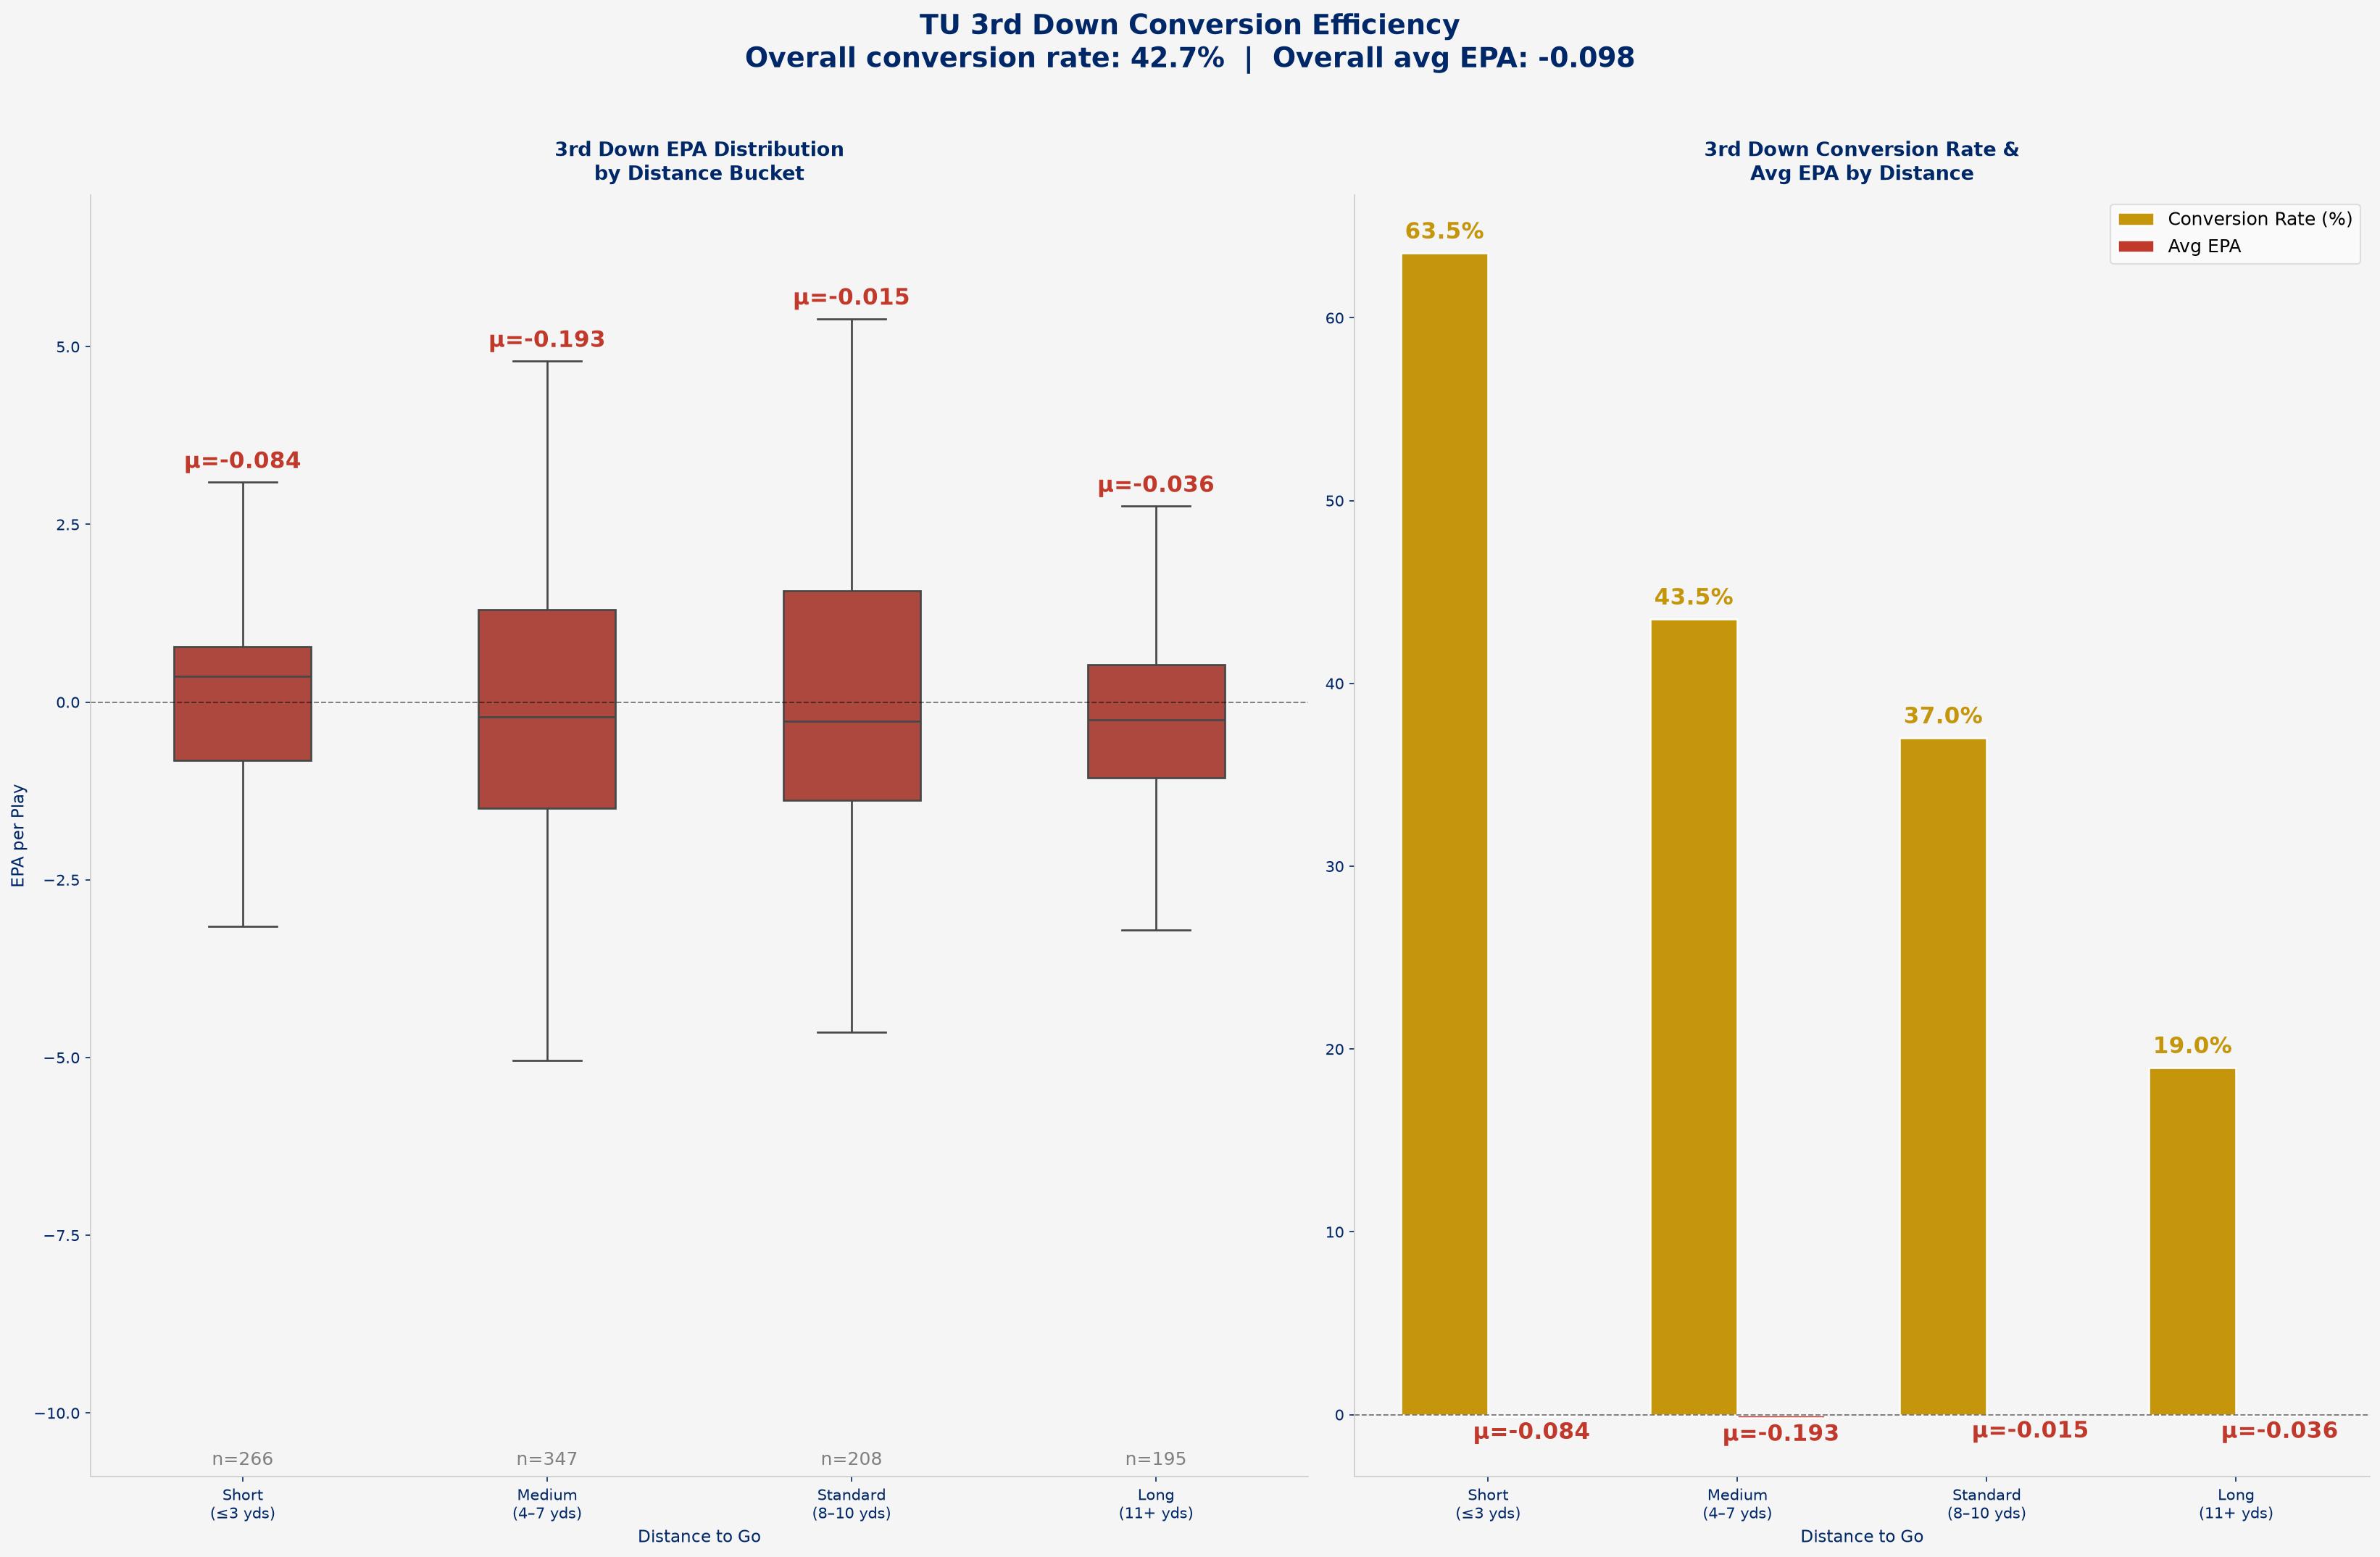

In [5]:

third_df = tu_df[
    (tu_df['odk'] == 'o') & (tu_df['epa'].notna()) &
    (tu_df['dist'].notna()) & (tu_df['dn'] == 3)
].copy()

bins   = [0, 3, 7, 10, float('inf')]
labels = ['Short\n(≤3 yds)', 'Medium\n(4–7 yds)',
          'Standard\n(8–10 yds)', 'Long\n(11+ yds)']
third_df['dist_bucket'] = pd.cut(third_df['dist'], bins=bins,
                                  labels=labels, include_lowest=True)

convert_results = ['complete', 'rush', 'scramble', 'complete, td', 'rush, td']
third_df['converted'] = (
    third_df['result'].str.strip().str.lower().isin(convert_results) &
    (third_df['gn_ls'] >= third_df['dist'])
)

bucket_df = (
    third_df.groupby('dist_bucket', observed=True)
    .agg(mean_epa=('epa','mean'), sem_epa=('epa','sem'),
         count=('epa','count'), conv_rate=('converted','mean'))
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(22, 14), gridspec_kw={'width_ratios': [1.2, 1]})
fig.patch.set_facecolor(LIGHT_GRAY)

ax1 = axes[0]
ax1.set_facecolor(LIGHT_GRAY)
bucket_colors = {
    b: (TU_BLUE if bucket_df.loc[bucket_df['dist_bucket']==b,'mean_epa'].values[0] >= 0
        else RED)
    for b in labels
}
sns.boxplot(data=third_df, x='dist_bucket', y='epa', order=labels,
            palette=bucket_colors, width=0.45, linewidth=1.3,
            flierprops=dict(marker='o', markersize=3, alpha=0.3,
                            linestyle='none', markeredgewidth=0), ax=ax1)

for i, bucket in enumerate(labels):
    subset = third_df[third_df['dist_bucket'] == bucket]['epa']
    if len(subset) == 0:
        continue
    mean_val    = subset.mean()
    Q3          = subset.quantile(0.75)
    whisker_top = subset[subset <= Q3 + 1.5*(Q3 - subset.quantile(0.25))].max()
    ax1.text(i, whisker_top + 0.12, f'μ={mean_val:+.3f}', ha='center', va='bottom',
             fontsize=15, fontweight='bold',
             color=TU_BLUE if mean_val >= 0 else RED)
    ax1.text(i, ax1.get_ylim()[0] + 0.1, f'n={len(subset)}', ha='center',
             va='bottom', fontsize=12, color='gray')

ax1.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.5)
ax1.set_title('3rd Down EPA Distribution\nby Distance Bucket',
              fontsize=13, fontweight='bold', color=TU_BLUE, pad=10)
ax1.set_xlabel('Distance to Go', fontsize=11, color=TU_BLUE)
ax1.set_ylabel('EPA per Play', fontsize=11, color=TU_BLUE)
ax1.tick_params(colors=TU_BLUE)
ax1.spines[['top','right']].set_visible(False)
ax1.spines[['left','bottom']].set_color('#CCCCCC')

ax2 = axes[1]
ax2.set_facecolor(LIGHT_GRAY)
x, width = range(len(bucket_df)), 0.35
bars1 = ax2.bar([i - width/2 for i in x], bucket_df['conv_rate']*100, width,
                color=TU_GOLD, edgecolor='white', linewidth=1.2, label='Conversion Rate (%)')
bars2 = ax2.bar([i + width/2 for i in x], bucket_df['mean_epa'], width,
                color=[TU_BLUE if v >= 0 else RED for v in bucket_df['mean_epa']],
                edgecolor='white', linewidth=1.2, label='Avg EPA')

for bar, row in zip(bars1, bucket_df.itertuples()):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'{row.conv_rate*100:.1f}%', ha='center', va='bottom',
             fontsize=15, fontweight='bold', color=TU_GOLD)

for bar, row in zip(bars2, bucket_df.itertuples()):
    label_y = row.mean_epa + 0.3 if row.mean_epa >= 0 else row.mean_epa - 0.3
    ax2.text(bar.get_x()+bar.get_width()/2, label_y,
             f'μ={row.mean_epa:+.3f}', ha='center',
             va='bottom' if row.mean_epa >= 0 else 'top',
             fontsize=15, fontweight='bold',
             color=TU_BLUE if row.mean_epa >= 0 else RED)

ax2.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.5)
ax2.set_xticks(list(x))
ax2.set_xticklabels(bucket_df['dist_bucket'], color=TU_BLUE)
ax2.set_title('3rd Down Conversion Rate &\nAvg EPA by Distance',
              fontsize=13, fontweight='bold', color=TU_BLUE, pad=10)
ax2.set_xlabel('Distance to Go', fontsize=11, color=TU_BLUE)
ax2.tick_params(colors=TU_BLUE)
ax2.spines[['top','right']].set_visible(False)
ax2.spines[['left','bottom']].set_color('#CCCCCC')
ax2.legend(fontsize=12, framealpha=0.6, edgecolor='#CCCCCC')

fig.suptitle(
    f'TU 3rd Down Conversion Efficiency\n'
    f'Overall conversion rate: {third_df["converted"].mean()*100:.1f}%  |  '
    f'Overall avg EPA: {third_df["epa"].mean():+.3f}',
    fontsize=18, fontweight='bold', color=TU_BLUE, y=1.02
)
plt.tight_layout()
plt.show()



## 4 · Run vs. Pass EPA by Down
> **So what?** 1st down run EPA is the foundation metric. If it's negative, we're playing from behind before the drive has a chance.


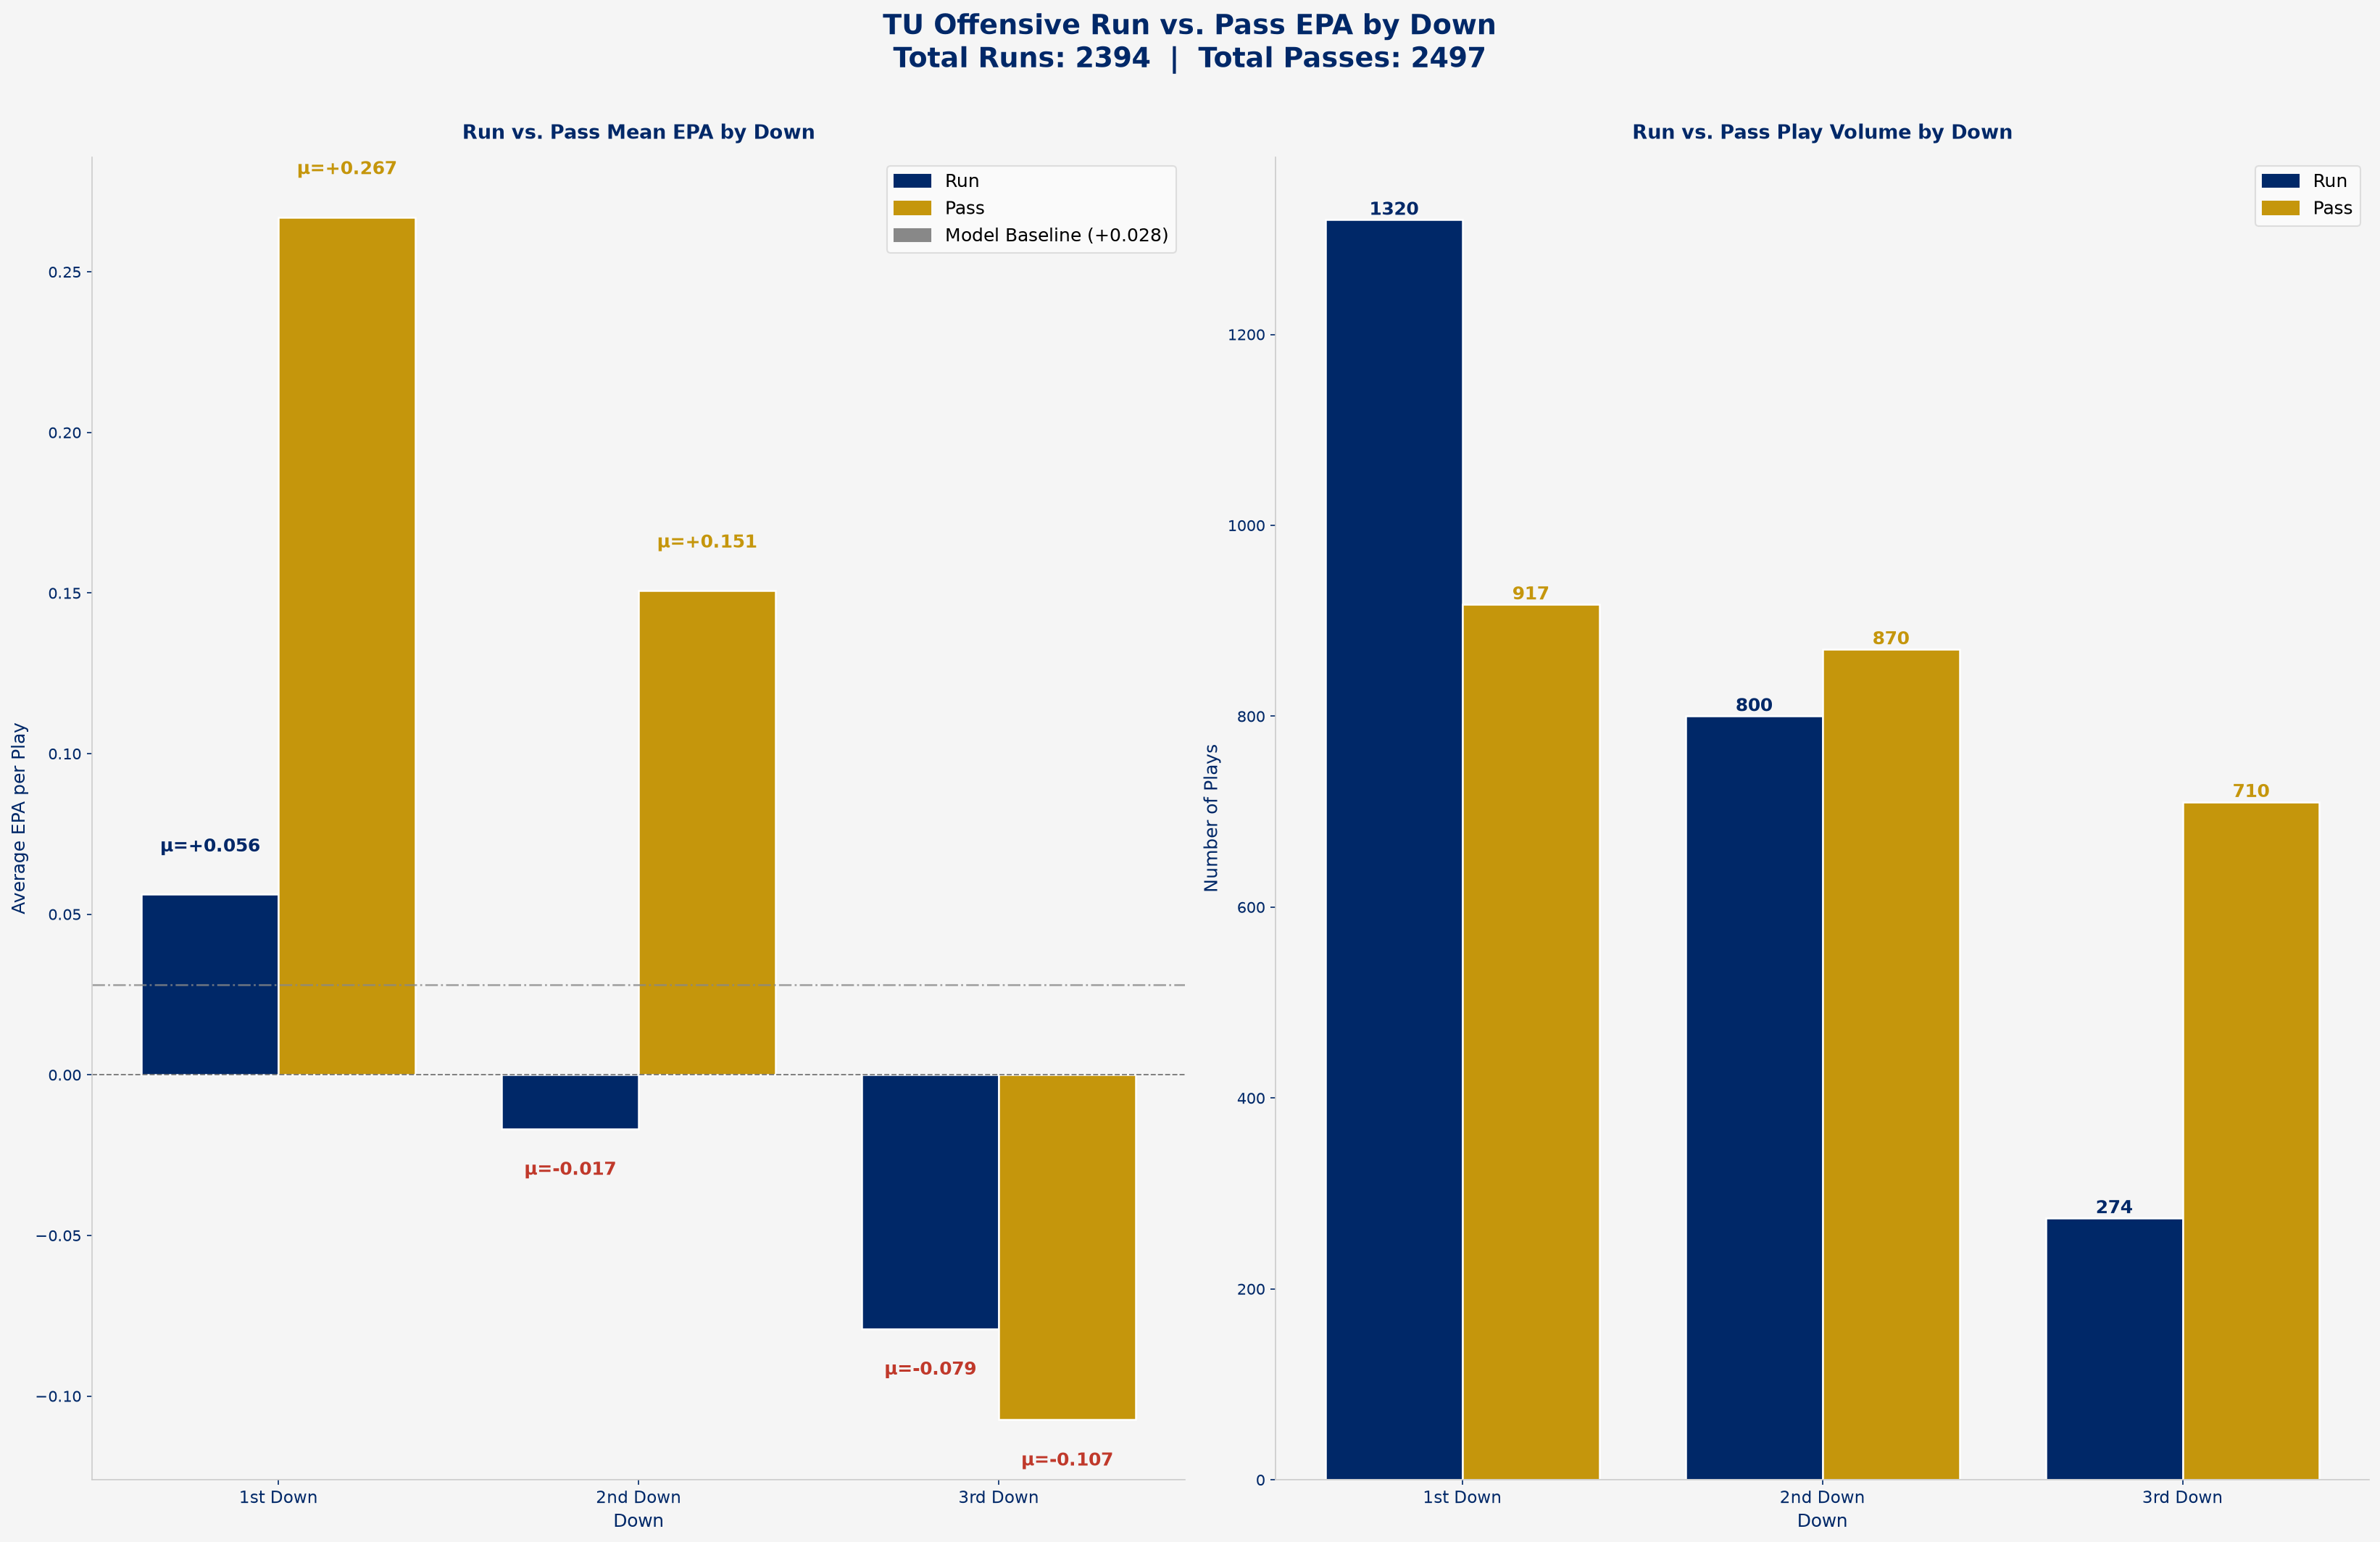

In [6]:

rp_down = tu_df[
    (tu_df['odk'] == 'o') & (tu_df['dn'].isin([1, 2, 3])) &
    (tu_df['play_type'].isin(['run', 'pass'])) & (tu_df['epa'].notna())
].copy()

down_order  = [1, 2, 3]
down_labels = ['1st Down', '2nd Down', '3rd Down']

summary = (
    rp_down.groupby(['dn', 'play_type'])
    .agg(mean_epa=('epa','mean'), sem=('epa','sem'), count=('epa','count'))
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(22, 14))
fig.patch.set_facecolor(LIGHT_GRAY)
PLAY_COLOR = {'run': TU_BLUE, 'pass': TU_GOLD}
x, bar_width = np.arange(len(down_order)), 0.38

ax1 = axes[0]
ax1.set_facecolor(LIGHT_GRAY)
for play_type, offset in [('run', -bar_width/2), ('pass', bar_width/2)]:
    data  = summary[summary['play_type']==play_type].set_index('dn').reindex(down_order)
    vals  = data['mean_epa'].values.astype(float)
    color = PLAY_COLOR[play_type]
    bars  = ax1.bar(x + offset, vals, bar_width, color=color,
                    edgecolor='white', linewidth=1.2)
    for bar_obj, val in zip(bars, vals):
        if np.isnan(val): continue
        ax1.text(bar_obj.get_x()+bar_obj.get_width()/2,
                 val + 0.012 if val >= 0 else val - 0.01,
                 f'μ={val:+.3f}', ha='center',
                 va='bottom' if val >= 0 else 'top',
                 fontsize=12, fontweight='bold',
                 color=RED if val < 0 else color)

ax1.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.5)
ax1.axhline(MODEL_BASELINE, color='#888888', linewidth=1.3, linestyle='-.',
            alpha=0.75, label='Model Baseline (+0.028)')
ax1.set_xticks(x); ax1.set_xticklabels(down_labels, fontsize=11, color=TU_BLUE)
ax1.tick_params(colors=TU_BLUE)
ax1.set_xlabel('Down', fontsize=12, color=TU_BLUE)
ax1.set_ylabel('Average EPA per Play', fontsize=12, color=TU_BLUE)
ax1.set_title('Run vs. Pass Mean EPA by Down', fontsize=13,
              fontweight='bold', color=TU_BLUE, pad=12)
ax1.legend(handles=[mpatches.Patch(color=TU_BLUE, label='Run'),
                     mpatches.Patch(color=TU_GOLD, label='Pass'),
                     mpatches.Patch(color='#888888', label='Model Baseline (+0.028)')],
           fontsize=12, framealpha=0.6, edgecolor='#CCCCCC')
ax1.spines[['top','right']].set_visible(False)
ax1.spines[['left','bottom']].set_color('#CCCCCC')

ax2 = axes[1]
ax2.set_facecolor(LIGHT_GRAY)
for play_type, offset in [('run', -bar_width/2), ('pass', bar_width/2)]:
    data  = summary[summary['play_type']==play_type].set_index('dn').reindex(down_order)
    vals  = data['count'].values.astype(float)
    color = PLAY_COLOR[play_type]
    bars  = ax2.bar(x + offset, vals, bar_width, color=color,
                    edgecolor='white', linewidth=1.2)
    for bar_obj, val in zip(bars, vals):
        if not np.isnan(val):
            ax2.text(bar_obj.get_x()+bar_obj.get_width()/2,
                     bar_obj.get_height()+0.8, f'{int(val)}',
                     ha='center', va='bottom', fontsize=12,
                     fontweight='bold', color=color)

ax2.set_xticks(x); ax2.set_xticklabels(down_labels, fontsize=11, color=TU_BLUE)
ax2.tick_params(colors=TU_BLUE)
ax2.set_xlabel('Down', fontsize=12, color=TU_BLUE)
ax2.set_ylabel('Number of Plays', fontsize=12, color=TU_BLUE)
ax2.set_title('Run vs. Pass Play Volume by Down', fontsize=13,
              fontweight='bold', color=TU_BLUE, pad=12)
ax2.legend(handles=[mpatches.Patch(color=TU_BLUE, label='Run'),
                     mpatches.Patch(color=TU_GOLD, label='Pass')],
           fontsize=12, framealpha=0.6, edgecolor='#CCCCCC')
ax2.spines[['top','right']].set_visible(False)
ax2.spines[['left','bottom']].set_color('#CCCCCC')

total_runs   = int(summary[summary['play_type']=='run']['count'].sum())
total_passes = int(summary[summary['play_type']=='pass']['count'].sum())
fig.suptitle(f'TU Offensive Run vs. Pass EPA by Down\nTotal Runs: {total_runs}  |  Total Passes: {total_passes}',
             fontsize=18, fontweight='bold', color=TU_BLUE, y=1.01)
plt.tight_layout()
plt.show()



## 5 · 3rd Down: Run vs. Pass
> **So what?** If we pass 90%+ on 3rd-and-long, defenses know it's coming. Volume + EPA together tell the full story.


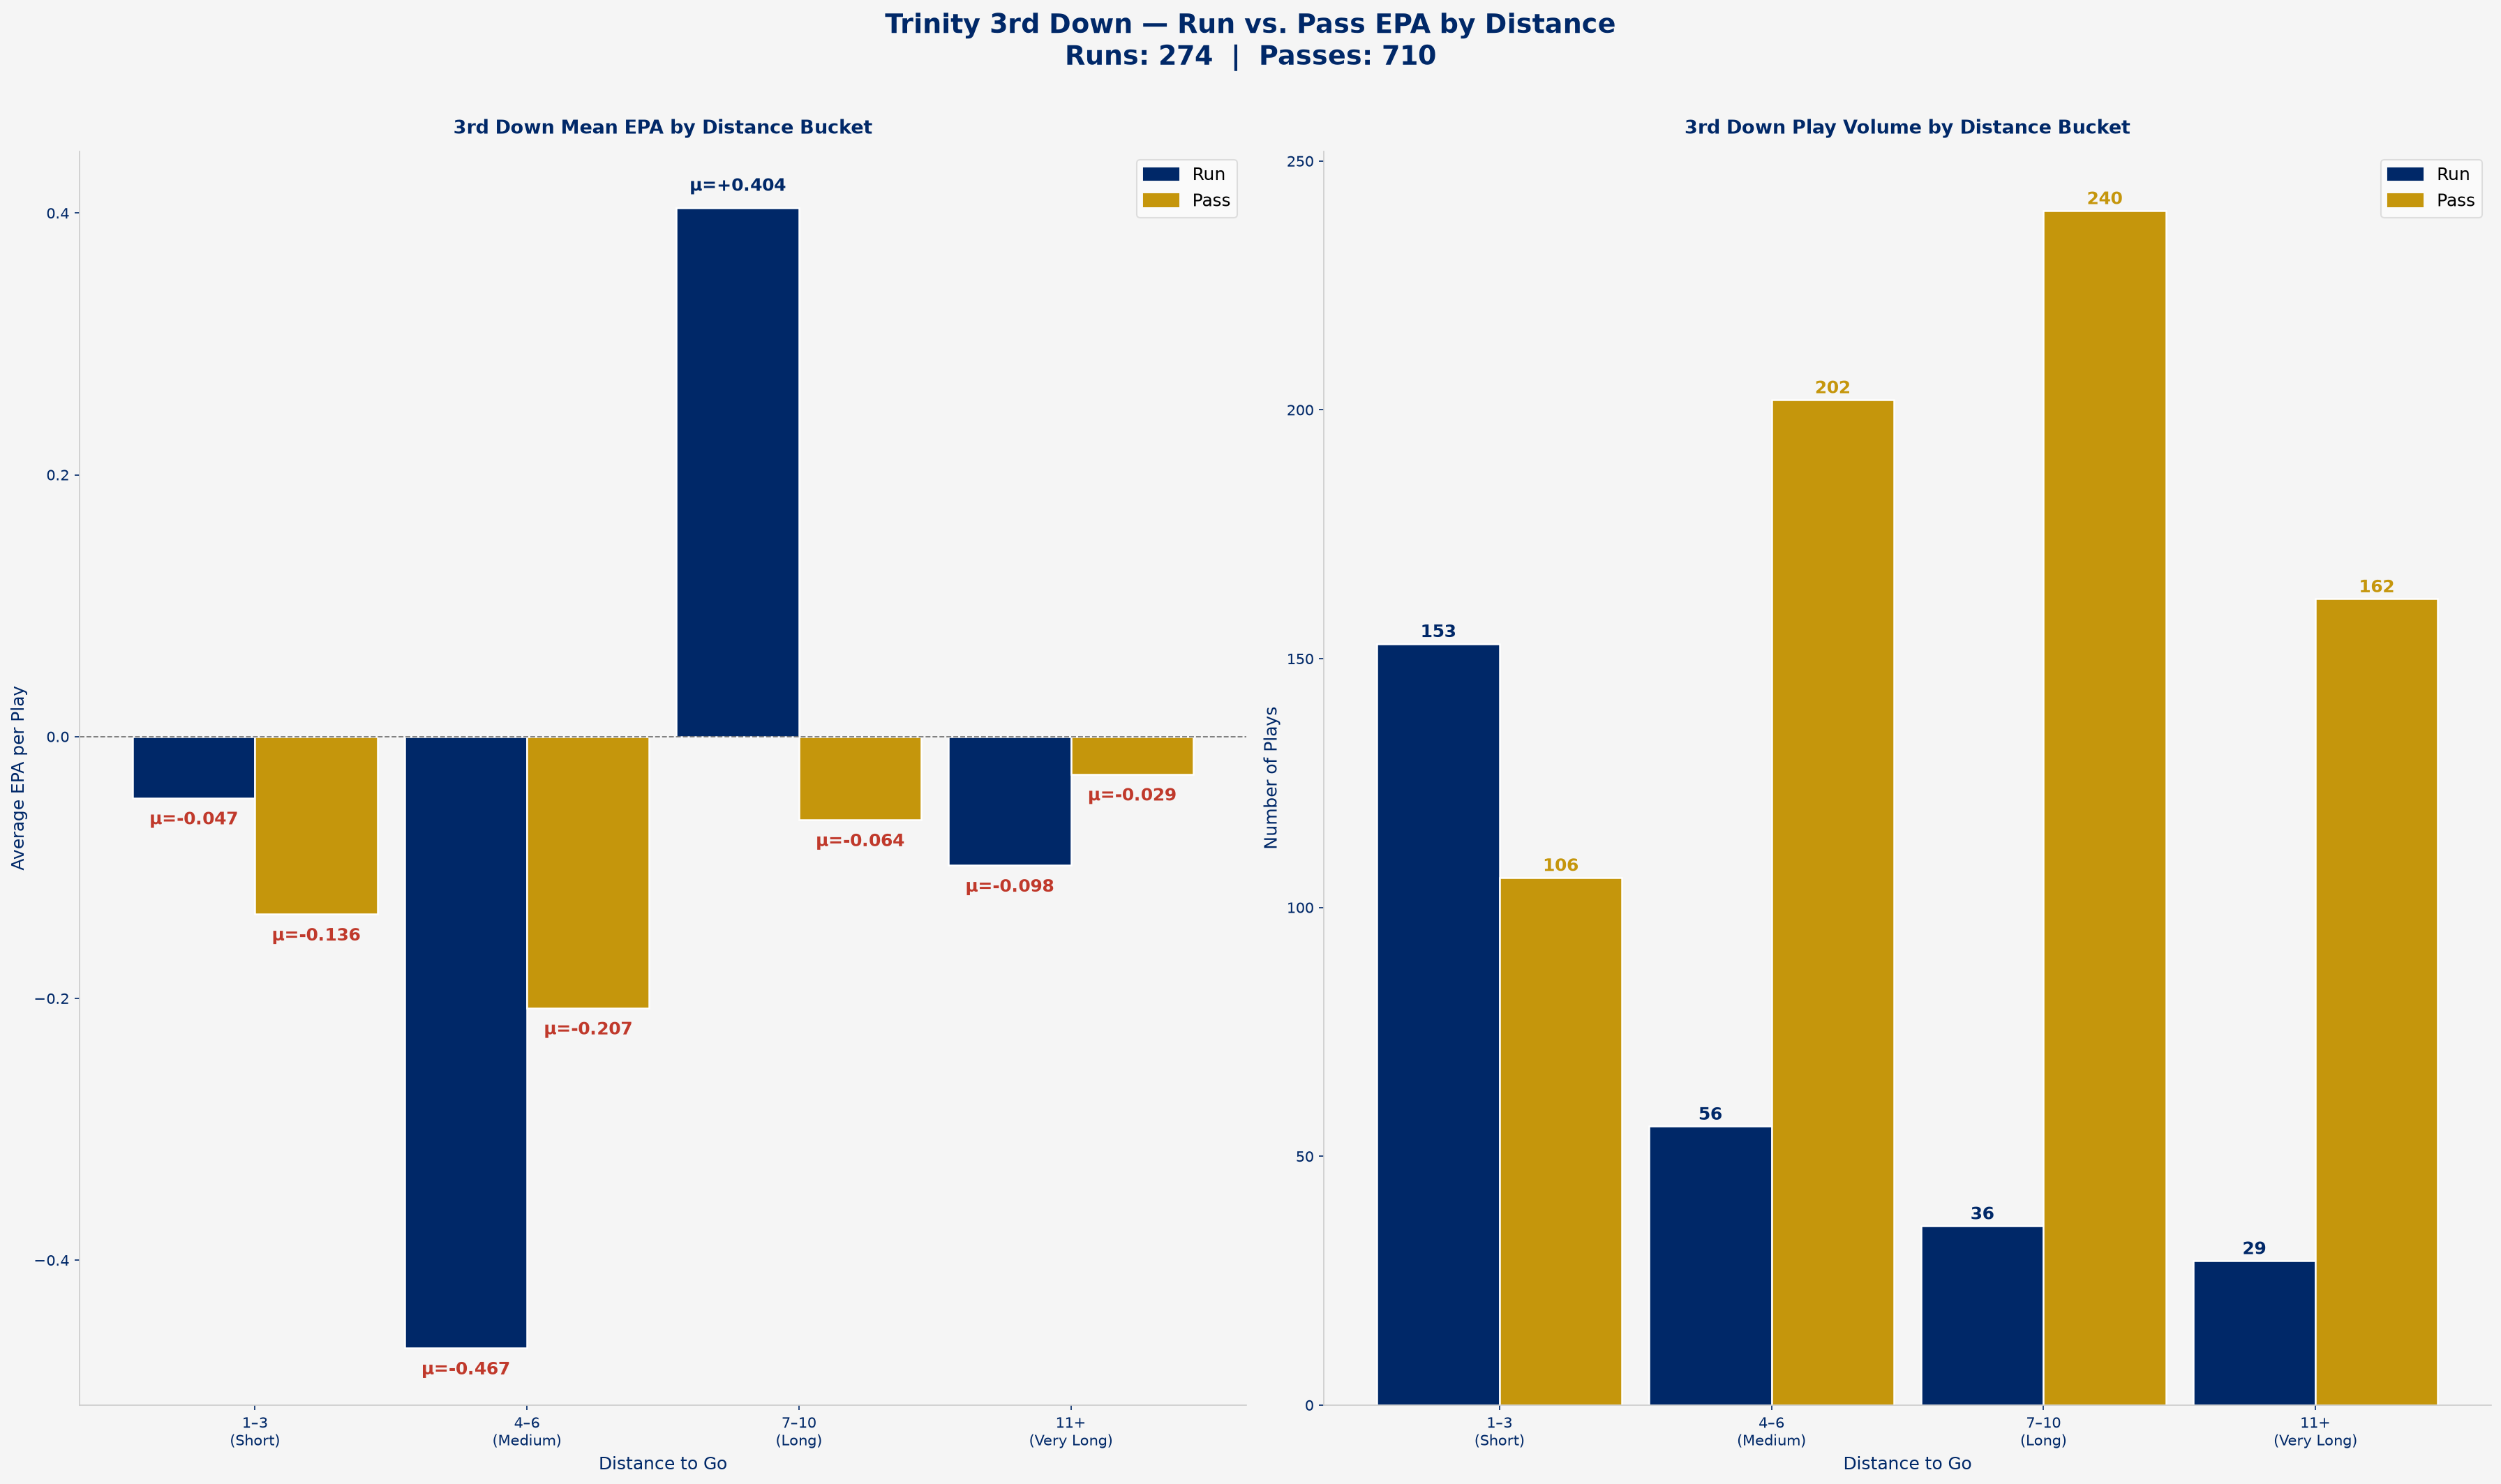

In [7]:

third_down = tu_df[
    (tu_df['odk'] == 'o') & (tu_df['dn'] == 3) &
    (tu_df['play_type'].isin(['run', 'pass'])) &
    (tu_df['epa'].notna()) & (tu_df['dist'].notna())
].copy()

def dist_bucket(d):
    if d <= 3:   return '1–3\n(Short)'
    elif d <= 6:  return '4–6\n(Medium)'
    elif d <= 10: return '7–10\n(Long)'
    else:         return '11+\n(Very Long)'

bucket_order = ['1–3\n(Short)', '4–6\n(Medium)', '7–10\n(Long)', '11+\n(Very Long)']
third_down['dist_bucket'] = pd.Categorical(
    third_down['dist'].apply(dist_bucket), categories=bucket_order, ordered=True
)

summary = (
    third_down.groupby(['dist_bucket', 'play_type'], observed=True)
    .agg(mean_epa=('epa','mean'), count=('epa','count'), sem=('epa', lambda x: x.sem()))
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(24, 14))
fig.patch.set_facecolor(LIGHT_GRAY)
PLAY_COLOR = {'run': TU_BLUE, 'pass': TU_GOLD}
x, bar_width = np.arange(len(bucket_order)), 0.45

for ax, metric, ylabel, title_suffix in zip(
    axes, ['mean_epa', 'count'],
    ['Average EPA per Play', 'Number of Plays'],
    ['Mean EPA by Distance Bucket', 'Play Volume by Distance Bucket']
):
    ax.set_facecolor(LIGHT_GRAY)
    ax.spines[['top','right']].set_visible(False)
    ax.spines[['left','bottom']].set_color('#CCCCCC')

    for play_type, offset in [('run', -bar_width/2), ('pass', bar_width/2)]:
        data = summary[summary['play_type'] == play_type].set_index('dist_bucket').reindex(bucket_order)
        vals = data[metric].values.astype(float)
        color = PLAY_COLOR[play_type]

        bars = ax.bar(x + offset, vals, bar_width, color=color,
                      edgecolor='white', linewidth=1.2, label=play_type.capitalize())

        for bar_obj, val in zip(bars, vals):
            if np.isnan(val):
                continue
            if metric == 'mean_epa':
                ax.text(bar_obj.get_x()+bar_obj.get_width()/2,
                        val + 0.01 if val >= 0 else val - 0.01,
                        f'μ={val:+.3f}', ha='center',
                        va='bottom' if val >= 0 else 'top',
                        fontsize=12, fontweight='bold',
                        color=RED if val < 0 else color)
            else:
                ax.text(bar_obj.get_x()+bar_obj.get_width()/2,
                        bar_obj.get_height()+0.5, f'{int(val)}',
                        ha='center', va='bottom', fontsize=12,
                        fontweight='bold', color=color)

    if metric == 'mean_epa':
        ax.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels(bucket_order, fontsize=10, color=TU_BLUE)
    ax.tick_params(colors=TU_BLUE)
    ax.set_xlabel('Distance to Go', fontsize=12, color=TU_BLUE)
    ax.set_ylabel(ylabel, fontsize=12, color=TU_BLUE)
    ax.set_title(f'3rd Down {title_suffix}', fontsize=13,
                 fontweight='bold', color=TU_BLUE, pad=12)
    ax.legend(handles=[mpatches.Patch(color=TU_BLUE, label='Run'),
                        mpatches.Patch(color=TU_GOLD, label='Pass')],
              fontsize=12, framealpha=0.6, edgecolor='#CCCCCC')

total_runs   = int(summary[summary['play_type']=='run']['count'].sum())
total_passes = int(summary[summary['play_type']=='pass']['count'].sum())
fig.suptitle(f'Trinity 3rd Down — Run vs. Pass EPA by Distance\nRuns: {total_runs}  |  Passes: {total_passes}',
             fontsize=18, fontweight='bold', color=TU_BLUE, y=1.01)
plt.tight_layout()
plt.show()



## 6 · EPA by Field Zone
> **So what?** Red zone EPA is the most consequential number here. Below baseline = points left on the field every week.


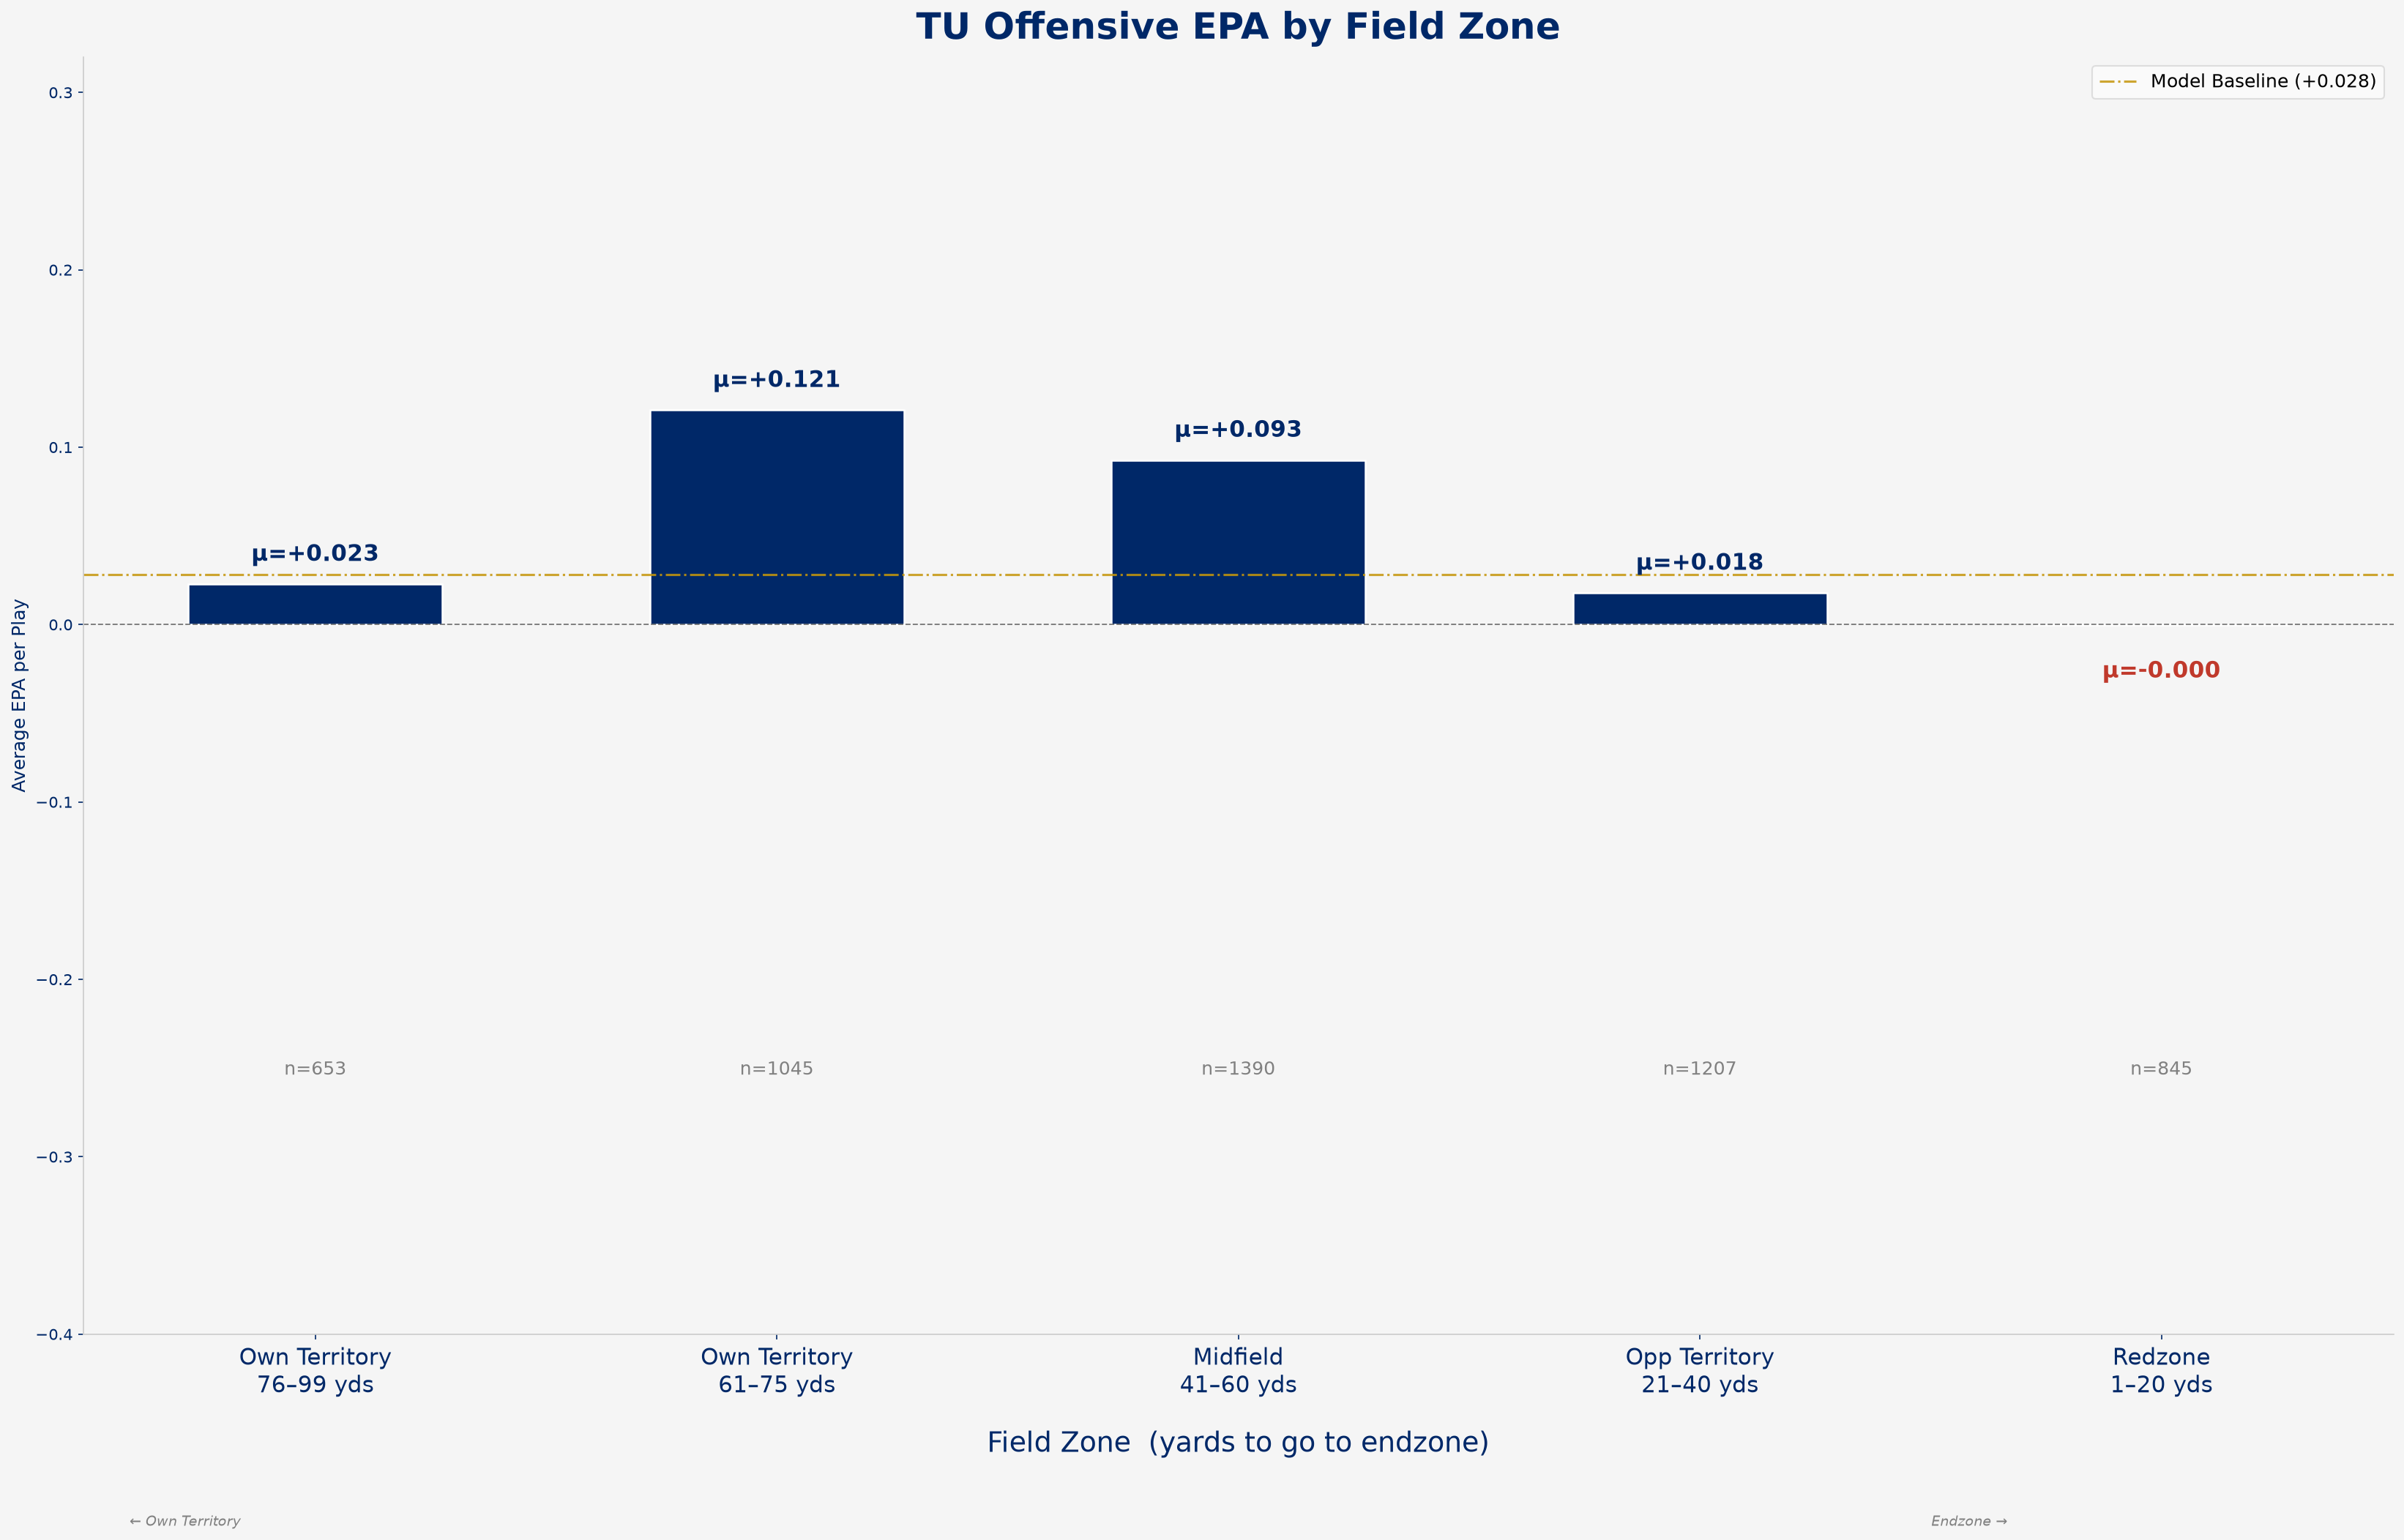

In [8]:

off_df = tu_df[
    (tu_df['odk'] == 'o') & (tu_df['epa'].notna()) & (tu_df['yards_to_go'].notna())
].copy()

bins   = [0, 20, 40, 60, 75, 99]
labels = ['Redzone\n1–20 yds', 'Opp Territory\n21–40 yds',
          'Midfield\n41–60 yds', 'Own Territory\n61–75 yds', 'Own Territory\n76–99 yds']
off_df['field_zone'] = pd.cut(off_df['yards_to_go'], bins=bins,
                               labels=labels, include_lowest=True)

zone_df = (
    off_df.groupby('field_zone', observed=True)['epa']
    .agg(['mean','sem','count']).reset_index()
).iloc[::-1].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(22, 14))
fig.patch.set_facecolor(LIGHT_GRAY)
ax.set_facecolor(LIGHT_GRAY)

bars = ax.bar(zone_df['field_zone'], zone_df['mean'],
              color=[TU_BLUE if v >= 0 else RED for v in zone_df['mean']],
              edgecolor='white', linewidth=1.2, width=0.55)
ax.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.5)
ax.axhline(MODEL_BASELINE, color=TU_GOLD, linewidth=1.5, linestyle='-.',
           alpha=0.85, label='Model Baseline (+0.028)')
ax.legend(fontsize=12, framealpha=0.6, edgecolor='#CCCCCC')

for bar, row in zip(bars, zone_df.itertuples()):
    label_y = row.mean + 0.01 if row.mean >= 0 else row.mean - 0.02
    ax.text(bar.get_x()+bar.get_width()/2, label_y, f'μ={row.mean:+.3f}',
            ha='center', va='bottom' if row.mean >= 0 else 'top',
            fontsize=15, fontweight='bold',
            color=TU_BLUE if row.mean >= 0 else RED)
    ax.text(bar.get_x()+bar.get_width()/2, ax.get_ylim()[0] - 0.25,
            f'n={row.count}', ha='center', va='bottom', fontsize=12, color='gray')

ax.set_ylim(bottom=-0.40, top=0.32)
ax.annotate('← Own Territory', xy=(0.02, -0.15), xycoords='axes fraction',
            fontsize=9, color='gray', style='italic')
ax.annotate('Endzone →', xy=(0.80, -0.15), xycoords='axes fraction',
            fontsize=9, color='gray', style='italic')
ax.set_title('TU Offensive EPA by Field Zone', fontsize=24,
             fontweight='bold', color=TU_BLUE, pad=12)
ax.set_xlabel('Field Zone  (yards to go to endzone)', fontsize=18,
              color=TU_BLUE, labelpad=20)
ax.set_ylabel('Average EPA per Play', fontsize=12, color=TU_BLUE)
ax.tick_params(axis='x', labelsize=15, colors=TU_BLUE)
ax.tick_params(axis='y', colors=TU_BLUE)
ax.spines[['top','right']].set_visible(False)
ax.spines[['left','bottom']].set_color('#CCCCCC')
plt.tight_layout()
plt.show()



## 7 · Red Zone EPA by Down
> **So what?** Negative 3rd down red zone EPA = field goals instead of touchdowns. Every missed TD in the red zone directly costs win probability.


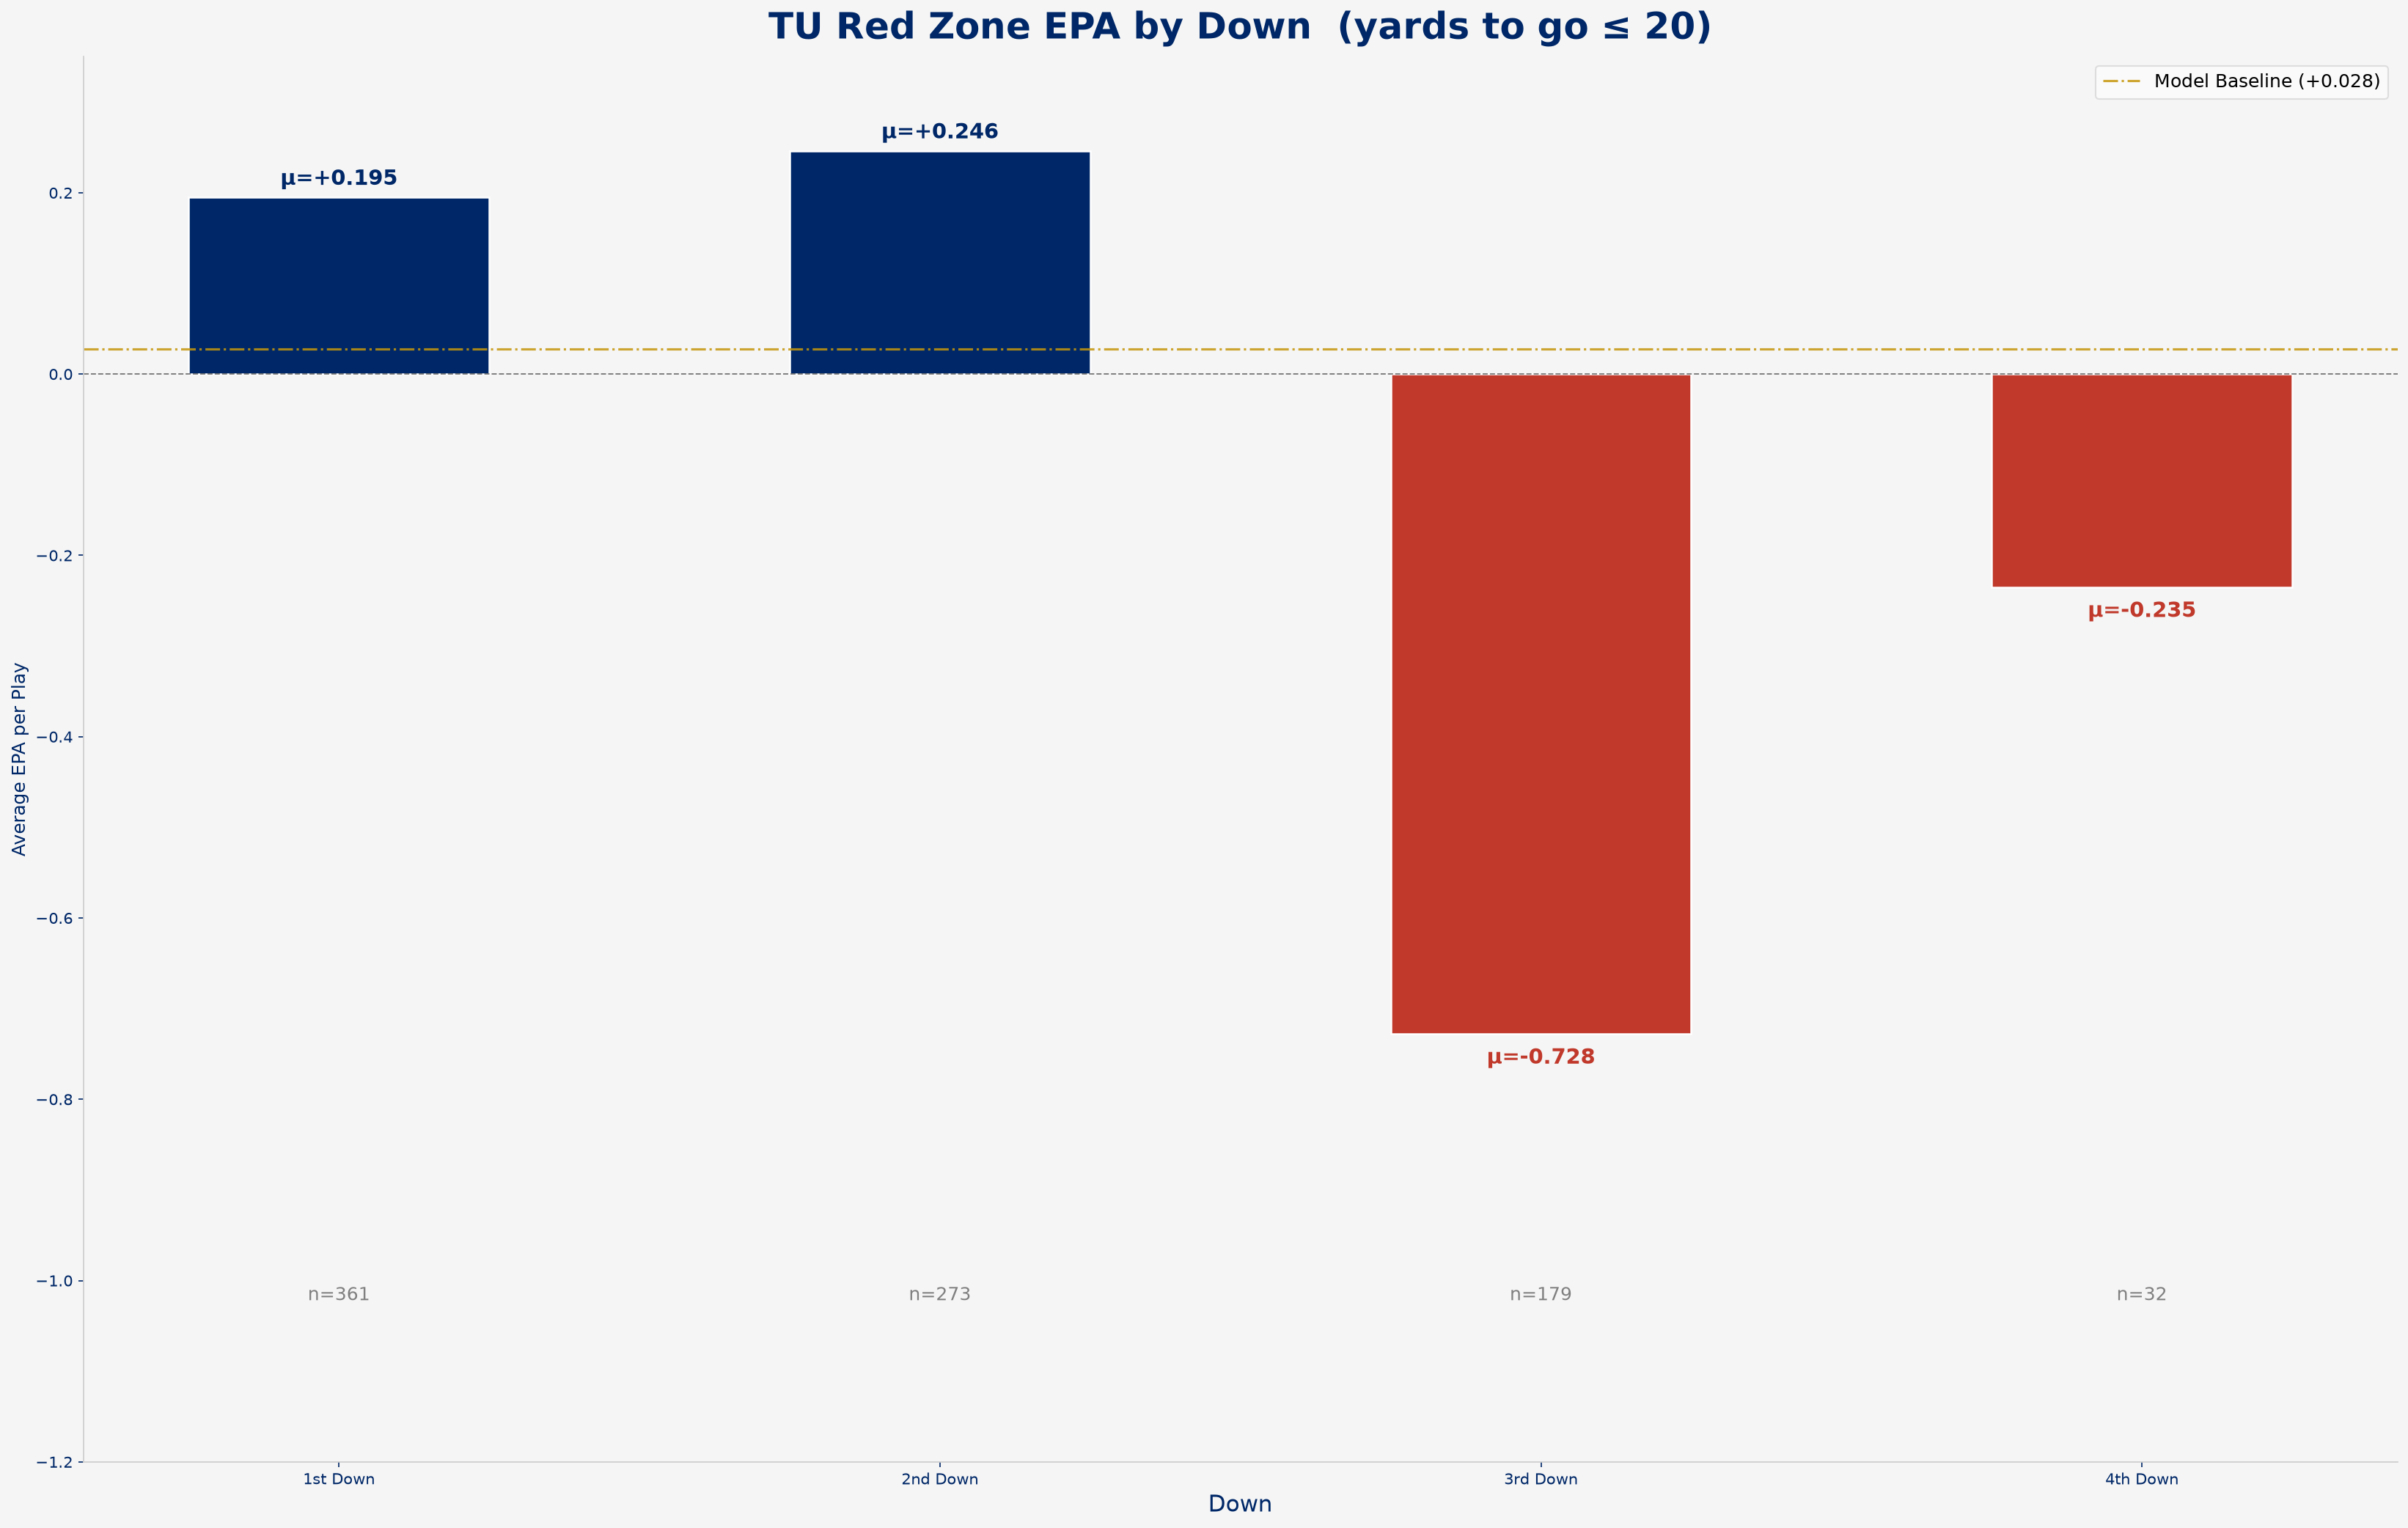

In [9]:

rz_df = tu_df[
    (tu_df['odk'] == 'o') & (tu_df['epa'].notna()) &
    (tu_df['yards_to_go'].notna()) & (tu_df['dn'].notna()) &
    (tu_df['yards_to_go'] <= 20)
].copy()

rz_df['down_group'] = rz_df['dn'].map(
    {1.0: '1st Down', 2.0: '2nd Down', 3.0: '3rd Down', 4.0: '4th Down'}
)
rz_df = rz_df[rz_df['down_group'].notna()]
down_order = ['1st Down', '2nd Down', '3rd Down', '4th Down']

down_agg = (
    rz_df.groupby('down_group', observed=True)['epa']
    .agg(['mean','sem','count']).reindex(down_order).reset_index()
)

fig, ax = plt.subplots(figsize=(22, 14))
fig.patch.set_facecolor(LIGHT_GRAY)
ax.set_facecolor(LIGHT_GRAY)

bars = ax.bar(down_agg['down_group'], down_agg['mean'],
              color=[TU_BLUE if v >= 0 else RED for v in down_agg['mean']],
              edgecolor='white', linewidth=1.2, width=0.5)
ax.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.5)
ax.axhline(MODEL_BASELINE, color=TU_GOLD, linewidth=1.5, linestyle='-.',
           alpha=0.85, label='Model Baseline (+0.028)')
ax.legend(fontsize=12, framealpha=0.6, edgecolor='#CCCCCC')

for bar, row in zip(bars, down_agg.itertuples()):
    if pd.isna(row.mean): continue
    ax.text(bar.get_x()+bar.get_width()/2,
            row.mean + 0.008 if row.mean >= 0 else row.mean - 0.015,
            f'μ={row.mean:+.3f}', ha='center',
            va='bottom' if row.mean >= 0 else 'top',
            fontsize=14, fontweight='bold',
            color=TU_BLUE if row.mean >= 0 else RED)
    ax.text(bar.get_x()+bar.get_width()/2, ax.get_ylim()[0] - 0.25,
            f'n={int(row.count)}', ha='center', va='bottom', fontsize=12, color='gray')

ax.set_ylim(bottom=-1.2, top=0.35)
ax.set_title('TU Red Zone EPA by Down  (yards to go ≤ 20)',
             fontsize=24, fontweight='bold', color=TU_BLUE, pad=12)
ax.set_xlabel('Down', fontsize=15, color=TU_BLUE)
ax.set_ylabel('Average EPA per Play', fontsize=12, color=TU_BLUE)
ax.tick_params(colors=TU_BLUE)
ax.spines[['top','right']].set_visible(False)
ax.spines[['left','bottom']].set_color('#CCCCCC')
plt.tight_layout()
plt.show()



## 8 · Red Zone: Run vs. Pass
> **So what?** 70%+ usage of one play type in the red zone is predictable. Balance keeps the defense honest even when one has a slight EPA edge.


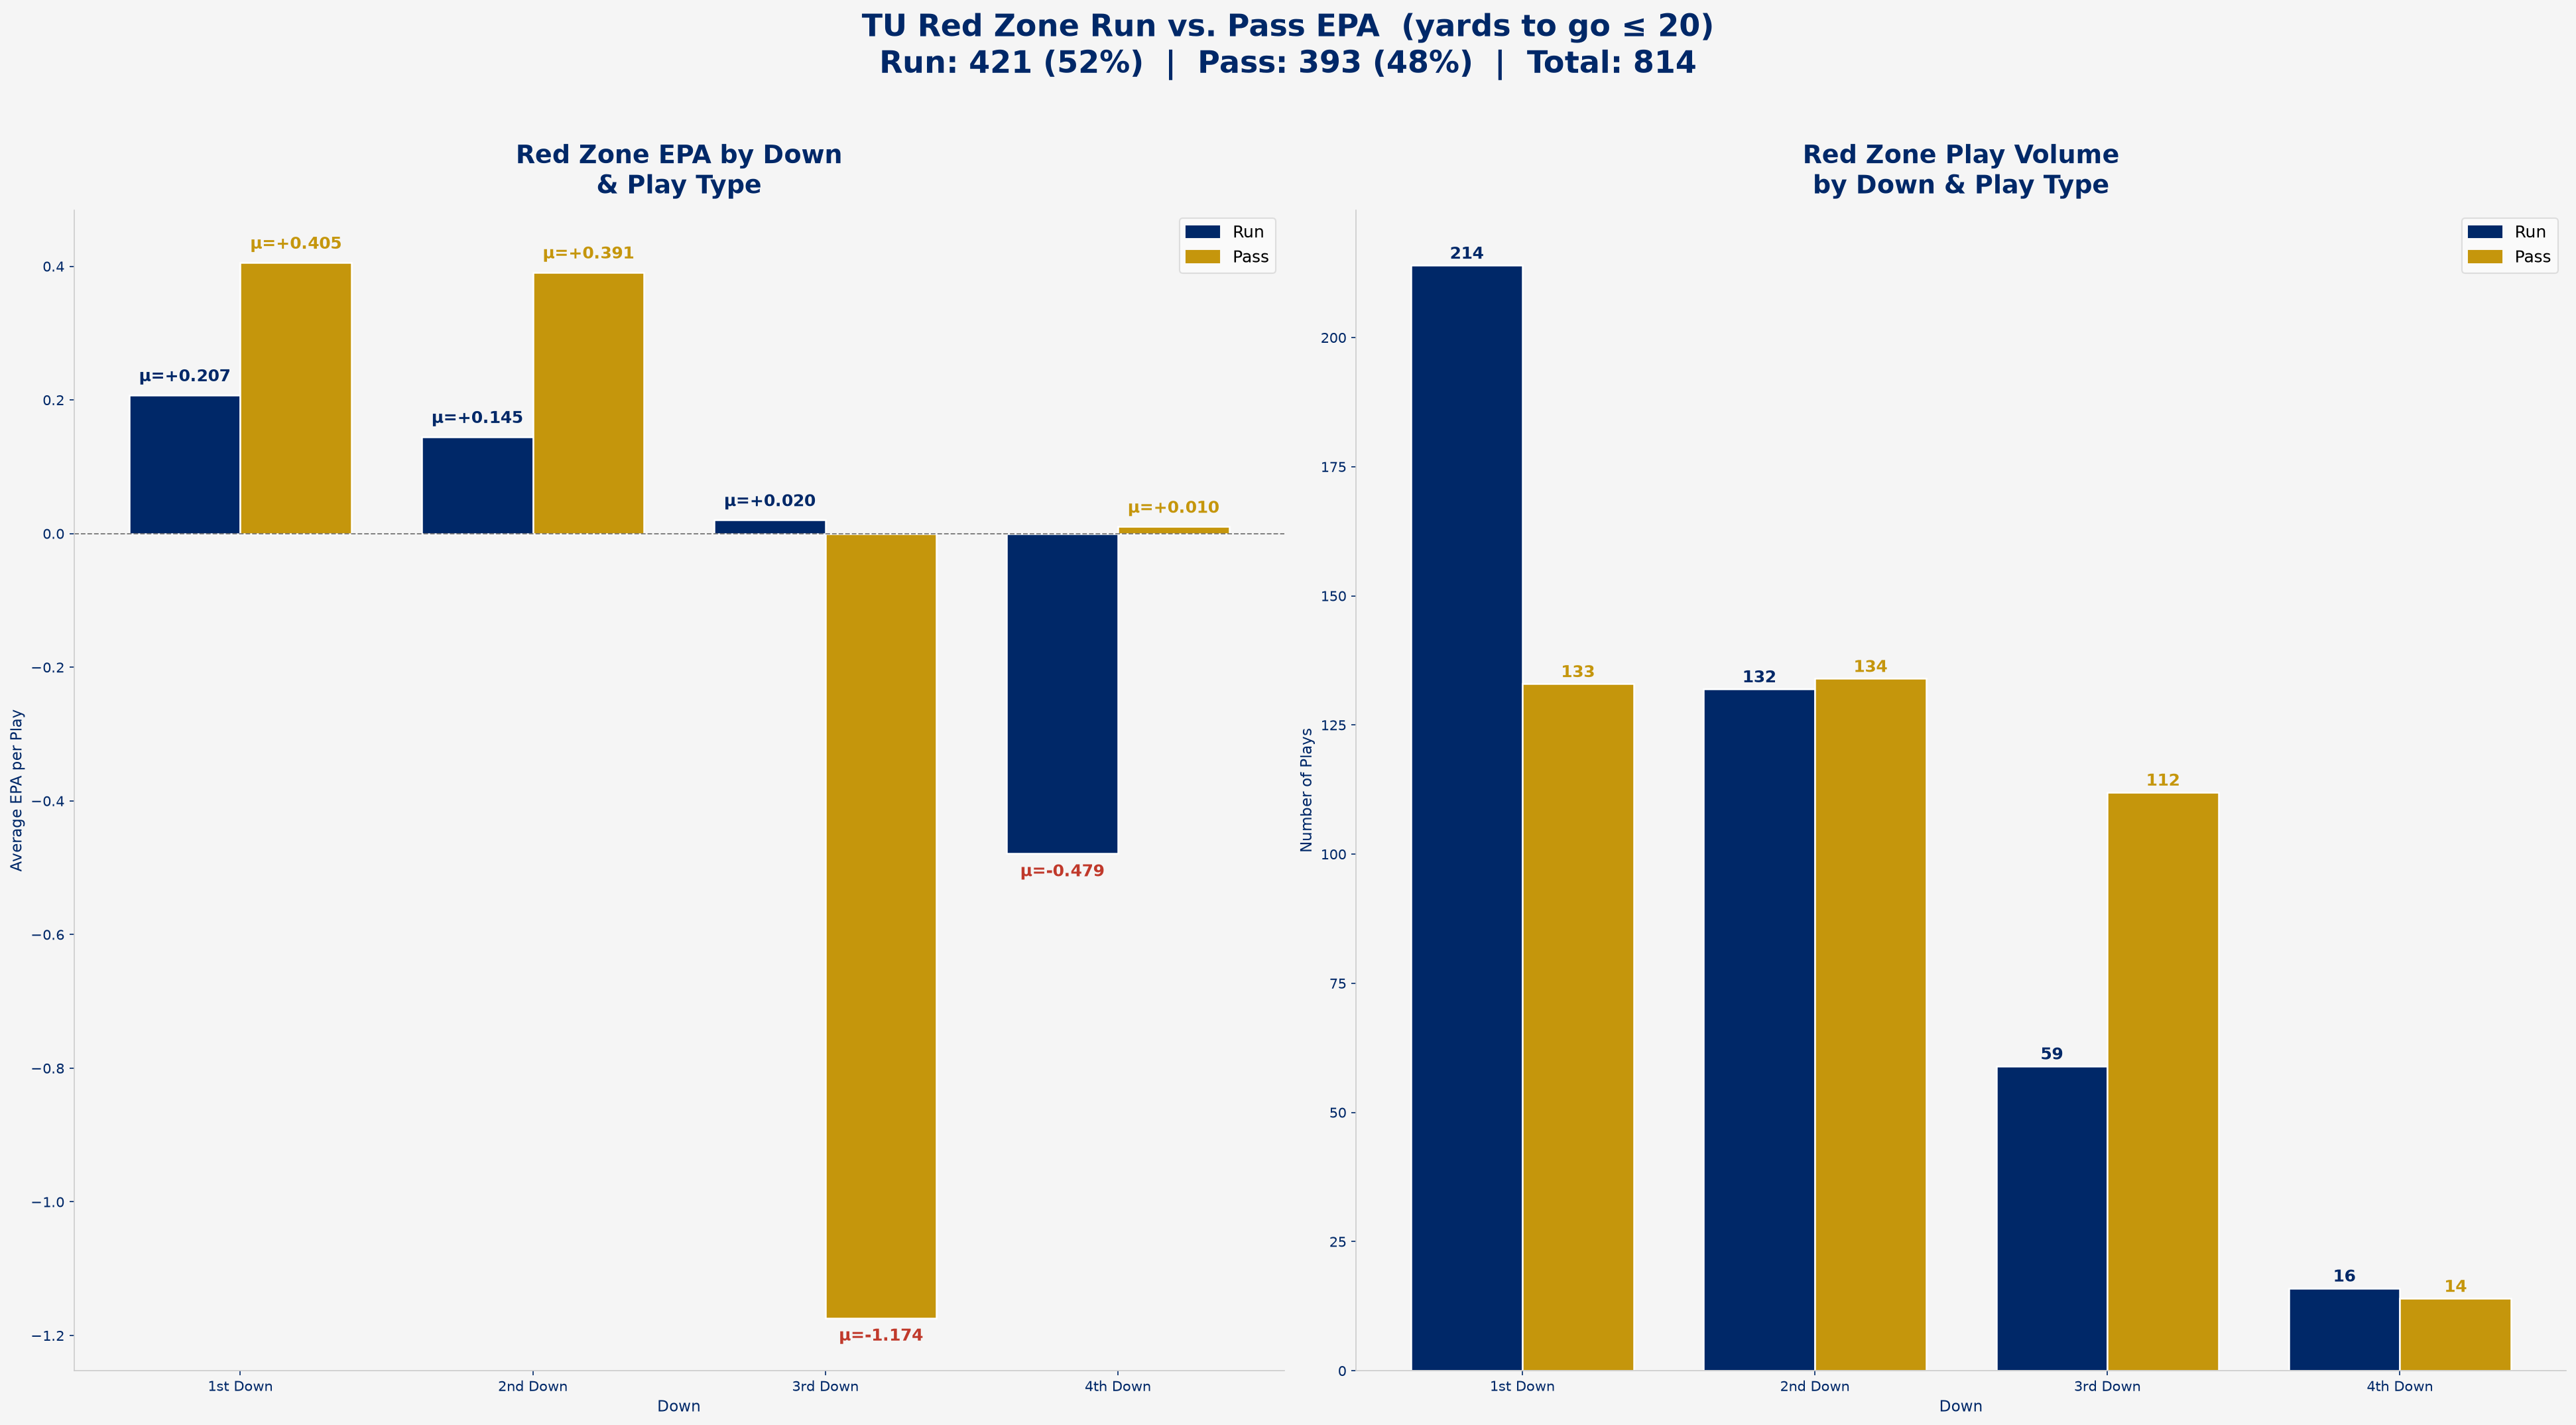

In [10]:

rz_rp = tu_df[
    (tu_df['odk'] == 'o') & (tu_df['yards_to_go'].notna()) &
    (tu_df['yards_to_go'] <= 20) & (tu_df['play_type'].isin(['run', 'pass'])) &
    (tu_df['epa'].notna()) & (tu_df['dn'].isin([1, 2, 3, 4]))
].copy()

down_order  = [1, 2, 3, 4]
down_labels = ['1st Down', '2nd Down', '3rd Down', '4th Down']
PLAY_COLOR  = {'run': TU_BLUE, 'pass': TU_GOLD}

summary = (
    rz_rp.groupby(['dn', 'play_type'])
    .agg(mean_epa=('epa','mean'), sem=('epa','sem'), count=('epa','count'))
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(26, 14))
fig.patch.set_facecolor(LIGHT_GRAY)
x, bar_width = np.arange(len(down_order)), 0.38

for ax, metric, ylabel, title in zip(
    axes,
    ['mean_epa', 'count'],
    ['Average EPA per Play', 'Number of Plays'],
    ['Red Zone EPA by Down\n& Play Type', 'Red Zone Play Volume\nby Down & Play Type']
):
    ax.set_facecolor(LIGHT_GRAY)
    for play_type, offset in [('run', -bar_width/2), ('pass', bar_width/2)]:
        data  = summary[summary['play_type']==play_type].set_index('dn').reindex(down_order)
        vals  = data[metric].values.astype(float)
        color = PLAY_COLOR[play_type]
        bars  = ax.bar(x + offset, vals, bar_width, color=color,
                       edgecolor='white', linewidth=1.2)
        for bar_obj, val in zip(bars, vals):
            if np.isnan(val): continue
            if metric == 'mean_epa':
                ax.text(bar_obj.get_x()+bar_obj.get_width()/2,
                        val + 0.015 if val >= 0 else val - 0.015,
                        f'μ={val:+.3f}', ha='center',
                        va='bottom' if val >= 0 else 'top',
                        fontsize=12, fontweight='bold',
                        color=RED if val < 0 else color)
            elif val > 0:
                ax.text(bar_obj.get_x()+bar_obj.get_width()/2,
                        bar_obj.get_height()+0.5, f'{int(val)}',
                        ha='center', va='bottom', fontsize=12,
                        fontweight='bold', color=color)

    if metric == 'mean_epa':
        ax.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.5)

    ax.set_xticks(x); ax.set_xticklabels(down_labels, fontsize=10, color=TU_BLUE)
    ax.tick_params(colors=TU_BLUE)
    ax.set_xlabel('Down', fontsize=11, color=TU_BLUE)
    ax.set_ylabel(ylabel, fontsize=11, color=TU_BLUE)
    ax.set_title(title, fontsize=18, fontweight='bold', color=TU_BLUE, pad=12)
    ax.legend(handles=[mpatches.Patch(color=TU_BLUE, label='Run'),
                        mpatches.Patch(color=TU_GOLD, label='Pass')],
              fontsize=12, framealpha=0.6, edgecolor='#CCCCCC')
    ax.spines[['top','right']].set_visible(False)
    ax.spines[['left','bottom']].set_color('#CCCCCC')

run_t = int(summary[summary['play_type']=='run']['count'].sum())
pass_t = int(summary[summary['play_type']=='pass']['count'].sum())
total  = run_t + pass_t
fig.suptitle(
    f'TU Red Zone Run vs. Pass EPA  (yards to go ≤ 20)\n'
    f'Run: {run_t} ({run_t/total*100:.0f}%)  |  Pass: {pass_t} ({pass_t/total*100:.0f}%)  |  Total: {total}',
    fontsize=22, fontweight='bold', color=TU_BLUE, y=1.02
)
plt.tight_layout()
plt.show()



## 9 · EPA by Result Type
> **So what?** Eliminating one sack or interception per game can outweigh several explosive plays. Scramble EPA tells you if QB mobility is a real asset.


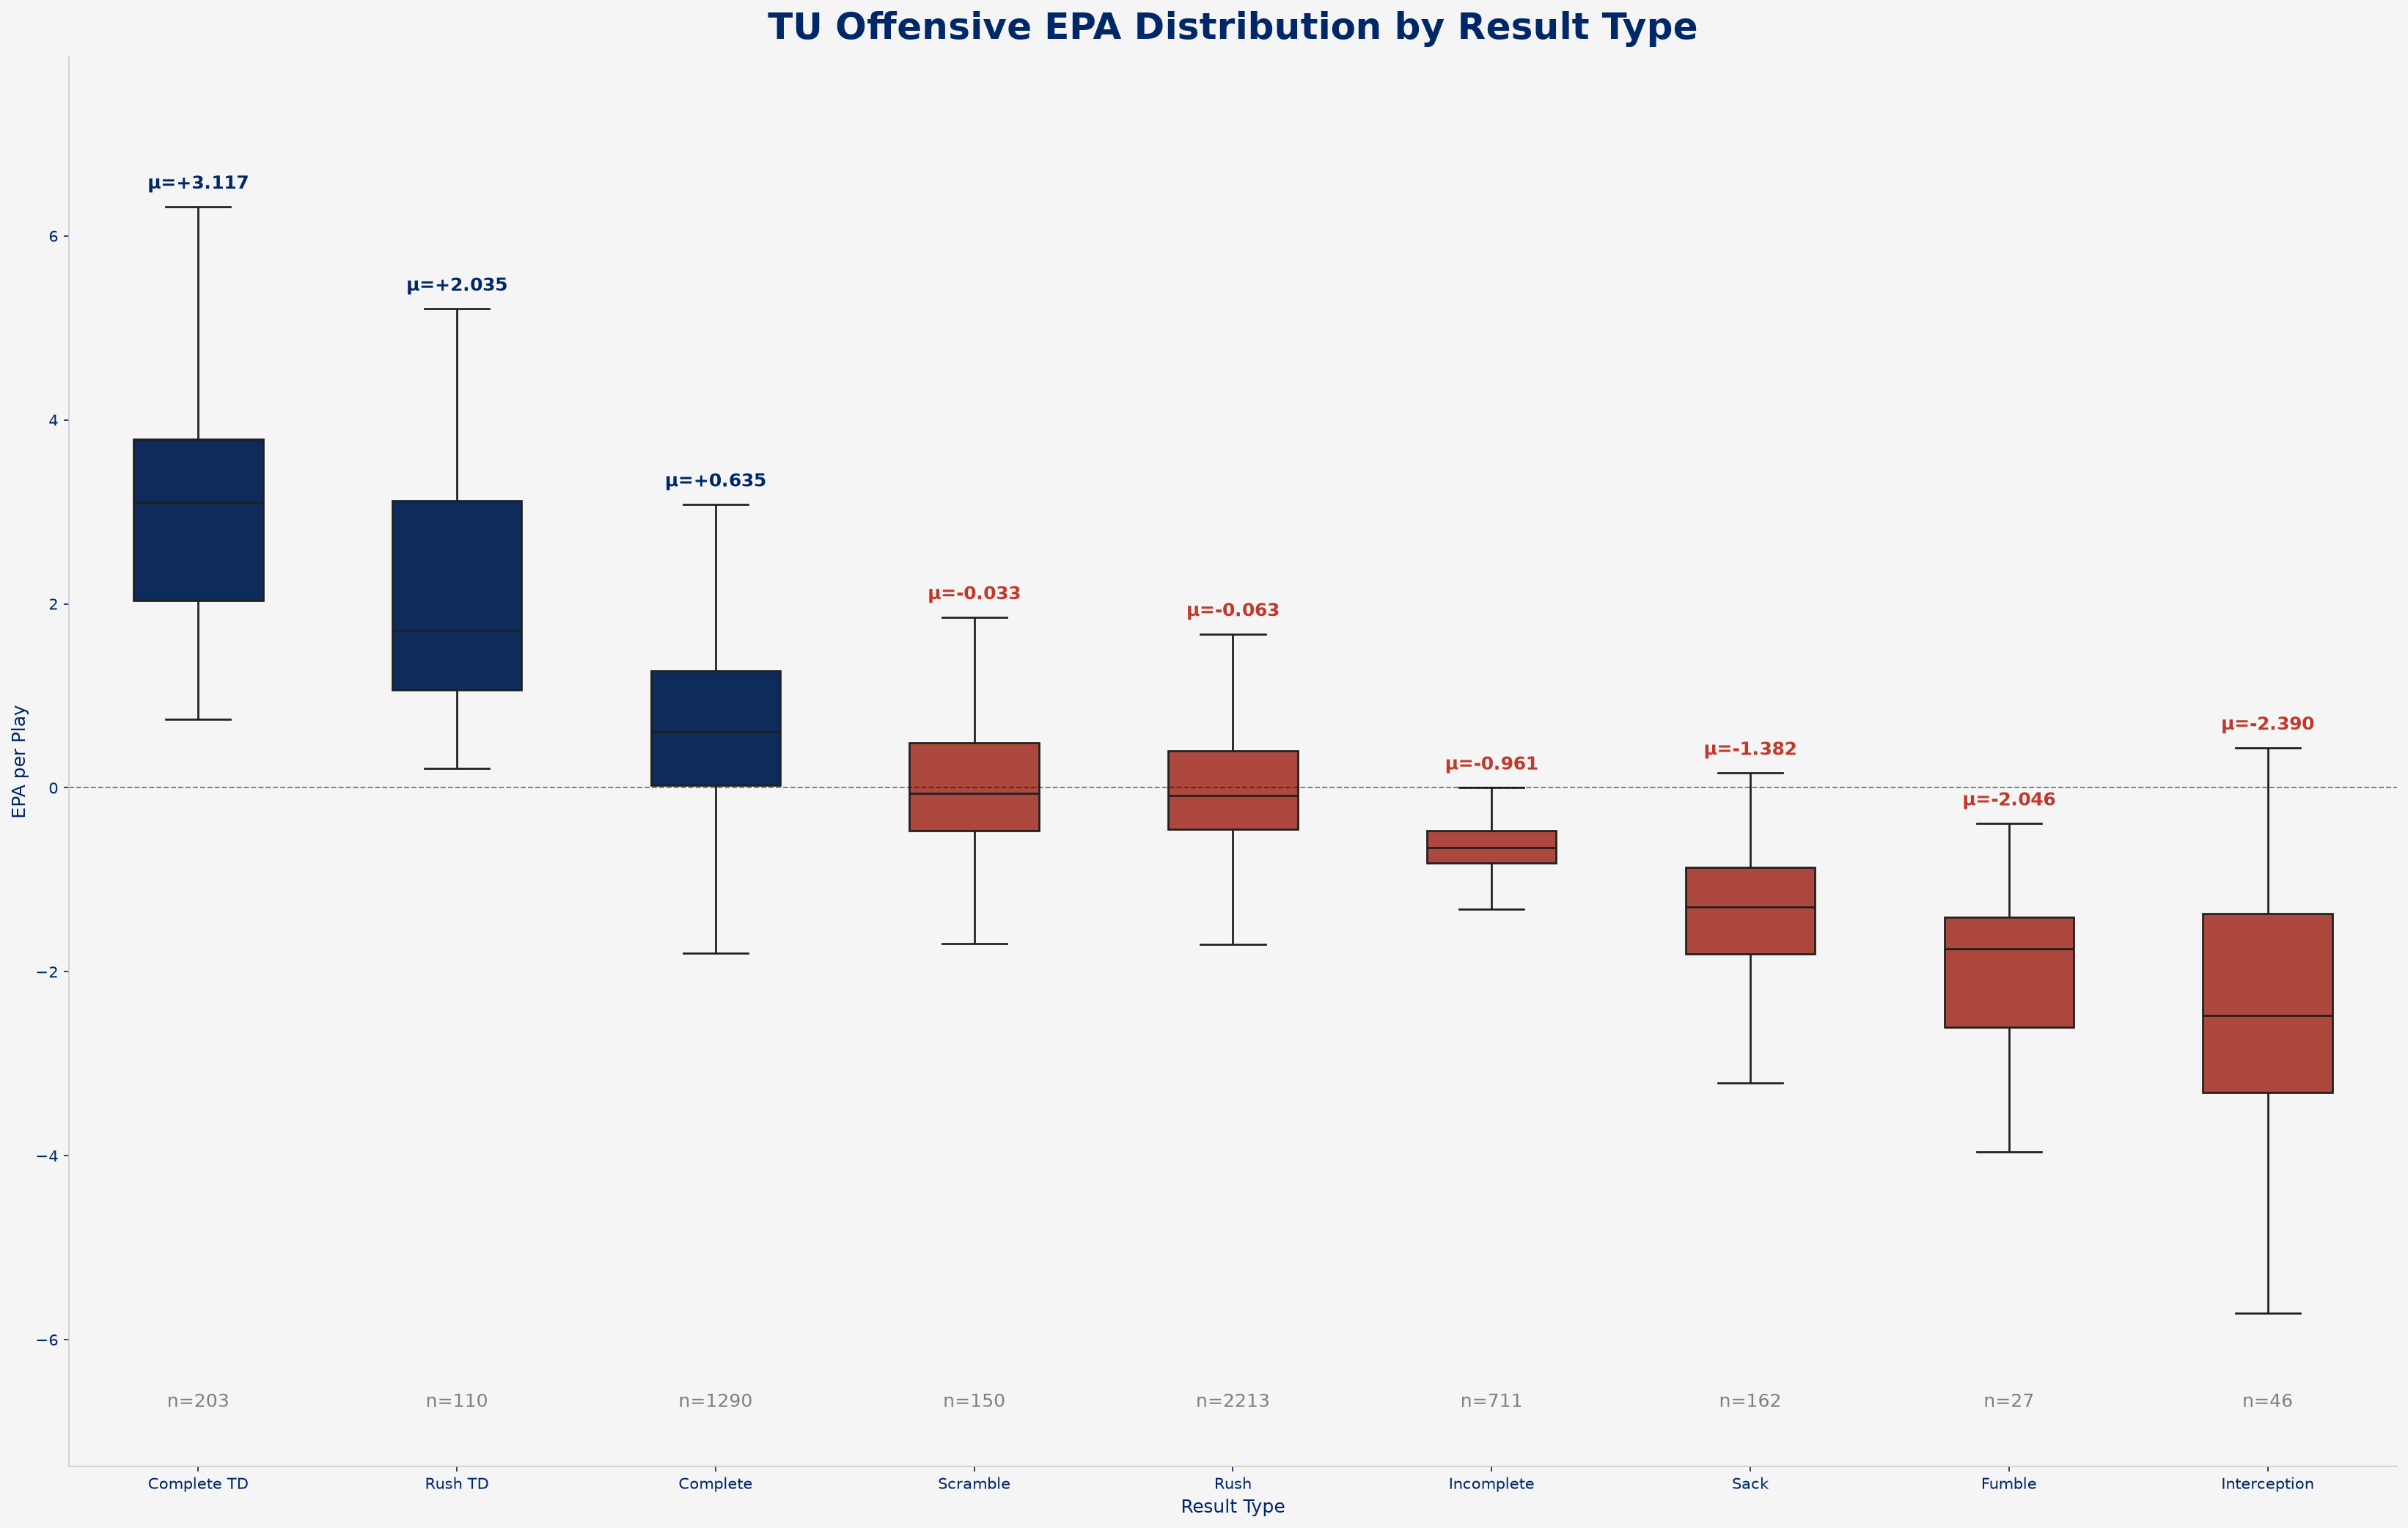

In [11]:

off_df = tu_df[
    (tu_df['odk'] == 'o') & (tu_df['epa'].notna()) & (tu_df['result'].notna())
].copy()
off_df['result'] = off_df['result'].str.strip().str.lower()

keep_results = ['rush','complete','incomplete','interception',
                'sack','scramble','complete, td','rush, td','fumble']
off_df = off_df[off_df['result'].isin(keep_results)].copy()

label_map = {
    'rush':'Rush', 'complete':'Complete', 'incomplete':'Incomplete',
    'interception':'Interception', 'sack':'Sack', 'scramble':'Scramble',
    'complete, td':'Complete TD', 'rush, td':'Rush TD', 'fumble':'Fumble'
}
off_df['result_label'] = off_df['result'].map(label_map)

result_order = (
    off_df.groupby('result_label')['epa'].median()
    .sort_values(ascending=False).index.tolist()
)
median_vals = off_df.groupby('result_label')['epa'].median()
box_colors  = {r: (TU_BLUE if median_vals[r] >= 0 else RED) for r in result_order}

fig, ax = plt.subplots(figsize=(22, 14))
fig.patch.set_facecolor(LIGHT_GRAY)
ax.set_facecolor(LIGHT_GRAY)

sns.boxplot(data=off_df, x='result_label', y='epa', order=result_order,
            palette=box_colors, width=0.5, linewidth=1.3,
            flierprops=dict(marker='o', markersize=3, alpha=0.3,
                            linestyle='none', markeredgewidth=0), ax=ax)

for i, result in enumerate(result_order):
    subset      = off_df[off_df['result_label'] == result]['epa']
    Q3          = subset.quantile(0.75)
    whisker_top = subset[subset <= Q3 + 1.5*(Q3-subset.quantile(0.25))].max()
    ax.text(i, whisker_top + 0.15, f'μ={subset.mean():+.3f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold',
            color=TU_BLUE if median_vals[result] >= 0 else RED)
    ax.text(i, ax.get_ylim()[0]+0.1, f'n={len(subset)}',
            ha='center', va='bottom', fontsize=12, color='gray')

ax.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.5)
ax.set_title('TU Offensive EPA Distribution by Result Type',
             fontsize=24, fontweight='bold', color=TU_BLUE, pad=12)
ax.set_xlabel('Result Type', fontsize=12, color=TU_BLUE)
ax.set_ylabel('EPA per Play', fontsize=12, color=TU_BLUE)
ax.set_ylim(bottom=ax.get_ylim()[0]-0.5, top=ax.get_ylim()[1]+1.0)
ax.tick_params(colors=TU_BLUE)
ax.spines[['top','right']].set_visible(False)
ax.spines[['left','bottom']].set_color('#CCCCCC')
plt.tight_layout()
plt.show()



## 10 · Run vs. Pass Distribution
> **So what?** A wide distribution = high upside, high risk. Run EPA below zero doesn't mean stop running — it means be more selective about when.


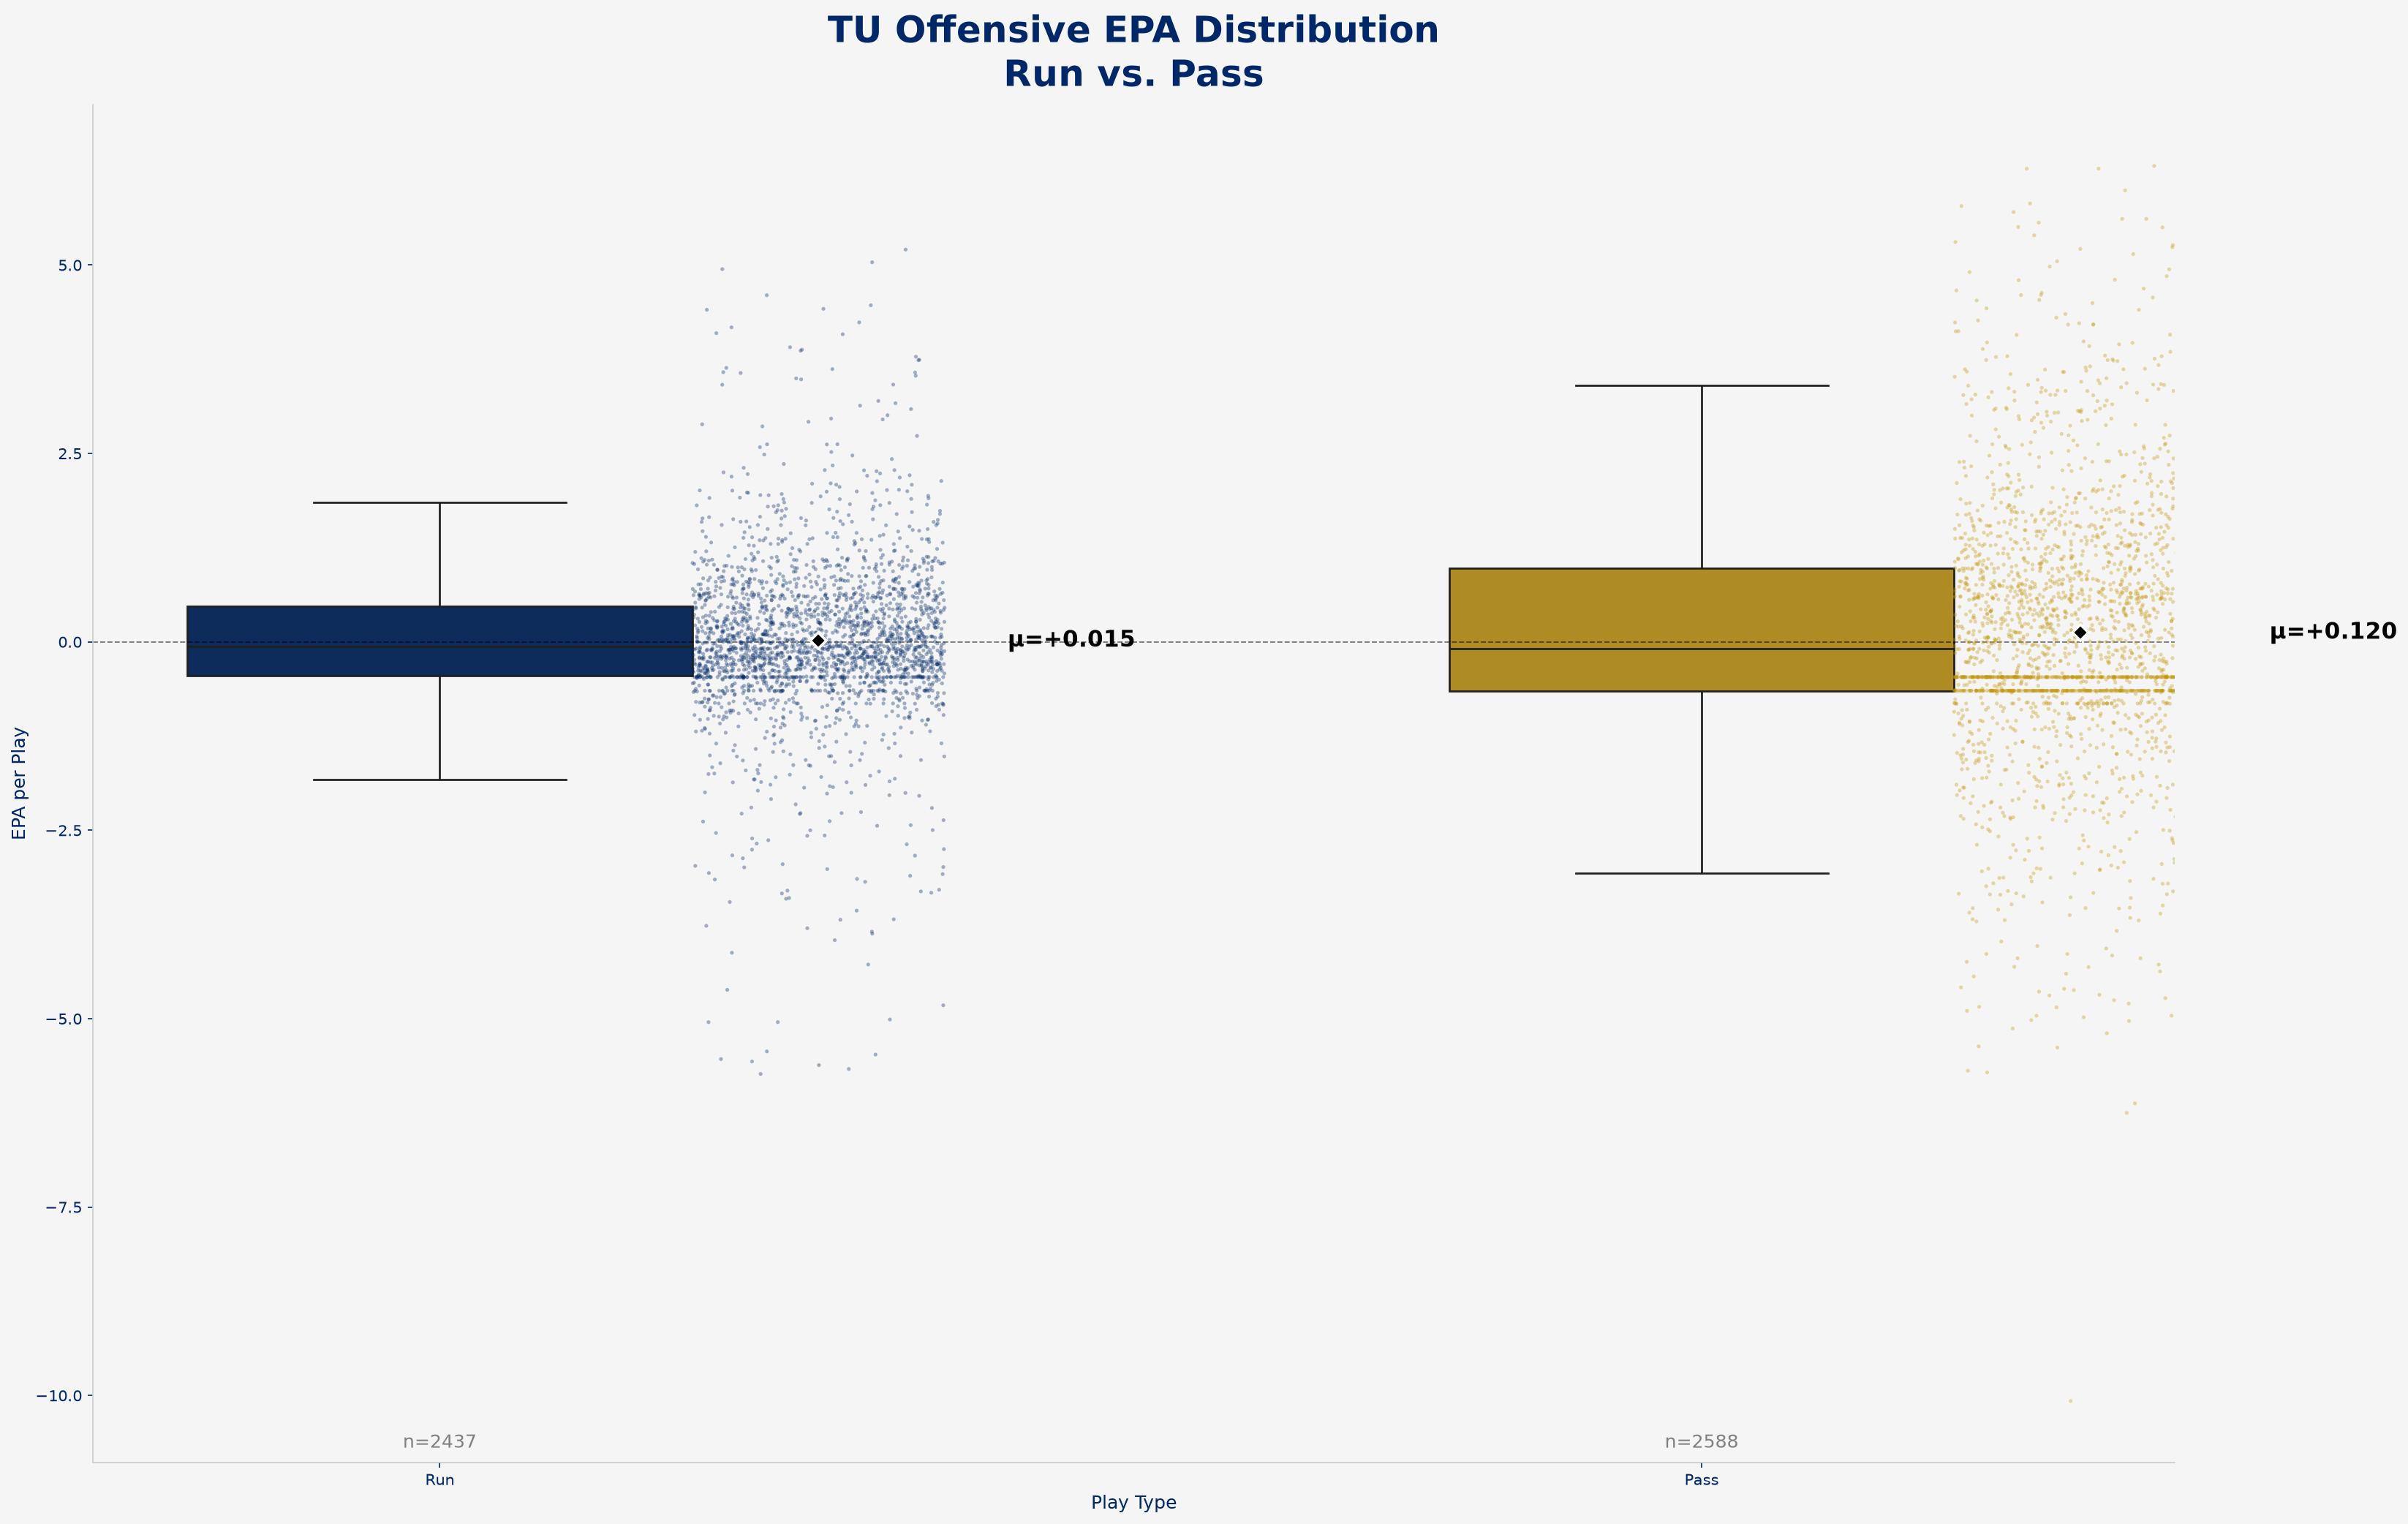

In [12]:

off_df = tu_df[(tu_df['odk'] == 'o') & (tu_df['epa'].notna())].copy()
rp_df  = off_df[off_df['play_type'].isin(['run','pass'])].copy()
rp_df['play_type'] = rp_df['play_type'].str.capitalize()
palette = {'Run': TU_BLUE, 'Pass': TU_GOLD}

fig, ax = plt.subplots(figsize=(22, 14))
fig.patch.set_facecolor(LIGHT_GRAY)
ax.set_facecolor(LIGHT_GRAY)

sns.boxplot(data=rp_df, x='play_type', y='epa', palette=palette,
            order=['Run','Pass'], width=0.4, linewidth=1.3,
            flierprops=dict(marker='', markersize=0), ax=ax)
sns.stripplot(data=rp_df, x='play_type', y='epa', palette=palette,
              order=['Run','Pass'], size=2.5, alpha=0.35, jitter=True, ax=ax)

OFFSET = 0.3
for i, collection in enumerate(ax.collections):
    offsets = collection.get_offsets()
    offsets[:, 0] += OFFSET
    collection.set_offsets(offsets)

for i, pt in enumerate(['Run','Pass']):
    subset   = rp_df[rp_df['play_type'] == pt]
    mean_val = subset['epa'].mean()
    count    = len(subset)
    ax.plot(i + OFFSET, mean_val, marker='D', color='white', markersize=8, zorder=5)
    ax.plot(i + OFFSET, mean_val, marker='D', color='black', markersize=5, zorder=6)
    ax.text(i + OFFSET + 0.15, mean_val, f'μ={mean_val:+.3f}',
            va='center', fontsize=15, fontweight='bold', color='black')
    ax.text(i, ax.get_ylim()[0]+0.2, f'n={count}',
            ha='center', fontsize=12, color='gray')

ax.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.5)
ax.set_title('TU Offensive EPA Distribution\nRun vs. Pass',
             fontsize=24, fontweight='bold', color=TU_BLUE, pad=12)
ax.set_xlabel('Play Type', fontsize=12, color=TU_BLUE)
ax.set_ylabel('EPA per Play', fontsize=12, color=TU_BLUE)
ax.tick_params(colors=TU_BLUE)
ax.spines[['top','right']].set_visible(False)
ax.spines[['left','bottom']].set_color('#CCCCCC')
plt.tight_layout()
plt.show()



## 11 · EPA by Distance to Go
> **So what?** Frequent long-distance situations (11+) means 1st/2nd down broke down. Preventing long-distance matters more than the play call once you're in it.


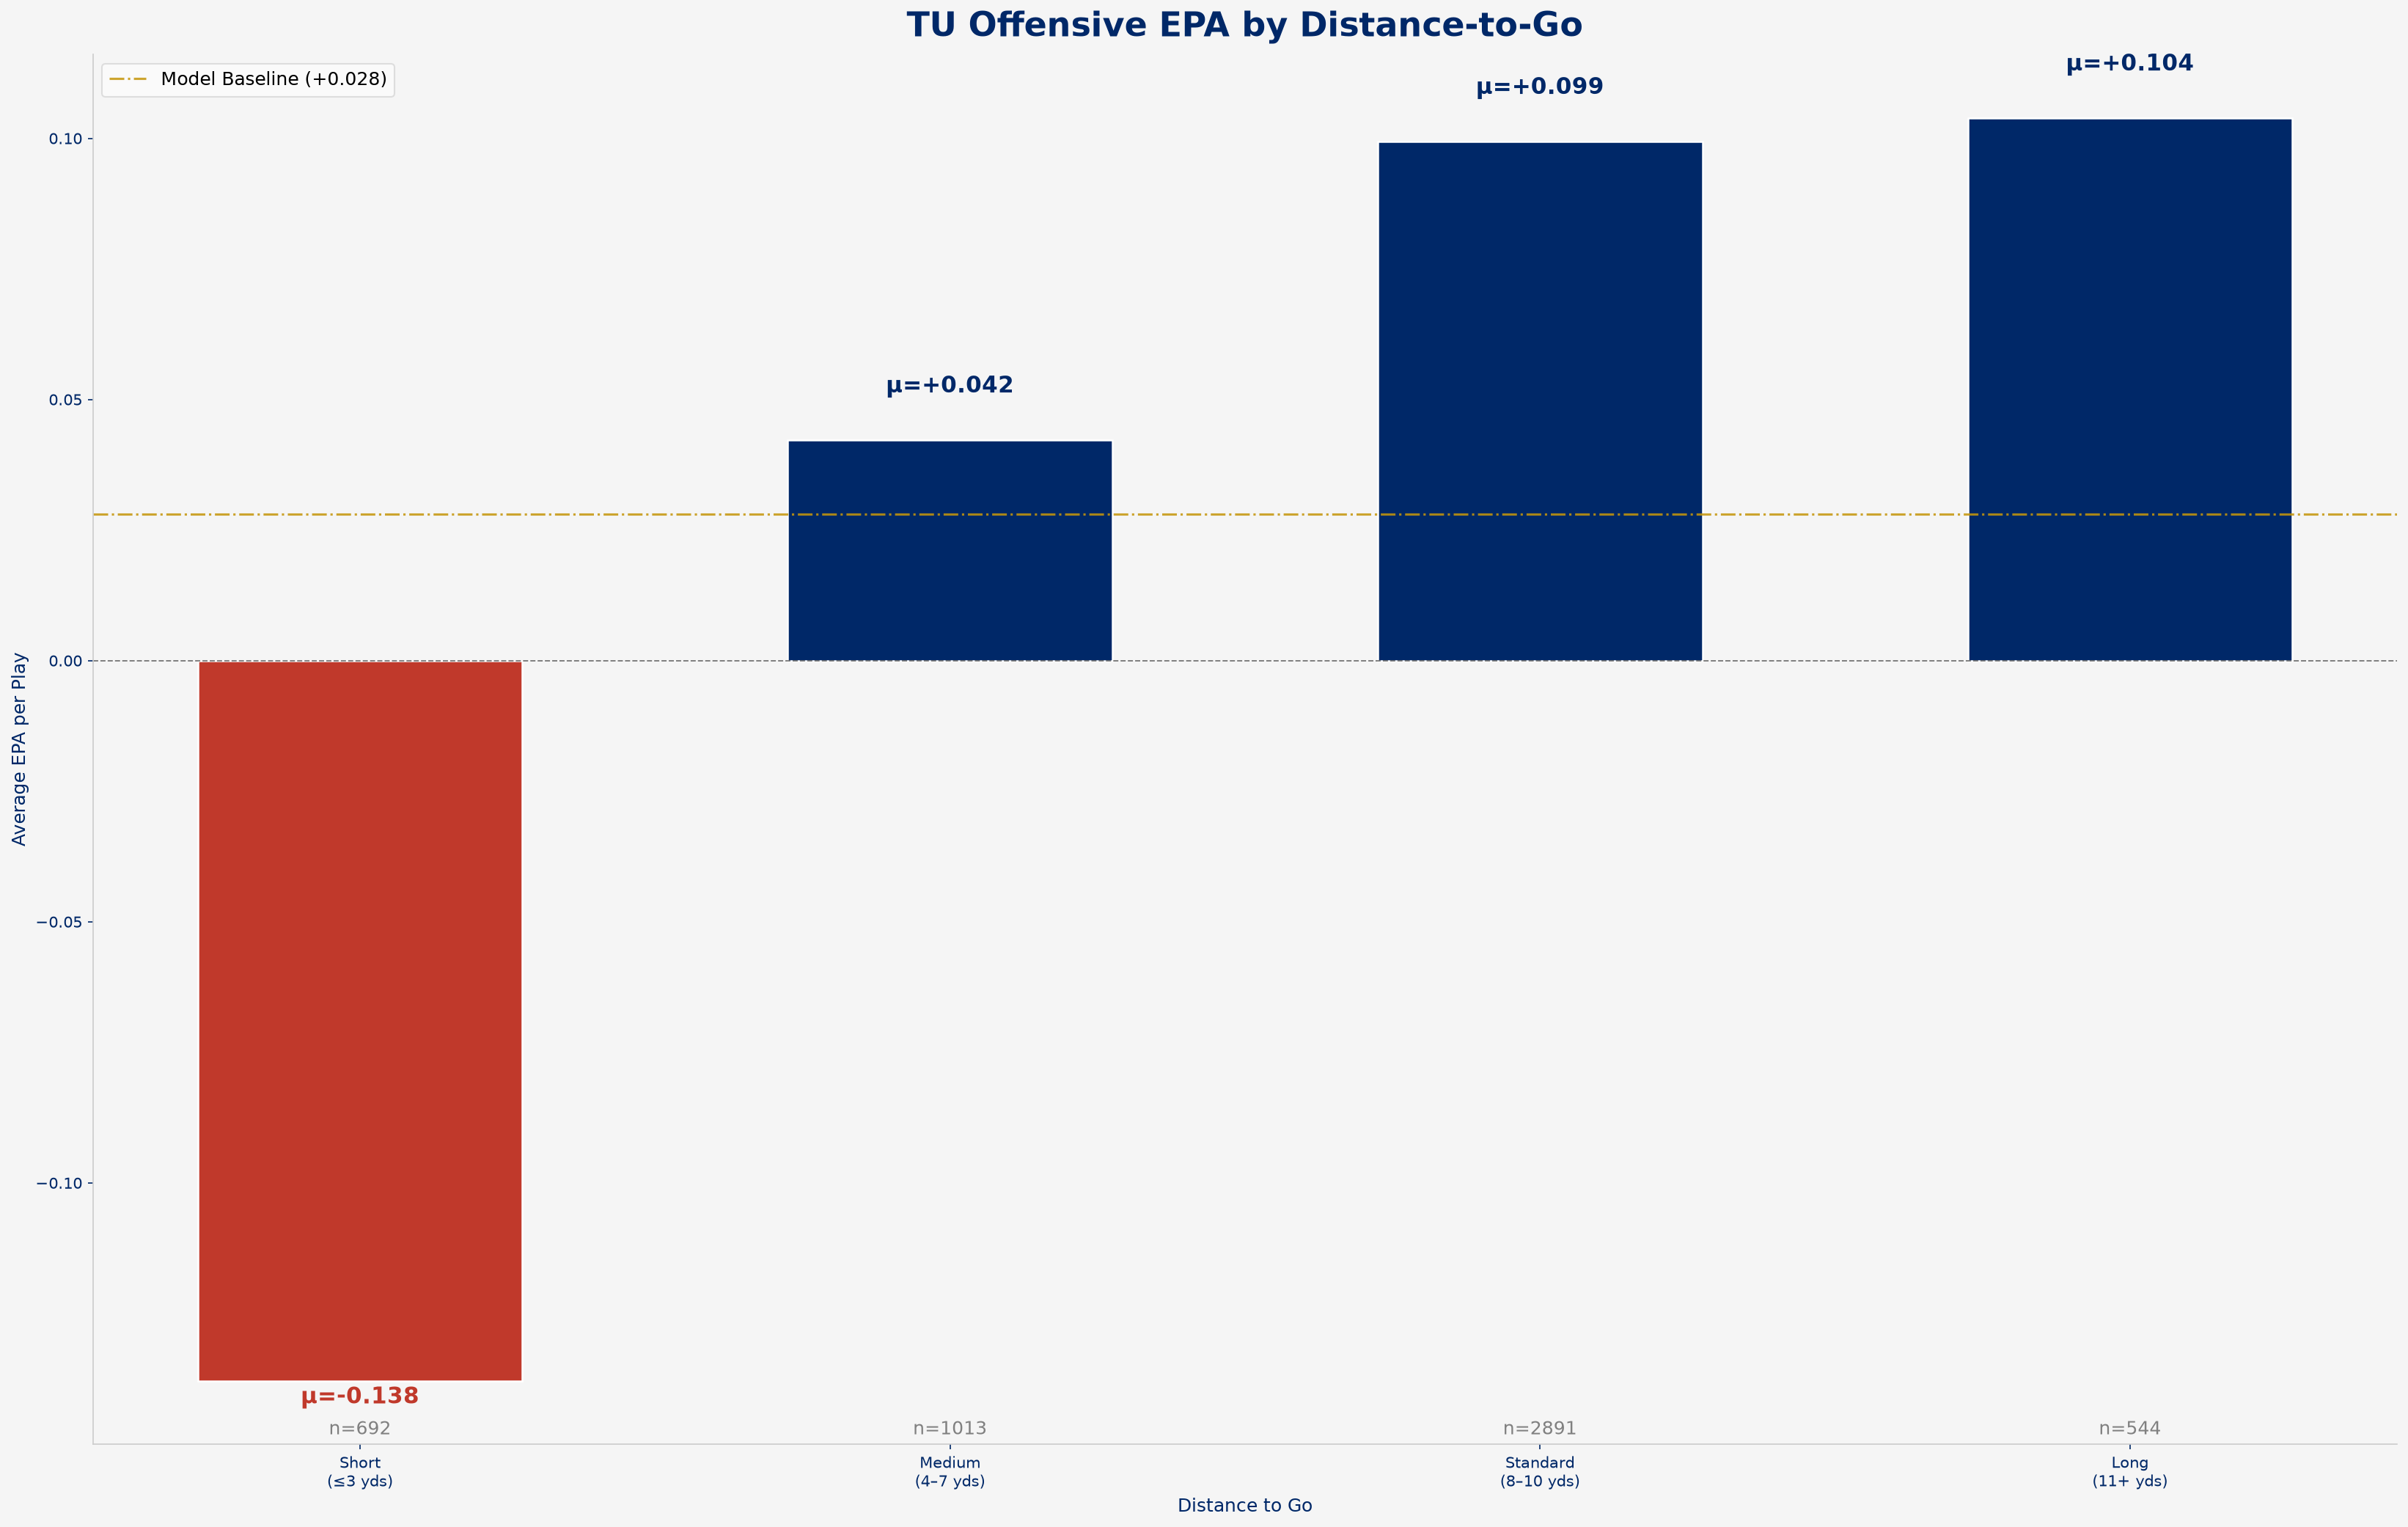

In [13]:

off_df = tu_df[
    (tu_df['odk'] == 'o') & (tu_df['epa'].notna()) & (tu_df['dist'].notna())
].copy()

bins   = [0, 3, 7, 10, float('inf')]
labels = ['Short\n(≤3 yds)', 'Medium\n(4–7 yds)',
          'Standard\n(8–10 yds)', 'Long\n(11+ yds)']
off_df['dist_bucket'] = pd.cut(off_df['dist'], bins=bins,
                                labels=labels, include_lowest=True)

dist_df = (
    off_df.groupby('dist_bucket', observed=True)['epa']
    .agg(['mean','sem','count']).reset_index()
)

fig, ax = plt.subplots(figsize=(22, 14))
fig.patch.set_facecolor(LIGHT_GRAY)
ax.set_facecolor(LIGHT_GRAY)

bars = ax.bar(dist_df['dist_bucket'], dist_df['mean'],
              color=[TU_BLUE if v >= 0 else RED for v in dist_df['mean']],
              edgecolor='white', linewidth=1.2, width=0.55)
ax.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.5)
ax.axhline(MODEL_BASELINE, color=TU_GOLD, linewidth=1.5, linestyle='-.',
           alpha=0.85, label='Model Baseline (+0.028)')
ax.legend(fontsize=12, framealpha=0.6, edgecolor='#CCCCCC')

for bar, row in zip(bars, dist_df.itertuples()):
    ax.text(bar.get_x()+bar.get_width()/2,
            row.mean + 0.008 if row.mean >= 0 else row.mean - 0.001,
            f'μ={row.mean:+.3f}', ha='center',
            va='bottom' if row.mean >= 0 else 'top',
            fontsize=15, fontweight='bold',
            color=TU_BLUE if row.mean >= 0 else RED)
    ax.text(bar.get_x()+bar.get_width()/2, ax.get_ylim()[0]+0.001,
            f'n={row.count}', ha='center', va='bottom', fontsize=12, color='gray')

ax.set_title('TU Offensive EPA by Distance-to-Go',
             fontsize=22, fontweight='bold', color=TU_BLUE, pad=12)
ax.set_xlabel('Distance to Go', fontsize=12, color=TU_BLUE)
ax.set_ylabel('Average EPA per Play', fontsize=12, color=TU_BLUE)
ax.tick_params(colors=TU_BLUE)
ax.spines[['top','right']].set_visible(False)
ax.spines[['left','bottom']].set_color('#CCCCCC')
plt.tight_layout()
plt.show()



## 12a · EPA by Personnel Grouping
> **So what?** Your highest-EPA personnel package should be getting the most snaps. If it isn't, that's an immediate correction.


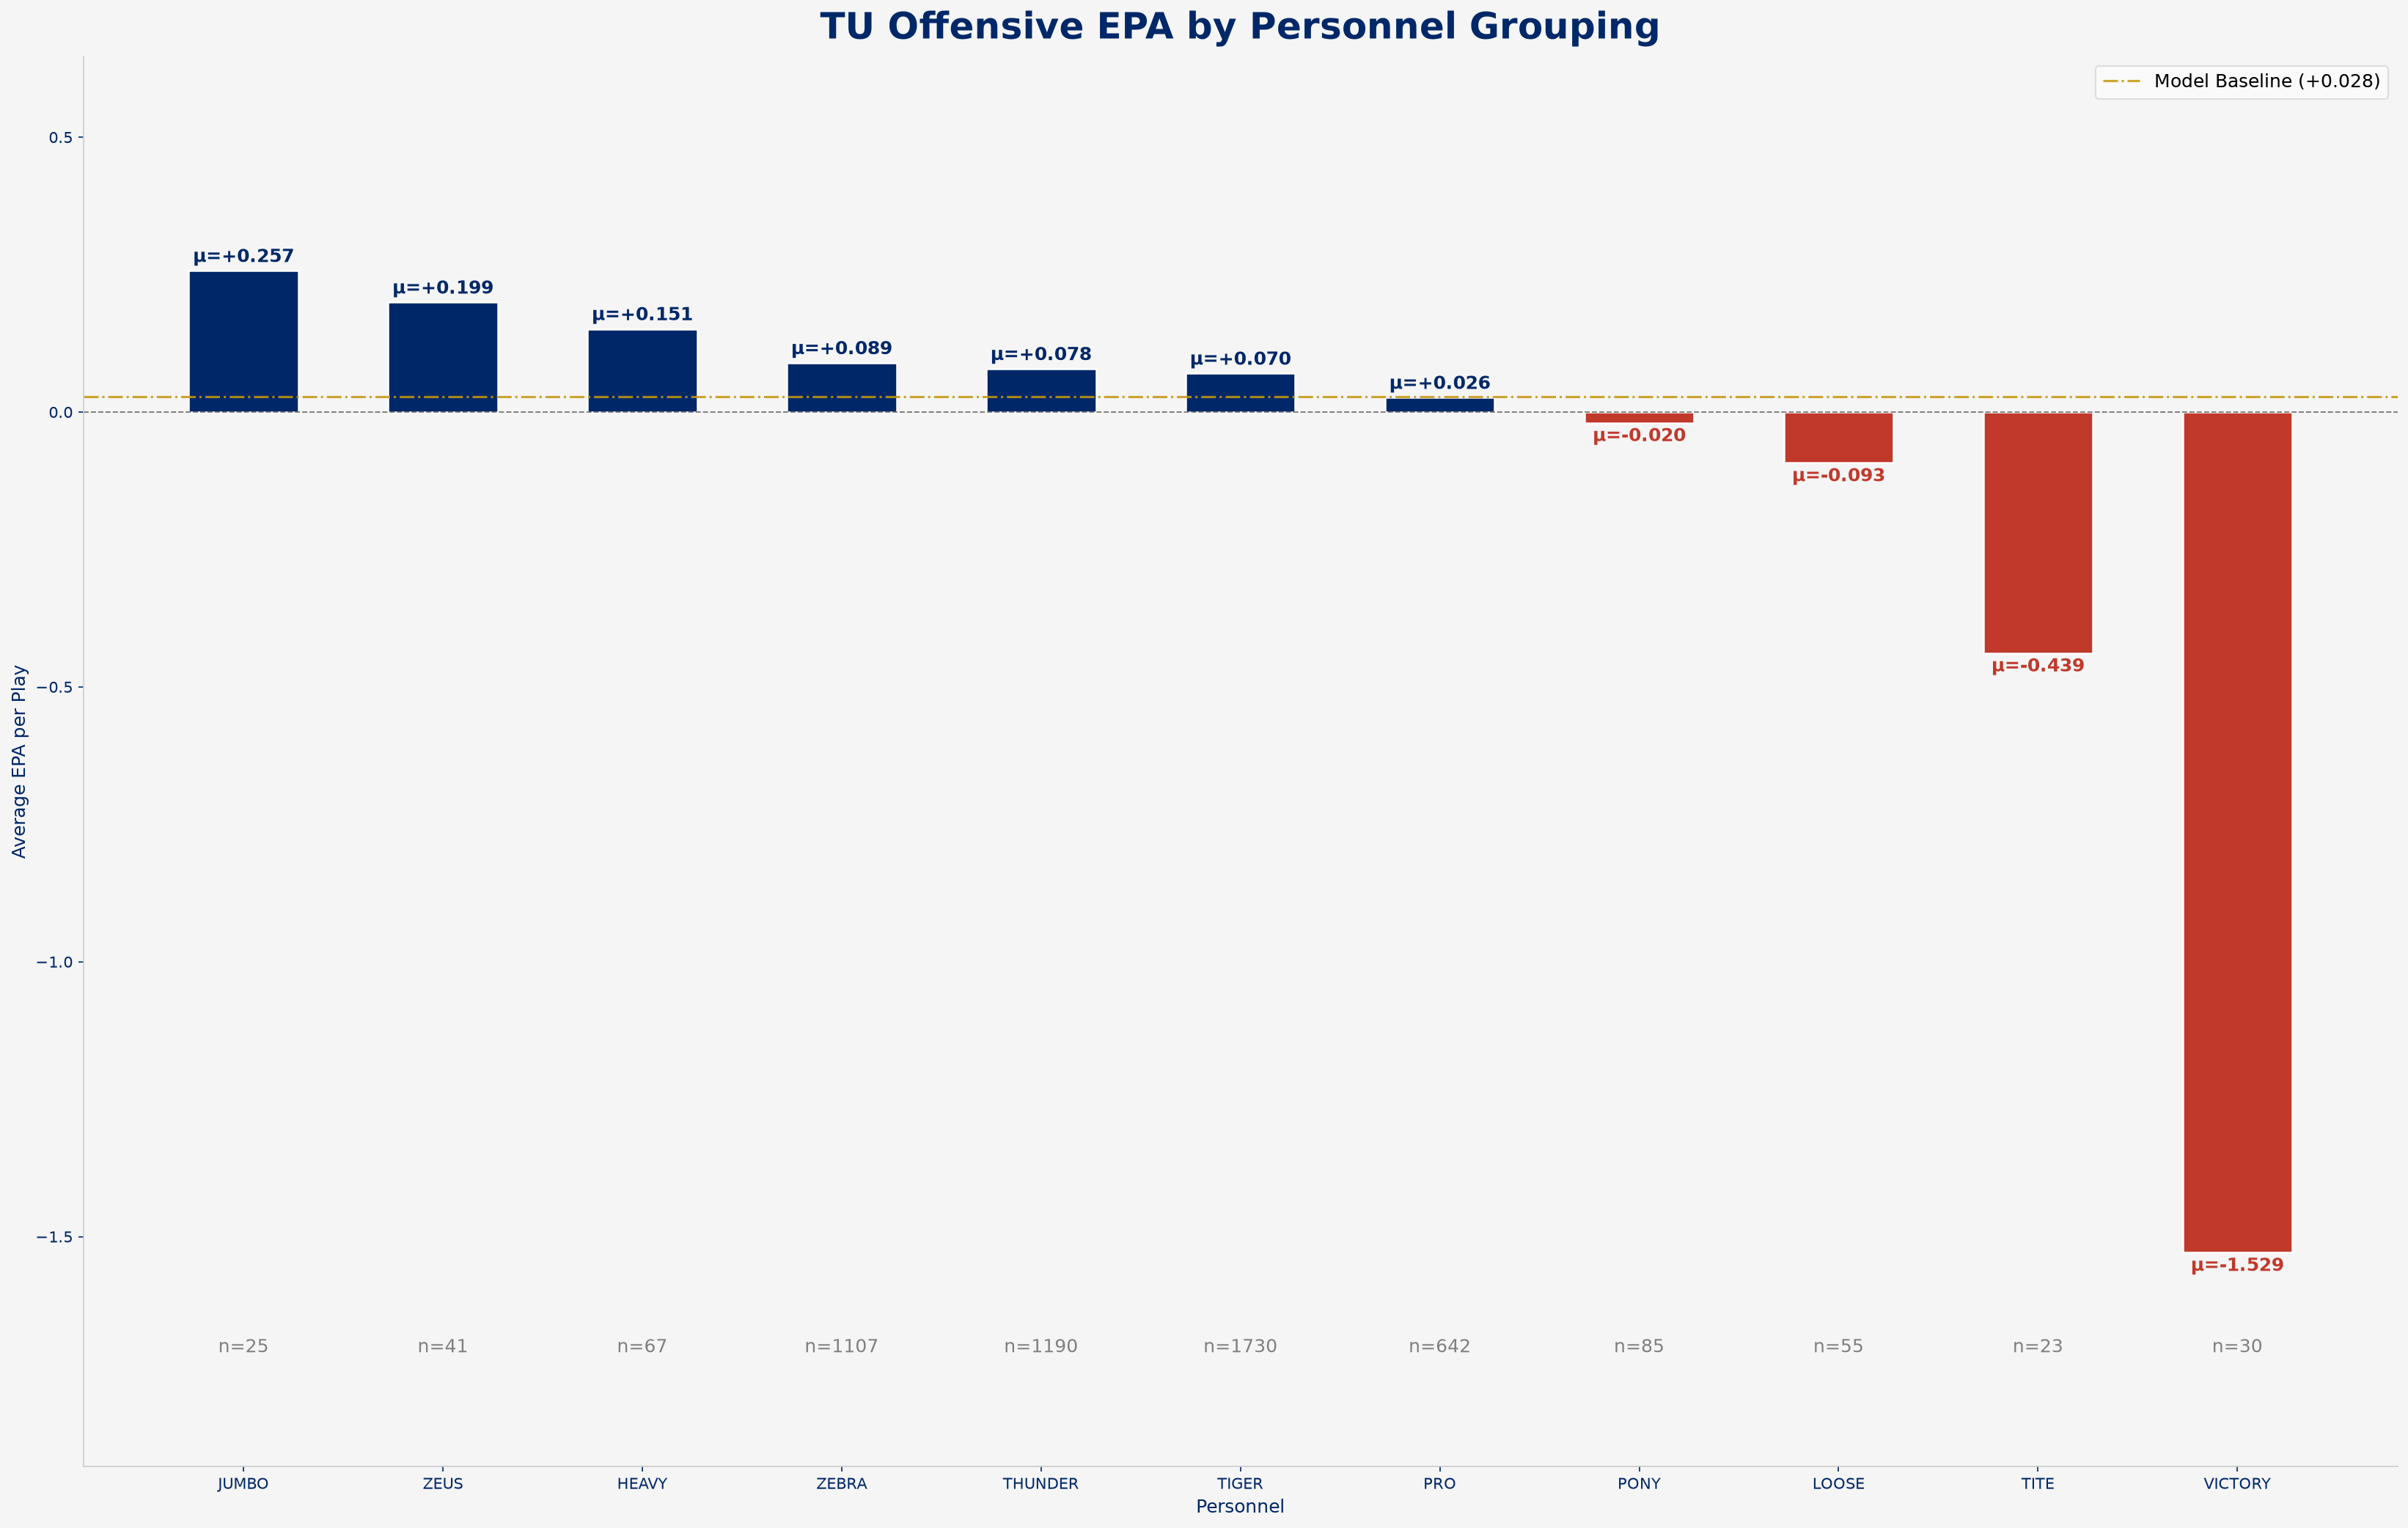

In [14]:

off_df = tu_df[
    (tu_df['odk'] == 'o') & (tu_df['epa'].notna()) & (tu_df['personnel'].notna())
].copy()

pers_df = (
    off_df.groupby('personnel')['epa']
    .agg(['mean','sem','count']).reset_index()
)
pers_df = pers_df[pers_df['count'] >= 20].sort_values('mean', ascending=False)

fig, ax = plt.subplots(figsize=(22, 14))
fig.patch.set_facecolor(LIGHT_GRAY)
ax.set_facecolor(LIGHT_GRAY)

bars = ax.bar(pers_df['personnel'], pers_df['mean'],
              color=[TU_BLUE if v >= 0 else RED for v in pers_df['mean']],
              edgecolor='white', linewidth=1.2, width=0.55)
ax.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.5)
ax.axhline(MODEL_BASELINE, color=TU_GOLD, linewidth=1.5, linestyle='-.',
           alpha=0.85, label='Model Baseline (+0.028)')
ax.legend(fontsize=12, framealpha=0.6, edgecolor='#CCCCCC')

for bar, row in zip(bars, pers_df.itertuples()):
    ax.text(bar.get_x()+bar.get_width()/2,
            row.mean + 0.008 if row.mean >= 0 else row.mean - 0.008,
            f'μ={row.mean:+.3f}', ha='center',
            va='bottom' if row.mean >= 0 else 'top',
            fontsize=12, fontweight='bold',
            color=TU_BLUE if row.mean >= 0 else RED)
    ax.text(bar.get_x()+bar.get_width()/2, ax.get_ylim()[0]-0.1,
            f'n={row.count}', ha='center', va='bottom', fontsize=12, color='gray')

ax.set_title('TU Offensive EPA by Personnel Grouping',
             fontsize=24, fontweight='bold', color=TU_BLUE, pad=12)
ax.set_xlabel('Personnel', fontsize=12, color=TU_BLUE)
ax.set_ylabel('Average EPA per Play', fontsize=12, color=TU_BLUE)
ax.set_ylim(bottom=ax.get_ylim()[0]-0.3, top=ax.get_ylim()[1]+0.3)
ax.tick_params(colors=TU_BLUE)
ax.spines[['top','right']].set_visible(False)
ax.spines[['left','bottom']].set_color('#CCCCCC')
plt.tight_layout()
plt.show()



## 12b · EPA by Formation
> **So what?** High usage + low EPA = fixable inefficiency. Find the formations that outperform and replicate them.


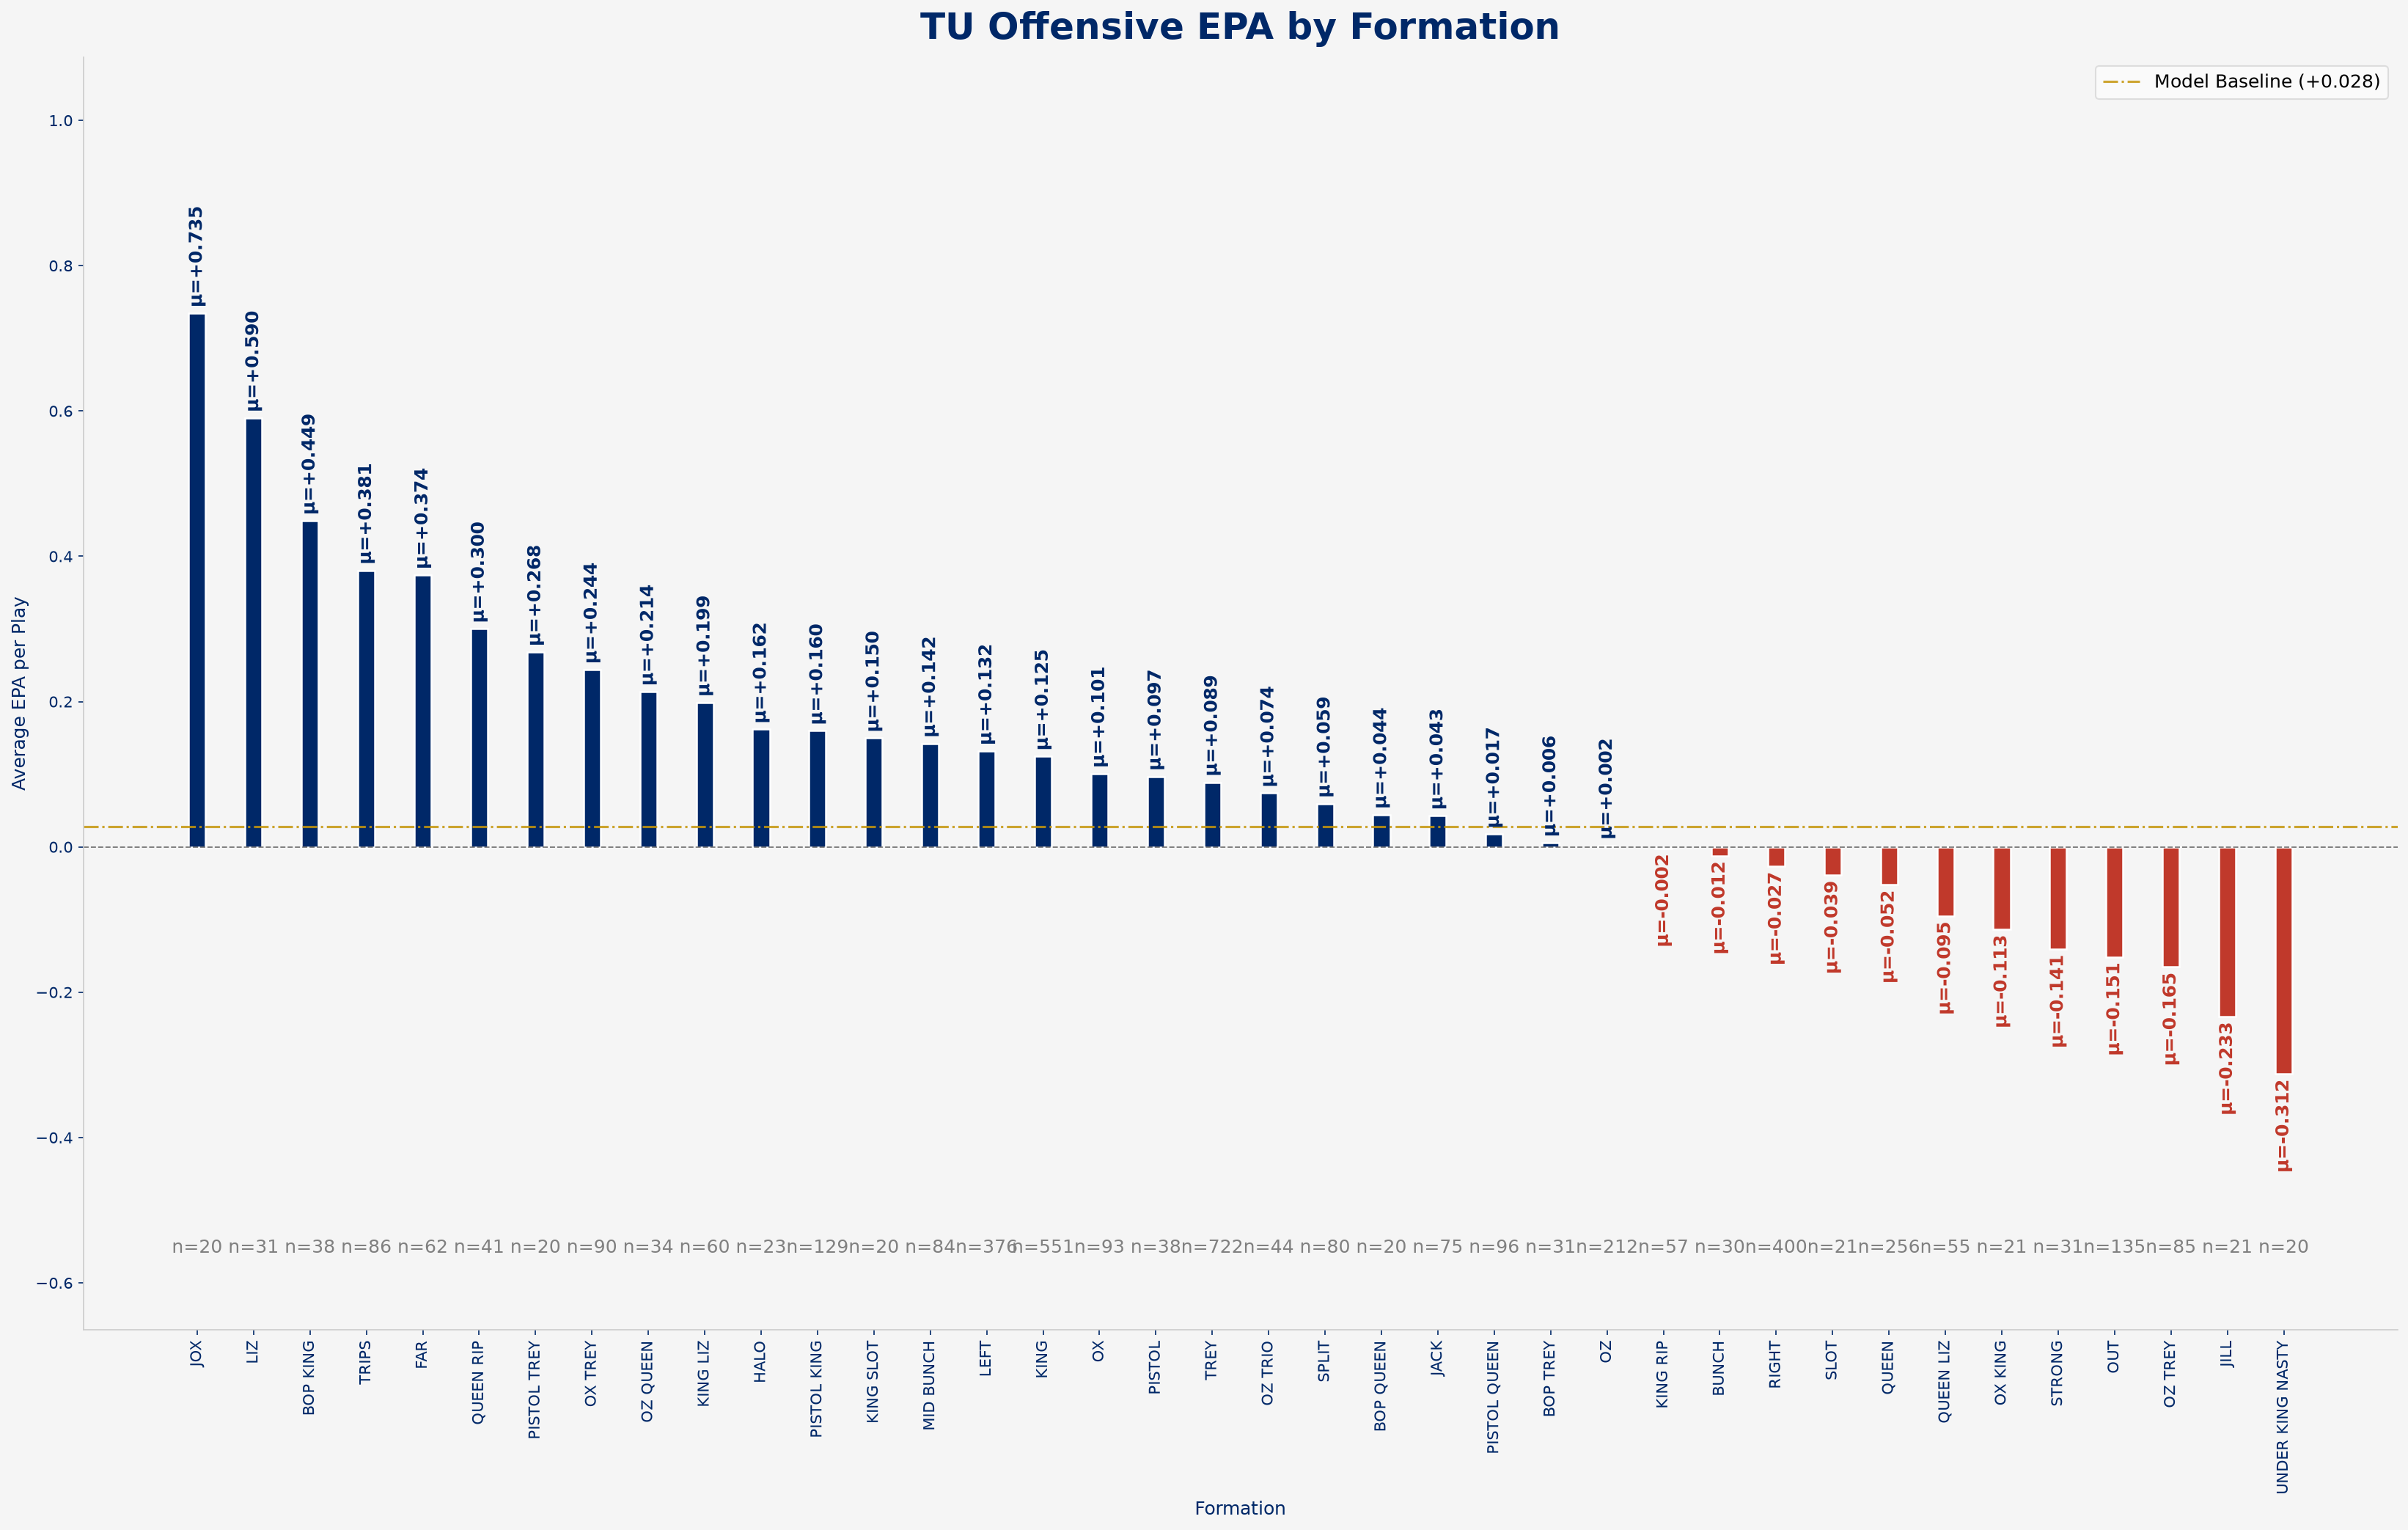

In [15]:

off_df = tu_df[
    (tu_df['odk'] == 'o') & (tu_df['epa'].notna()) & (tu_df['off_form'].notna())
].copy()

def normalize_formation(form):
    form = str(form).strip().upper()
    if form in ['RIGHT', 'LEFT']:
        return form
    form = re.sub(r'\bRIGHT\b', '', form)
    form = re.sub(r'\bLEFT\b', '', form)
    return ' '.join(form.split()) or 'OTHER'

off_df['form_normalized'] = off_df['off_form'].apply(normalize_formation)

form_df = (
    off_df.groupby('form_normalized')['epa']
    .agg(['mean','sem','count']).reset_index()
)
form_df = form_df[form_df['count'] >= 20].sort_values('mean', ascending=False)

fig, ax = plt.subplots(figsize=(22, 14))
fig.patch.set_facecolor(LIGHT_GRAY)
ax.set_facecolor(LIGHT_GRAY)

bars = ax.bar(form_df['form_normalized'], form_df['mean'],
              color=[TU_BLUE if v >= 0 else RED for v in form_df['mean']],
              edgecolor='white', linewidth=1.2, width=0.3)
ax.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.5)
ax.axhline(MODEL_BASELINE, color=TU_GOLD, linewidth=1.5, linestyle='-.',
           alpha=0.85, label='Model Baseline (+0.028)')
ax.legend(fontsize=12, framealpha=0.6, edgecolor='#CCCCCC')

for bar, row in zip(bars, form_df.itertuples()):
    ax.text(bar.get_x()+bar.get_width()/2,
            row.mean + 0.008 if row.mean >= 0 else row.mean - 0.008,
            f'μ={row.mean:+.3f}', ha='center',
            va='bottom' if row.mean >= 0 else 'top',
            fontsize=12, fontweight='bold', rotation=90,
            color=TU_BLUE if row.mean >= 0 else RED)
    ax.text(bar.get_x()+bar.get_width()/2, ax.get_ylim()[0]-0.2,
            f'n={row.count}', ha='center', va='bottom', fontsize=12, color='gray')

ax.set_title('TU Offensive EPA by Formation',
             fontsize=24, fontweight='bold', color=TU_BLUE, pad=12)
ax.set_xlabel('Formation', fontsize=12, color=TU_BLUE)
ax.set_ylabel('Average EPA per Play', fontsize=12, color=TU_BLUE)
ax.set_ylim(bottom=ax.get_ylim()[0]-0.3, top=ax.get_ylim()[1]+0.3)
ax.tick_params(axis='x', colors=TU_BLUE, rotation=90)
ax.tick_params(axis='y', colors=TU_BLUE)
ax.spines[['top','right']].set_visible(False)
ax.spines[['left','bottom']].set_color('#CCCCCC')
plt.tight_layout()
plt.show()



## 12c · Personnel × Formation (Interactive)
> **So what?** Click a personnel group to see formation EPA. Use this before game-planning — find the combinations that work and build around them.


In [16]:

off_df = tu_df[
    (tu_df['odk'] == 'o') & (tu_df['epa'].notna()) &
    (tu_df['personnel'].notna()) & (tu_df['off_form'].notna())
].copy()

def normalize_formation(form):
    form = str(form).strip().upper()
    if form in ['RIGHT', 'LEFT']:
        return form
    form = re.sub(r'\bRIGHT\b', '', form)
    form = re.sub(r'\bLEFT\b', '', form)
    return ' '.join(form.split()) or 'OTHER'

off_df['form_normalized'] = off_df['off_form'].apply(normalize_formation)

combo_df = (
    off_df.groupby(['personnel', 'form_normalized'])['epa']
    .agg(['mean','sem','count']).reset_index()
    .rename(columns={'form_normalized': 'formation'})
)
combo_df = combo_df[combo_df['count'] >= 10].copy()

personnel_list = (
    combo_df.groupby('personnel')['mean'].mean()
    .sort_values(ascending=False).index.tolist()
)
pers_colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd',
               '#8c564b','#e377c2','#7f7f7f','#bcbd22','#17becf']
pers_color_map = {p: pers_colors[i % len(pers_colors)]
                  for i, p in enumerate(personnel_list)}

fig = go.Figure()
for pers in personnel_list:
    d = combo_df[combo_df['personnel'] == pers].sort_values('mean', ascending=False)
    hover = [f"<b>{pers} | {r['formation']}</b><br>μ EPA: {r['mean']:+.3f}<br>n={int(r['count'])}"
             for _, r in d.iterrows()]
    fig.add_trace(go.Bar(
        x=d['formation'], y=d['mean'], name=pers,
        marker_color=[TU_BLUE if v >= 0 else RED for v in d['mean']],
        marker_line_color='white', marker_line_width=1.2,
        text=hover, hovertemplate='%{text}<extra></extra>',
        visible='legendonly', legendgroup=pers, showlegend=True
    ))

fig.add_hline(y=0, line_dash='dash', line_color='black', opacity=0.4, line_width=1.5)
n_traces = len(fig.data)
fig.update_layout(
    title=dict(
        text='TU Offensive EPA by Personnel & Formation<br>'
             '<sup>Click a personnel group to show its formations</sup>',
        font=dict(size=17, color=TU_BLUE), x=0.5, xanchor='center'),
    xaxis=dict(title='Formation', titlefont=dict(color=TU_BLUE),
               tickfont=dict(color=TU_BLUE), tickangle=45, gridcolor='#DDDDDD'),
    yaxis=dict(title='Average EPA per Play', titlefont=dict(color=TU_BLUE),
               tickfont=dict(color=TU_BLUE), gridcolor='#DDDDDD'),
    barmode='group',
    legend=dict(title=dict(text='Personnel', font=dict(color=TU_BLUE, size=11)),
                bgcolor='rgba(255,255,255,0.85)', bordercolor='#CCCCCC',
                borderwidth=1, font=dict(size=10)),
    updatemenus=[dict(
        type='buttons', showactive=False,
        x=1.0, xanchor='right', y=-0.08, yanchor='top',
        buttons=[
            dict(label='Show All', method='restyle',
                 args=[{'visible': True}, list(range(n_traces))]),
            dict(label='Hide All', method='restyle',
                 args=[{'visible': 'legendonly'}, list(range(n_traces))])
        ],
        bgcolor='white', bordercolor='#CCCCCC', font=dict(color=TU_BLUE, size=10)
    )],
    plot_bgcolor=LIGHT_GRAY, paper_bgcolor=LIGHT_GRAY,
    height=700, margin=dict(t=100, b=120, l=70, r=20)
)
fig.show()


<Plotly Figure>


## 12d · Explosive Rate by Personnel
> **So what?** High EPA + high explosive rate = your best personnel package. Use it more.


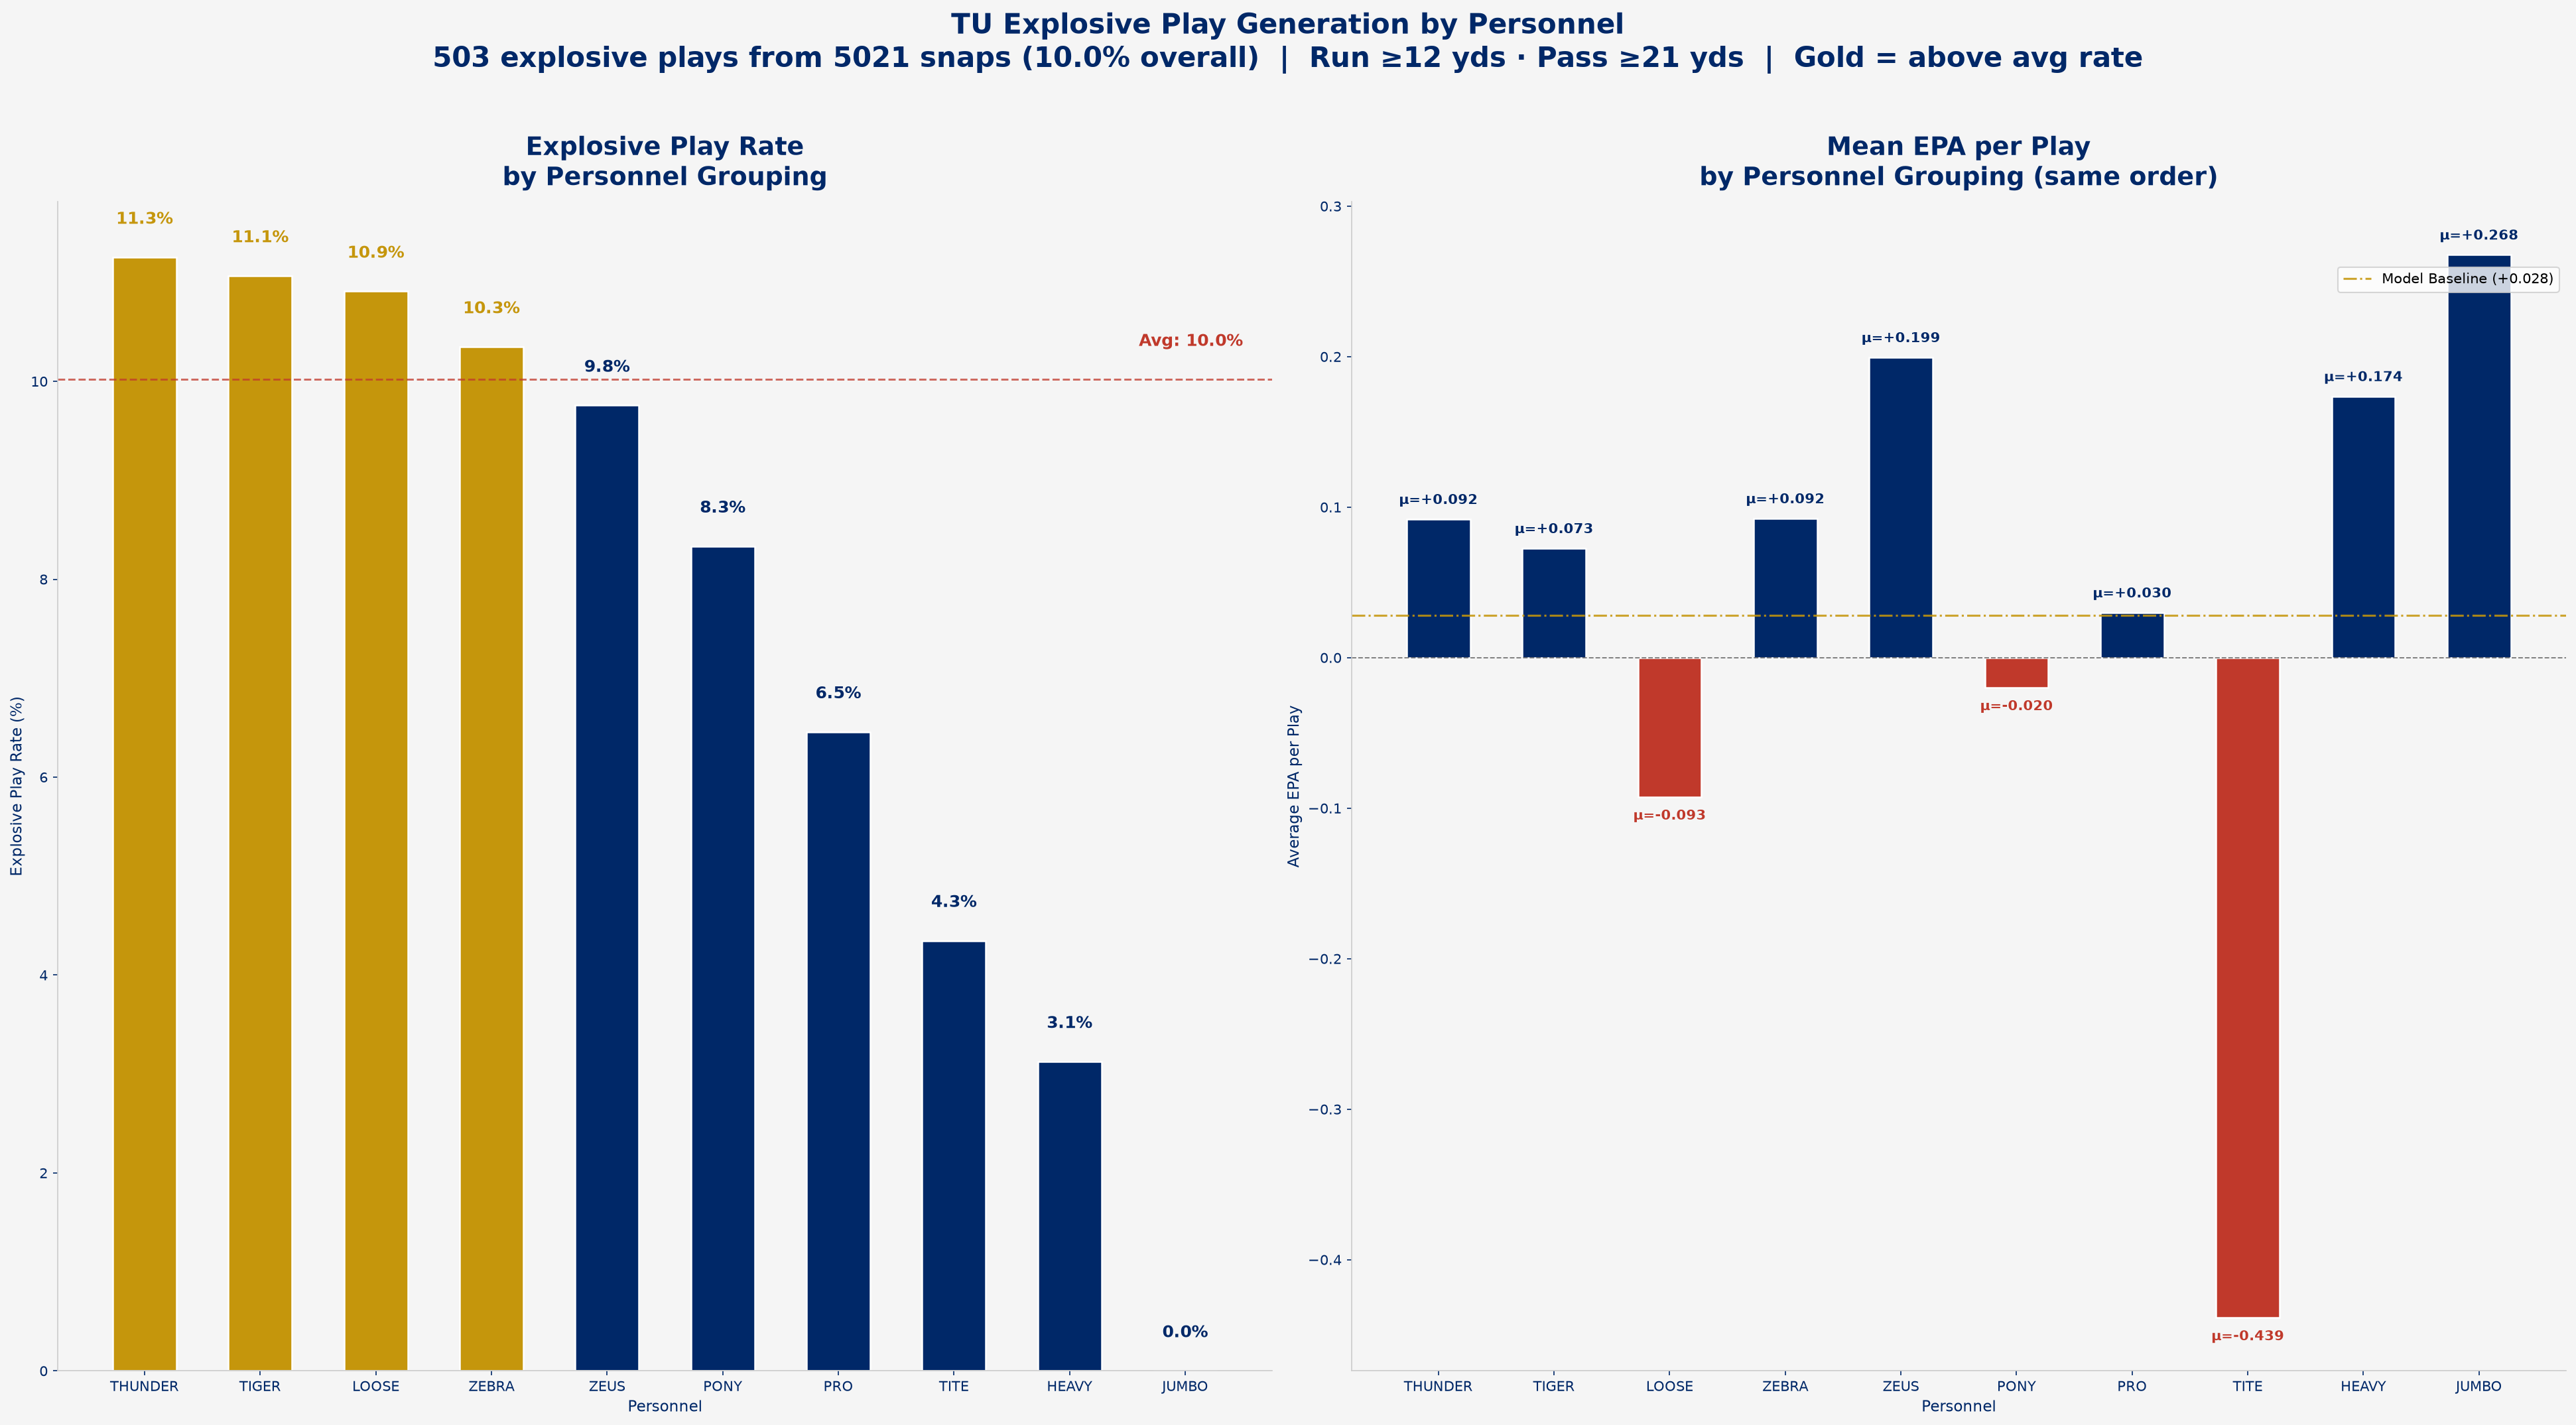

In [17]:

exp_pers = tu_df[
    (tu_df['odk'] == 'o') & (tu_df['play_type'].isin(['run','pass'])) &
    (tu_df['gn_ls'].notna()) & (tu_df['personnel'].notna()) & (tu_df['epa'].notna())
].copy()

exp_pers['explosive'] = (
    ((exp_pers['play_type'] == 'run')  & (exp_pers['gn_ls'] >= 12)) |
    ((exp_pers['play_type'] == 'pass') & (exp_pers['gn_ls'] >= 21))
)

pers_df = (
    exp_pers.groupby('personnel')
    .agg(exp_rate=('explosive','mean'), exp_count=('explosive','sum'),
         total=('explosive','count'), mean_epa=('epa','mean'))
    .reset_index()
)
pers_df = pers_df[pers_df['total'] >= 20].copy()
pers_df['exp_rate_pct'] = pers_df['exp_rate'] * 100
pers_df = pers_df.sort_values('exp_rate_pct', ascending=False).reset_index(drop=True)
overall_exp_rate = exp_pers['explosive'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(26, 14))
fig.patch.set_facecolor(LIGHT_GRAY)

ax1 = axes[0]
ax1.set_facecolor(LIGHT_GRAY)
bar_colors = [TU_GOLD if v >= overall_exp_rate else TU_BLUE
              for v in pers_df['exp_rate_pct']]
bars = ax1.bar(pers_df['personnel'], pers_df['exp_rate_pct'],
               color=bar_colors, edgecolor='white', linewidth=1.2, width=0.55)
ax1.axhline(overall_exp_rate, color=RED, linewidth=1.4, linestyle='--', alpha=0.75)
ax1.text(len(pers_df)-0.5, overall_exp_rate+0.3, f'Avg: {overall_exp_rate:.1f}%',
         ha='right', va='bottom', fontsize=12, color=RED, fontweight='bold')
for bar, row in zip(bars, pers_df.itertuples()):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             f'{row.exp_rate_pct:.1f}%', ha='center', va='bottom',
             fontsize=12, fontweight='bold',
             color=TU_GOLD if row.exp_rate_pct >= overall_exp_rate else TU_BLUE)
ax1.set_title('Explosive Play Rate\nby Personnel Grouping',
              fontsize=18, fontweight='bold', color=TU_BLUE, pad=12)
ax1.set_xlabel('Personnel', fontsize=11, color=TU_BLUE)
ax1.set_ylabel('Explosive Play Rate (%)', fontsize=11, color=TU_BLUE)
ax1.tick_params(colors=TU_BLUE)
ax1.spines[['top','right']].set_visible(False)
ax1.spines[['left','bottom']].set_color('#CCCCCC')

ax2 = axes[1]
ax2.set_facecolor(LIGHT_GRAY)
bars2 = ax2.bar(pers_df['personnel'], pers_df['mean_epa'],
                color=[TU_BLUE if v >= 0 else RED for v in pers_df['mean_epa']],
                edgecolor='white', linewidth=1.2, width=0.55)
ax2.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.5)
ax2.axhline(MODEL_BASELINE, color=TU_GOLD, linewidth=1.5, linestyle='-.',
            alpha=0.85, label='Model Baseline (+0.028)')
ax2.legend(fontsize=12, framealpha=0.6, edgecolor='#CCCCCC')
ax2.legend(loc='upper right', bbox_to_anchor=(1.0, 0.95))
for bar, row in zip(bars2, pers_df.itertuples()):
    ax2.text(bar.get_x()+bar.get_width()/2,
             row.mean_epa + 0.008 if row.mean_epa >= 0 else row.mean_epa - 0.008,
             f'μ={row.mean_epa:+.3f}', ha='center',
             va='bottom' if row.mean_epa >= 0 else 'top',
             fontsize=10, fontweight='bold',
             color=TU_BLUE if row.mean_epa >= 0 else RED)
ax2.set_title('Mean EPA per Play\nby Personnel Grouping (same order)',
              fontsize=18, fontweight='bold', color=TU_BLUE, pad=12)
ax2.set_xlabel('Personnel', fontsize=11, color=TU_BLUE)
ax2.set_ylabel('Average EPA per Play', fontsize=11, color=TU_BLUE)
ax2.tick_params(colors=TU_BLUE)
ax2.spines[['top','right']].set_visible(False)
ax2.spines[['left','bottom']].set_color('#CCCCCC')

total_exp   = int(exp_pers['explosive'].sum())
total_plays = len(exp_pers)
fig.suptitle(
    f'TU Explosive Play Generation by Personnel\n'
    f'{total_exp} explosive plays from {total_plays} snaps '
    f'({overall_exp_rate:.1f}% overall)  |  Run ≥12 yds · Pass ≥21 yds  |  Gold = above avg rate',
    fontsize=20, fontweight='bold', color=TU_BLUE, y=1.02
)
plt.tight_layout()
plt.show()



## 13a · Explosive vs. Non-Explosive EPA
> **So what?** If explosives account for the majority of total EPA, the offense lives and dies on big plays. That's fragile — we need consistent drive-building too.


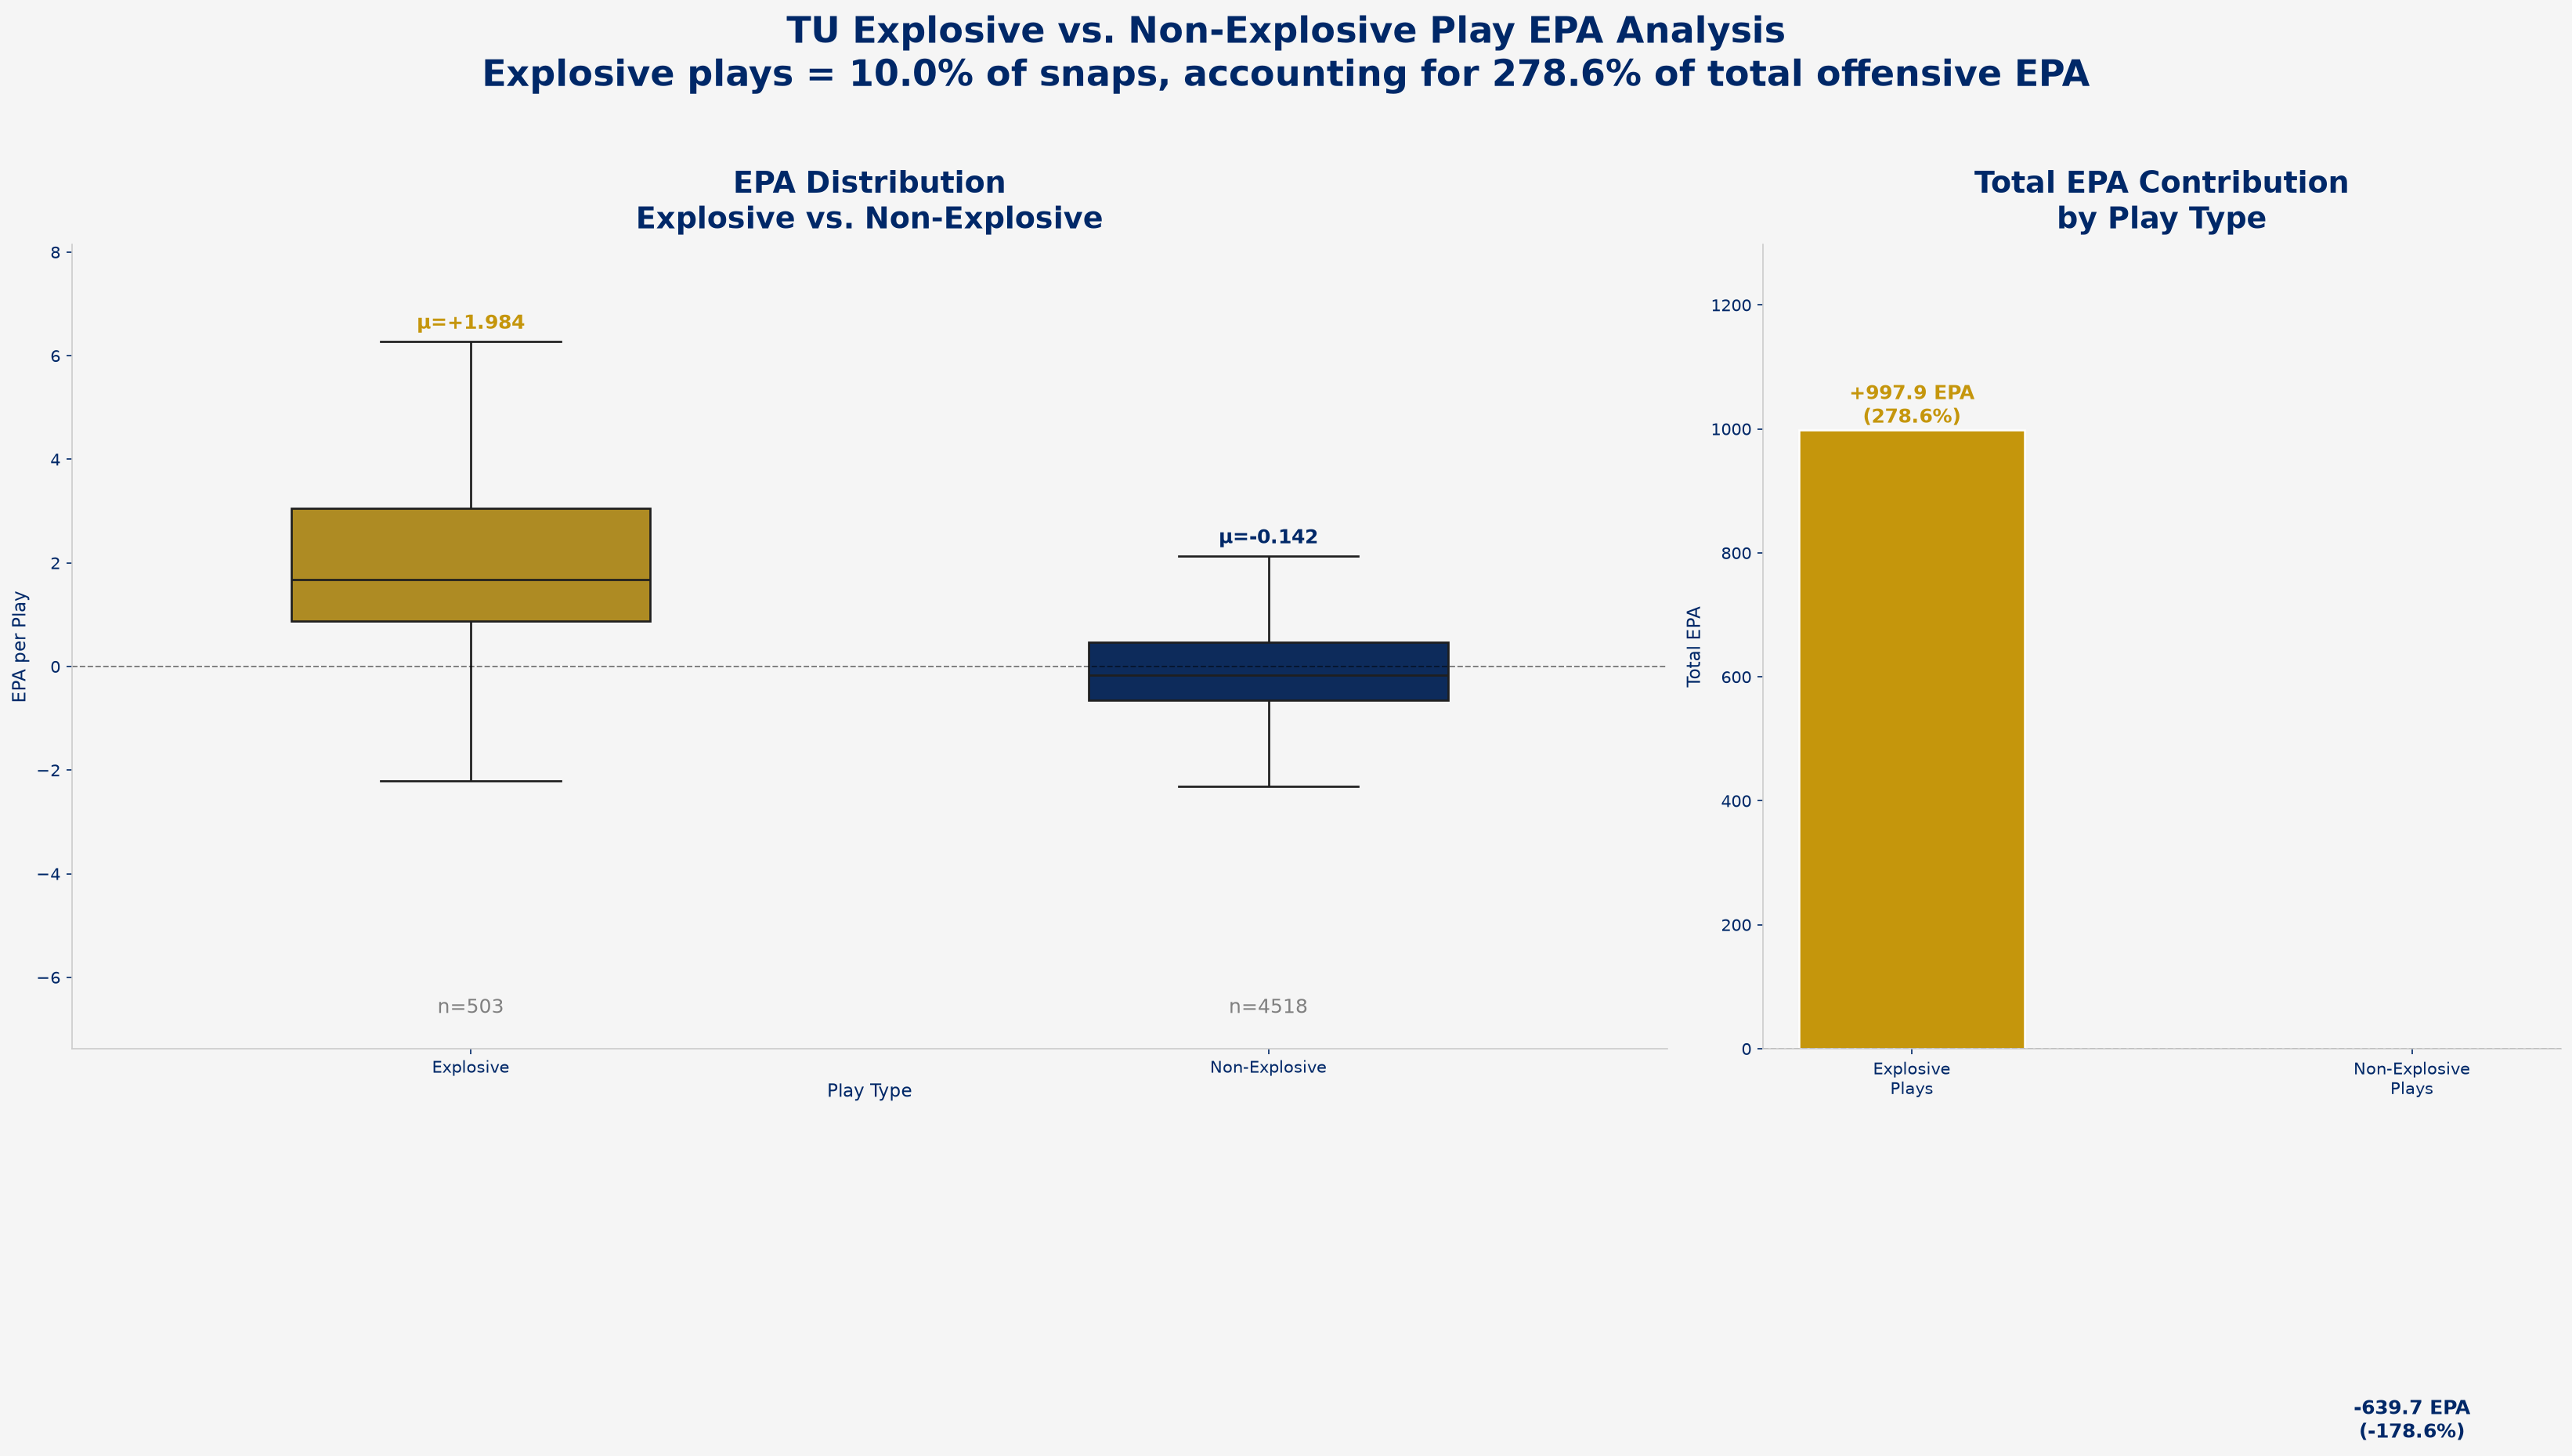

In [18]:

off_df = tu_df[
    (tu_df['odk'] == 'o') & (tu_df['epa'].notna()) &
    (tu_df['gn_ls'].notna()) & (tu_df['play_type'].isin(['run','pass']))
].copy()

off_df['explosive'] = (
    ((off_df['play_type'] == 'run')  & (off_df['gn_ls'] >= 12)) |
    ((off_df['play_type'] == 'pass') & (off_df['gn_ls'] >= 21))
)
off_df['explosive_label'] = off_df['explosive'].map({True:'Explosive', False:'Non-Explosive'})

total_epa        = off_df['epa'].sum()
explosive_epa    = off_df[off_df['explosive']]['epa'].sum()
explosive_pct    = explosive_epa / total_epa * 100 if total_epa != 0 else 0
explosive_play_pct = off_df['explosive'].mean() * 100

order   = ['Explosive', 'Non-Explosive']
palette = {'Explosive': TU_GOLD, 'Non-Explosive': TU_BLUE}

fig, axes = plt.subplots(1, 2, figsize=(22, 14), gridspec_kw={'width_ratios': [2, 1]})
fig.patch.set_facecolor(LIGHT_GRAY)

ax1 = axes[0]
ax1.set_facecolor(LIGHT_GRAY)
sns.boxplot(data=off_df, x='explosive_label', y='epa', order=order,
            palette=palette, width=0.45, linewidth=1.3,
            flierprops=dict(marker='o', markersize=3, alpha=0.3,
                            linestyle='none', markeredgewidth=0), ax=ax1)

for i, label in enumerate(order):
    subset      = off_df[off_df['explosive_label'] == label]['epa']
    Q3          = subset.quantile(0.75)
    whisker_top = subset[subset <= Q3 + 1.5*(Q3-subset.quantile(0.25))].max()
    ax1.text(i, whisker_top + 0.15, f'μ={subset.mean():+.3f}',
             ha='center', va='bottom', fontsize=12, fontweight='bold',
             color=TU_GOLD if label == 'Explosive' else TU_BLUE)
    ax1.text(i, ax1.get_ylim()[0]+0.1, f'n={len(subset)}',
             ha='center', va='bottom', fontsize=12, color='gray')

ax1.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.5)
ax1.set_title('EPA Distribution\nExplosive vs. Non-Explosive',
              fontsize=18, fontweight='bold', color=TU_BLUE, pad=10)
ax1.set_xlabel('Play Type', fontsize=11, color=TU_BLUE)
ax1.set_ylabel('EPA per Play', fontsize=11, color=TU_BLUE)
ax1.set_ylim(bottom=ax1.get_ylim()[0]-0.5, top=ax1.get_ylim()[1]+1.2)
ax1.tick_params(colors=TU_BLUE)
ax1.spines[['top','right']].set_visible(False)
ax1.spines[['left','bottom']].set_color('#CCCCCC')

ax2 = axes[1]
ax2.set_facecolor(LIGHT_GRAY)
contrib_vals   = [explosive_epa, total_epa - explosive_epa]
contrib_colors = [TU_GOLD, TU_BLUE]
bars = ax2.bar(['Explosive\nPlays', 'Non-Explosive\nPlays'],
               contrib_vals, color=contrib_colors,
               edgecolor='white', linewidth=1.2, width=0.45)
for bar, val in zip(bars, contrib_vals):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1.5,
             f'{val:+.1f} EPA\n({val/total_epa*100:.1f}%)',
             ha='center', va='bottom', fontsize=12, fontweight='bold',
             color=TU_GOLD if val == explosive_epa else TU_BLUE)

ax2.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.5)
ax2.set_title('Total EPA Contribution\nby Play Type',
              fontsize=18, fontweight='bold', color=TU_BLUE, pad=10)
ax2.set_ylabel('Total EPA', fontsize=11, color=TU_BLUE)
ax2.set_ylim(bottom=0, top=max(contrib_vals)*1.3)
ax2.tick_params(colors=TU_BLUE)
ax2.spines[['top','right']].set_visible(False)
ax2.spines[['left','bottom']].set_color('#CCCCCC')

fig.suptitle(
    f'TU Explosive vs. Non-Explosive Play EPA Analysis\n'
    f'Explosive plays = {explosive_play_pct:.1f}% of snaps, '
    f'accounting for {explosive_pct:.1f}% of total offensive EPA',
    fontsize=22, fontweight='bold', color=TU_BLUE, y=1.02
)
plt.tight_layout()
plt.show()



## 13b · Explosive Plays by Field Position
> **So what?** If our explosive rate drops near zero past the 40-yard line, defenses are loading up. Motions and tempo changes can disrupt that.


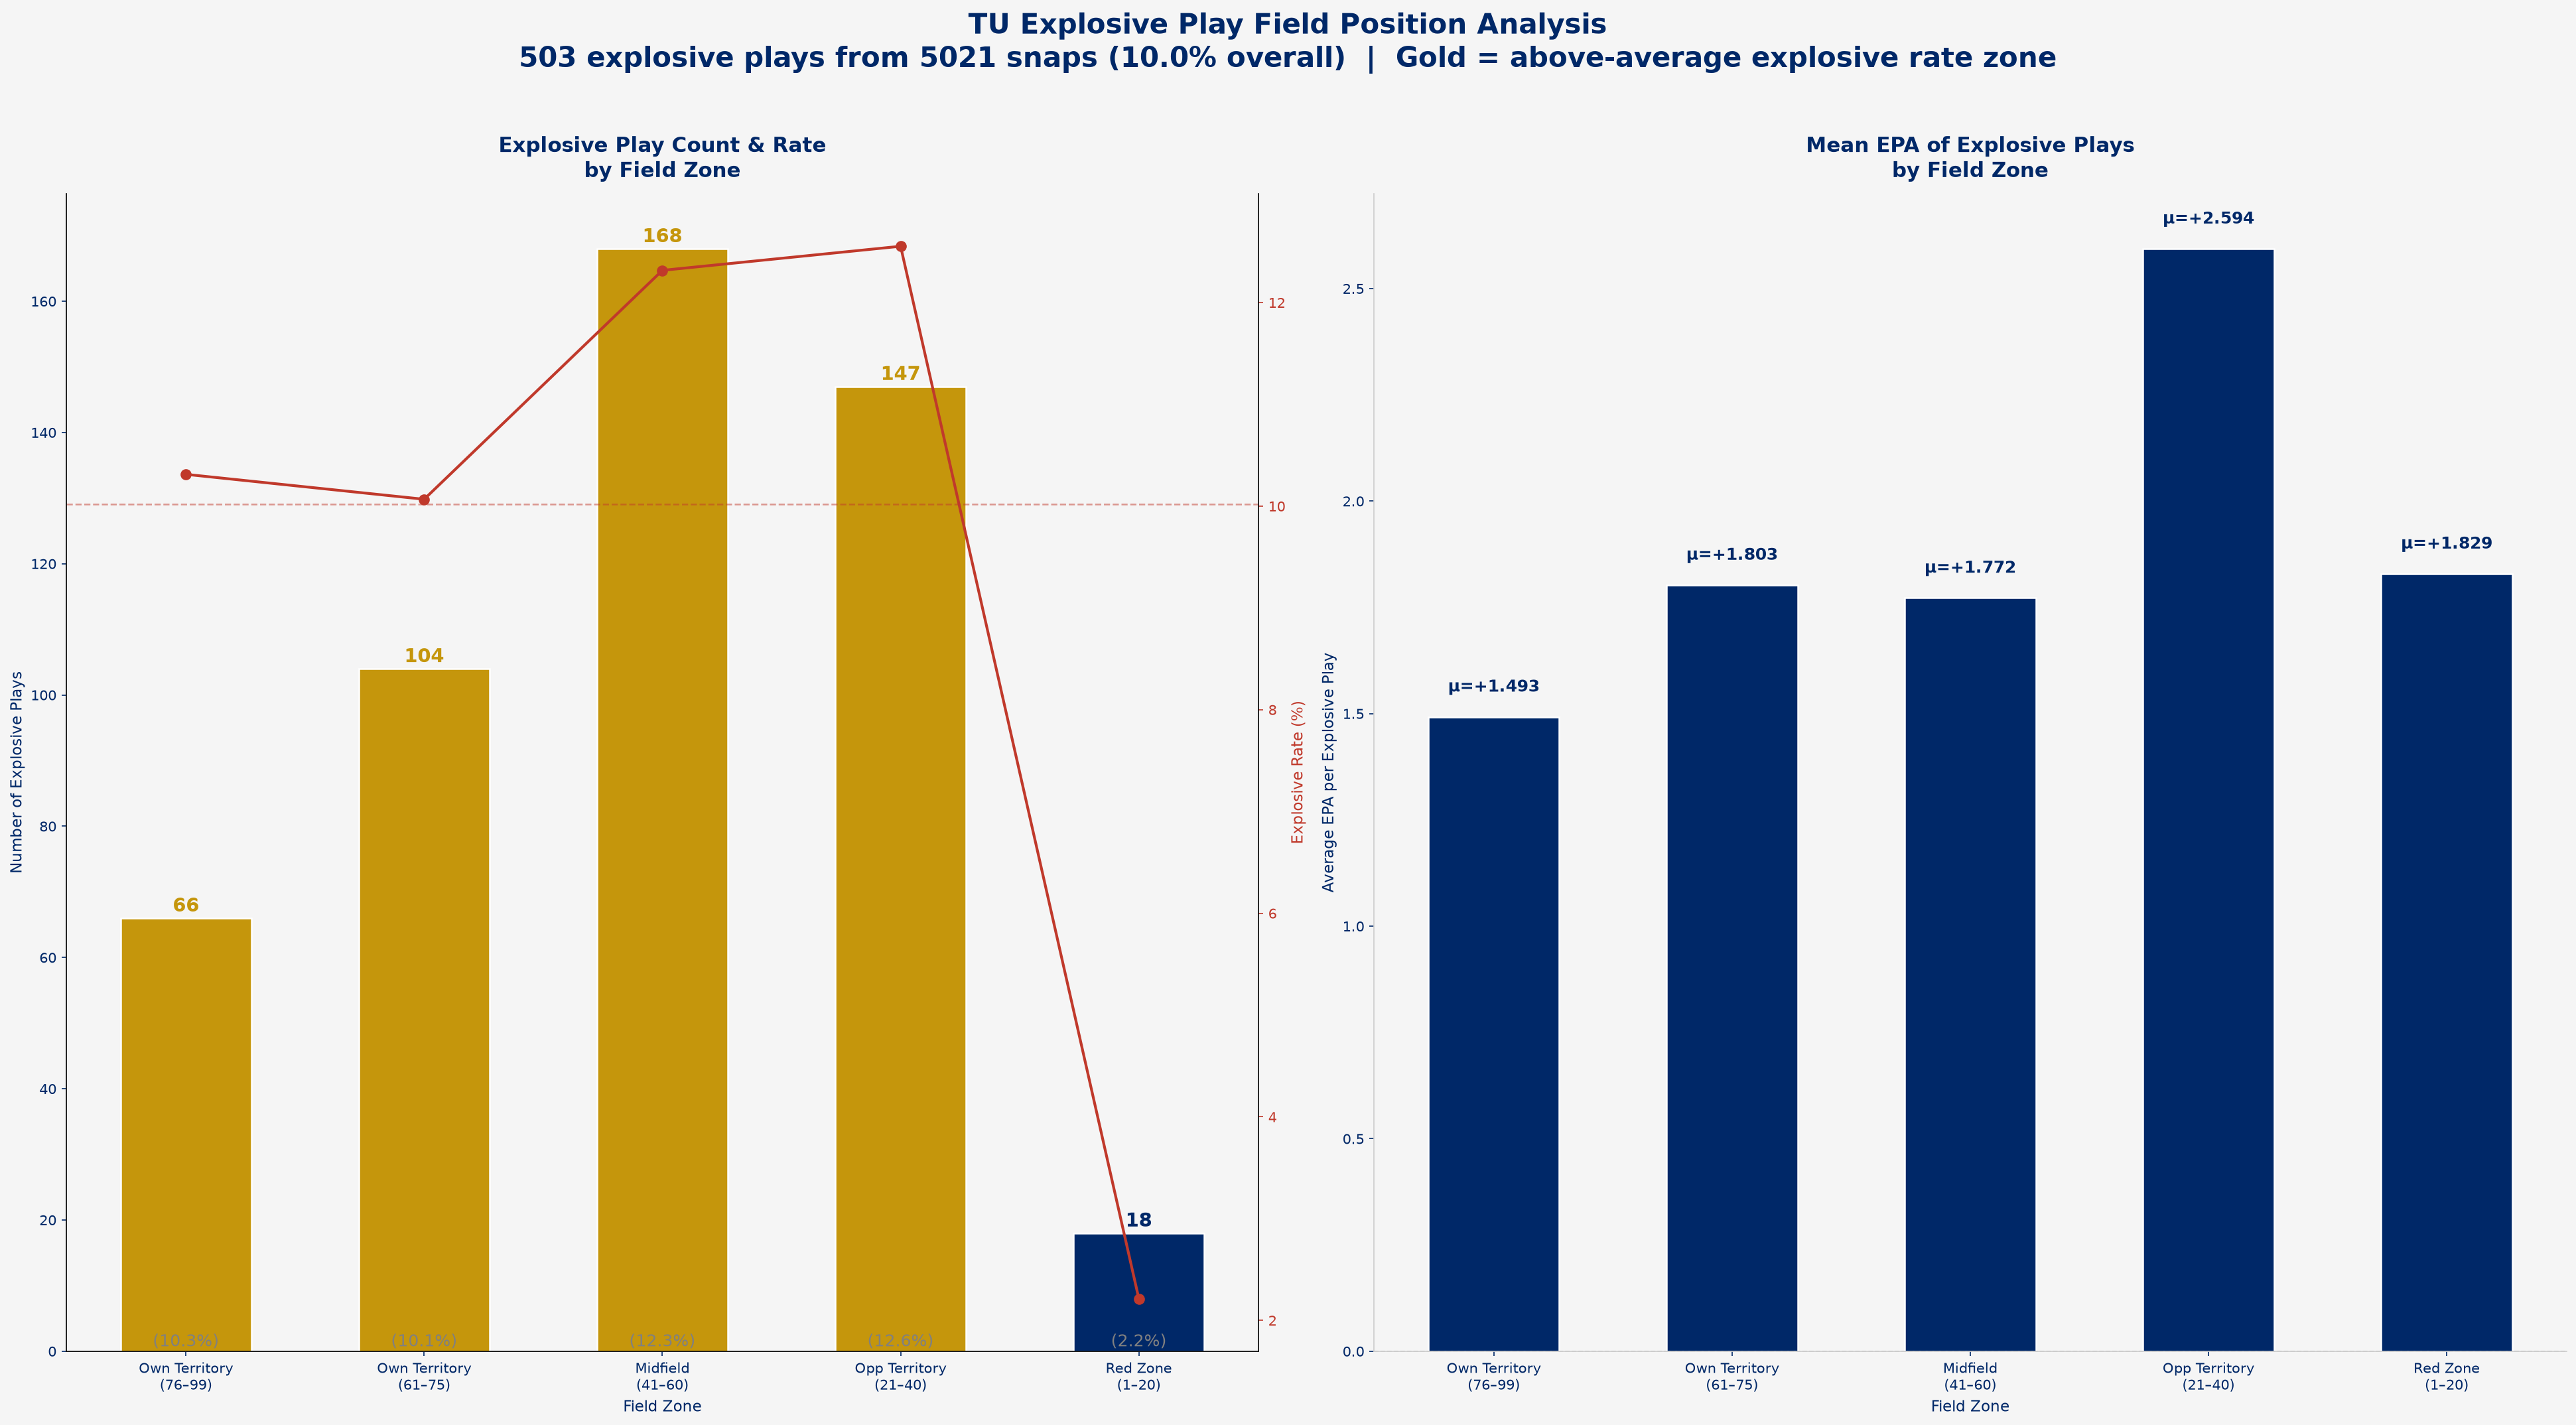

In [19]:

exp_df = tu_df[
    (tu_df['odk'] == 'o') & (tu_df['play_type'].isin(['run','pass'])) &
    (tu_df['gn_ls'].notna()) & (tu_df['yards_to_go'].notna()) & (tu_df['epa'].notna())
].copy()

exp_df['explosive'] = (
    ((exp_df['play_type'] == 'run')  & (exp_df['gn_ls'] >= 12)) |
    ((exp_df['play_type'] == 'pass') & (exp_df['gn_ls'] >= 21))
)

bins   = [0, 20, 40, 60, 75, 99]
labels = ['Red Zone\n(1–20)', 'Opp Territory\n(21–40)',
          'Midfield\n(41–60)', 'Own Territory\n(61–75)', 'Own Territory\n(76–99)']
exp_df['field_zone'] = pd.cut(exp_df['yards_to_go'], bins=bins,
                               labels=labels, include_lowest=True)

zone_agg = (
    exp_df.groupby('field_zone', observed=True)
    .agg(
        total_plays=('explosive','count'), exp_count=('explosive','sum'),
        exp_rate=('explosive','mean'),
        exp_epa_mean=('epa', lambda x: x[exp_df.loc[x.index,'explosive']].mean()),
    )
    .reset_index()
).iloc[::-1].reset_index(drop=True)
zone_agg['exp_rate_pct'] = zone_agg['exp_rate'] * 100
overall_exp_rate = exp_df['explosive'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(26, 14))
fig.patch.set_facecolor(LIGHT_GRAY)

ax1      = axes[0]
ax1_twin = ax1.twinx()
ax1.set_facecolor(LIGHT_GRAY)

bar_colors = [TU_GOLD if r >= overall_exp_rate else TU_BLUE
              for r in zone_agg['exp_rate_pct']]
bars = ax1.bar(zone_agg['field_zone'], zone_agg['exp_count'],
               color=bar_colors, edgecolor='white', linewidth=1.2, width=0.55, zorder=2)

for bar, row in zip(bars, zone_agg.itertuples()):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             f'{int(row.exp_count)}', ha='center', va='bottom', fontsize=14,
             fontweight='bold',
             color=TU_GOLD if row.exp_rate_pct >= overall_exp_rate else TU_BLUE)
    ax1.text(bar.get_x()+bar.get_width()/2, 0.15,
             f'({row.exp_rate_pct:.1f}%)', ha='center', va='bottom',
             fontsize=12, color='gray')

ax1_twin.plot(zone_agg['field_zone'], zone_agg['exp_rate_pct'],
              color=RED, linewidth=2, marker='o', markersize=7, zorder=3)
ax1_twin.axhline(overall_exp_rate, color=RED, linewidth=1.2, linestyle='--', alpha=0.5)
ax1_twin.set_ylabel('Explosive Rate (%)', fontsize=11, color=RED)
ax1_twin.tick_params(axis='y', colors=RED)
ax1_twin.spines[['top']].set_visible(False)
ax1.set_title('Explosive Play Count & Rate\nby Field Zone',
              fontsize=15, fontweight='bold', color=TU_BLUE, pad=12)
ax1.set_xlabel('Field Zone', fontsize=11, color=TU_BLUE)
ax1.set_ylabel('Number of Explosive Plays', fontsize=11, color=TU_BLUE)
ax1.tick_params(axis='x', colors=TU_BLUE)
ax1.tick_params(axis='y', colors=TU_BLUE)
ax1.spines[['top','right']].set_visible(False)
ax1.spines[['left','bottom']].set_color('#CCCCCC')

ax2 = axes[1]
ax2.set_facecolor(LIGHT_GRAY)
bars2 = ax2.bar(zone_agg['field_zone'], zone_agg['exp_epa_mean'],
                color=[TU_BLUE if v >= 0 else RED for v in zone_agg['exp_epa_mean']],
                edgecolor='white', linewidth=1.2, width=0.55)
ax2.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.5)
for bar, row in zip(bars2, zone_agg.itertuples()):
    if np.isnan(row.exp_epa_mean): continue
    ax2.text(bar.get_x()+bar.get_width()/2,
             row.exp_epa_mean + 0.05 if row.exp_epa_mean >= 0 else row.exp_epa_mean - 0.05,
             f'μ={row.exp_epa_mean:+.3f}', ha='center',
             va='bottom' if row.exp_epa_mean >= 0 else 'top',
             fontsize=12, fontweight='bold',
             color=TU_BLUE if row.exp_epa_mean >= 0 else RED)
ax2.set_title('Mean EPA of Explosive Plays\nby Field Zone',
              fontsize=15, fontweight='bold', color=TU_BLUE, pad=12)
ax2.set_xlabel('Field Zone', fontsize=11, color=TU_BLUE)
ax2.set_ylabel('Average EPA per Explosive Play', fontsize=11, color=TU_BLUE)
ax2.tick_params(axis='x', colors=TU_BLUE)
ax2.tick_params(axis='y', colors=TU_BLUE)
ax2.spines[['top','right']].set_visible(False)
ax2.spines[['left','bottom']].set_color('#CCCCCC')

total_exp   = int(exp_df['explosive'].sum())
total_plays = len(exp_df)
fig.suptitle(
    f'TU Explosive Play Field Position Analysis\n'
    f'{total_exp} explosive plays from {total_plays} snaps ({overall_exp_rate:.1f}% overall)  |  '
    f'Gold = above-average explosive rate zone',
    fontsize=20, fontweight='bold', color=TU_BLUE, y=1.02
)
plt.tight_layout()
plt.show()



## 14a · Cumulative EPA by Drive Series
> **So what?** Sharp upward turns = explosive stretches. Flat sections = stalled drives. This is the season's offensive story in one line.


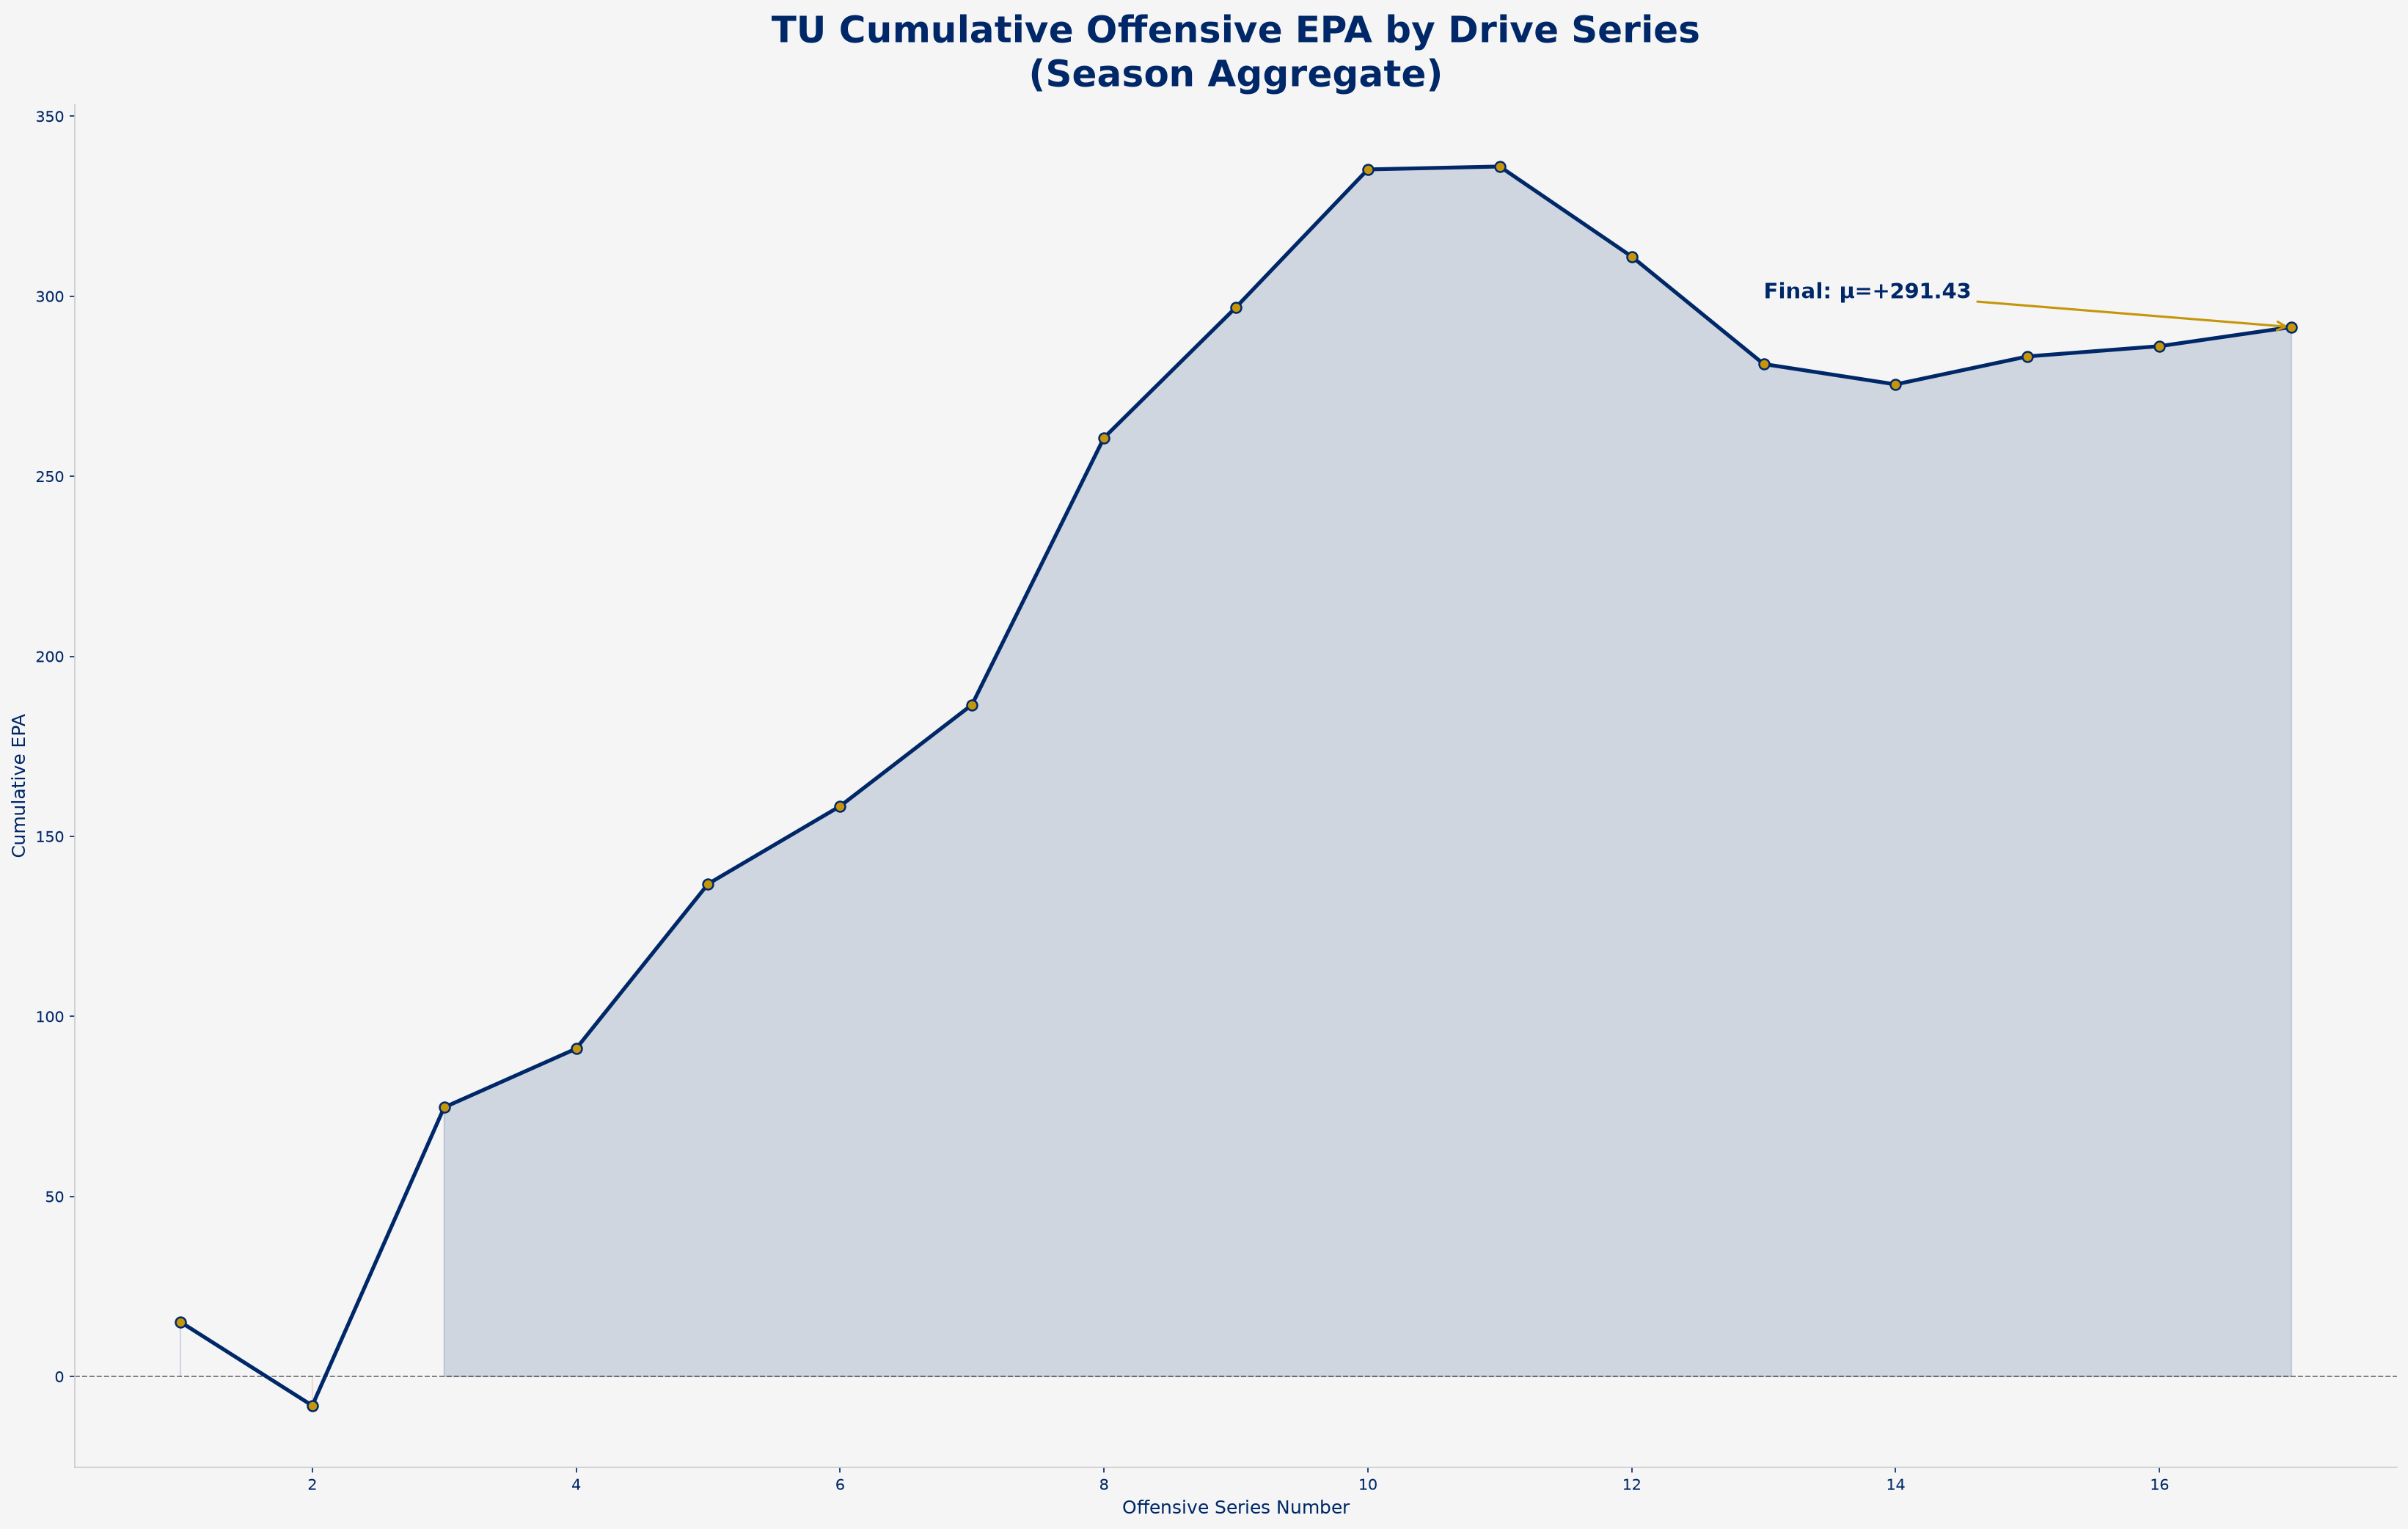

In [20]:

off_df = tu_df[(tu_df['odk'] == 'o') & (tu_df['epa'].notna())].copy()

series_df = (
    off_df.groupby('off_series')['epa']
    .agg(['sum','mean','count']).reset_index()
    .rename(columns={'sum':'total_epa','mean':'avg_epa','count':'n_plays'})
)
series_df = series_df[series_df['n_plays'] >= 5]
series_df['cumulative_epa'] = series_df['total_epa'].cumsum()

fig, ax = plt.subplots(figsize=(22, 14))
fig.patch.set_facecolor(LIGHT_GRAY)
ax.set_facecolor(LIGHT_GRAY)

ax.fill_between(series_df['off_series'], series_df['cumulative_epa'], 0,
                where=series_df['cumulative_epa'] >= 0, alpha=0.15, color=TU_BLUE)
ax.fill_between(series_df['off_series'], series_df['cumulative_epa'], 0,
                where=series_df['cumulative_epa'] < 0, alpha=0.15, color=RED)
ax.plot(series_df['off_series'], series_df['cumulative_epa'],
        color=TU_BLUE, linewidth=2.5, zorder=3)
ax.scatter(series_df['off_series'], series_df['cumulative_epa'],
           color=TU_GOLD, edgecolors=TU_BLUE, linewidth=1.2, s=45, zorder=4)
ax.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.5)

final_val = series_df['cumulative_epa'].iloc[-1]
final_ser = series_df['off_series'].iloc[-1]
ax.annotate(f'Final: μ={final_val:+.2f}',
            xy=(final_ser, final_val),
            xytext=(final_ser - 4, final_val + (8 if final_val >= 0 else -8)),
            fontsize=14, fontweight='bold',
            color=TU_BLUE if final_val >= 0 else RED,
            arrowprops=dict(arrowstyle='->', color=TU_GOLD, lw=1.5))

ax.set_title('TU Cumulative Offensive EPA by Drive Series\n(Season Aggregate)',
             fontsize=24, fontweight='bold', color=TU_BLUE, pad=12)
ax.set_xlabel('Offensive Series Number', fontsize=12, color=TU_BLUE)
ax.set_ylabel('Cumulative EPA', fontsize=12, color=TU_BLUE)
ax.tick_params(colors=TU_BLUE)
ax.spines[['top','right']].set_visible(False)
ax.spines[['left','bottom']].set_color('#CCCCCC')
plt.tight_layout()
plt.show()



## 14b · Cumulative EPA Per Game — Simple (Interactive)
> **So what?** Click any game in the legend to show its drive-by-drive EPA trajectory. Steady climb = sustained efficiency. One spike then flat = explosion-dependent.


In [21]:

# ── Explosive flags ───────────────────────────────────────────────────────────
off_df = tu_df[(tu_df['odk'] == 'o') & (tu_df['epa'].notna())].copy()

off_df['run_explosive']  = (
    (off_df['play_type'] == 'run') &
    (off_df['gn_ls'].notna()) &
    (off_df['gn_ls'] >= 12)
).astype(int)

off_df['pass_explosive'] = (
    (off_df['play_type'] == 'pass') &
    (off_df['gn_ls'].notna()) &
    (off_df['gn_ls'] >= 21)
).astype(int)

# ── Drive outcome classification ──────────────────────────────────────────────
all_plays_s = tu_df.copy()
all_plays_s['play'] = pd.to_numeric(all_plays_s['play'], errors='coerce')
all_plays_s = all_plays_s.sort_values(['game_id', 'play']).reset_index(drop=True)

def classify_outcome_s(group):
    last = group.iloc[-1]
    nxt  = last['next_odk'] if pd.notna(last['next_odk']) else ''
    tod  = last['turnover_on_downs'] if 'turnover_on_downs' in last.index else 0

    if last['score_event'] == 7:
        return 'Touchdown'

    last_idx = all_plays_s[
        (all_plays_s['game_id'] == last['game_id']) &
        (all_plays_s['play'] == last['play'])
    ].index
    if len(last_idx) > 0:
        next_idx = last_idx[0] + 1
        if next_idx < len(all_plays_s):
            next_row = all_plays_s.iloc[next_idx]
            if next_row['game_id'] == last['game_id'] and next_row['score_event'] == 3:
                return 'Field Goal'

    if   tod == 1:   return 'Turnover on Downs'
    elif nxt == 'd': return 'Turnover'
    elif nxt == 'k': return 'Punt'
    else:            return 'Other'

off_plays_s = off_df.copy()
off_plays_s['play'] = pd.to_numeric(off_plays_s['play'], errors='coerce')
off_plays_s = off_plays_s.sort_values(['game_id', 'play'])

series_outcomes_s = (
    off_plays_s
    .groupby(['game_id', 'off_series'], sort=False)
    .apply(classify_outcome_s)
    .reset_index()
    .rename(columns={0: 'outcome'})
)

# ── Aggregate EPA + explosives by game and series ─────────────────────────────
game_series_simple = (
    off_df.groupby(['game_id','opp_name','game_date','team_pts','opp_pts','win','off_series'])
    .agg(
        total_epa      = ('epa',            'sum'),
        n_plays        = ('epa',            'count'),
        run_explosive  = ('run_explosive',   'sum'),
        pass_explosive = ('pass_explosive',  'sum'),
    )
    .reset_index()
)

game_series_simple = game_series_simple[game_series_simple['n_plays'] >= 1]

game_series_simple = game_series_simple.merge(series_outcomes_s, on=['game_id', 'off_series'], how='left')
game_series_simple['outcome'] = game_series_simple['outcome'].fillna('Other')

game_series_simple['cumulative_epa'] = game_series_simple.groupby('game_id')['total_epa'].cumsum()
game_series_simple['game_date_parsed'] = pd.to_datetime(game_series_simple['game_date'], format='%m/%d/%Y')
game_series_simple['year'] = game_series_simple['game_date_parsed'].dt.year

def build_label_simple(row):
    result = 'W' if row['win'] == 1 else 'L'
    return f"{row['game_date']} vs. {row['opp_name']} ({result} {int(row['team_pts'])}-{int(row['opp_pts'])})"
game_series_simple['game_label'] = game_series_simple.apply(build_label_simple, axis=1)

game_meta_simple = (
    game_series_simple[['game_id','game_label','game_date_parsed','year']]
    .drop_duplicates('game_id')
    .sort_values('game_date_parsed', ascending=False)
)

colors_s = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd',
            '#8c564b','#e377c2','#7f7f7f','#bcbd22','#17becf',
            '#aec7e8','#ffbb78','#98df8a','#ff9896','#c5b0d5']

fig_s = go.Figure()
current_year_s = None
game_count_s   = 0
game_indices_s = []
trace_idx_s    = 0

for _, meta in game_meta_simple.iterrows():
    game_id = meta['game_id']
    year    = meta['year']
    label   = meta['game_label']
    group   = game_series_simple[game_series_simple['game_id'] == game_id]
    color   = colors_s[game_count_s % len(colors_s)]
    game_count_s += 1

    if year != current_year_s:
        current_year_s = year
        fig_s.add_trace(go.Scatter(
            x=[None], y=[None], mode='markers',
            marker=dict(size=0, color='rgba(0,0,0,0)'),
            name=f'<b>── {year} ──</b>', showlegend=True,
            hoverinfo='skip', visible=True, legendgroup=f'yr_{year}',
        ))
        trace_idx_s += 1

    hover_text = [
        f"<b>{label}</b><br>"
        f"Series: {int(r.off_series)}<br>"
        f"Series EPA: {r.total_epa:+.3f}<br>"
        f"Cumulative EPA: {r.cumulative_epa:+.3f}<br>"
        f"Plays in series: {int(r.n_plays)}<br>"
        f"Run explosives: {int(r.run_explosive)}  |  Pass explosives: {int(r.pass_explosive)}<br>"
        f"Outcome: {r.outcome}"
        for r in group.itertuples()
    ]

    fig_s.add_trace(go.Scatter(
        x=group['off_series'], y=group['cumulative_epa'],
        mode='lines+markers', name=label,
        legendgroup=game_id,
        line=dict(color=color, width=2.5),
        marker=dict(size=7, color=color, line=dict(color='white', width=1)),
        hovertemplate='%{text}<extra></extra>', text=hover_text,
        visible='legendonly'
    ))
    game_indices_s.append(trace_idx_s)
    trace_idx_s += 1

fig_s.add_hline(y=0, line_dash='dash', line_color='black', opacity=0.4, line_width=1.5)
fig_s.update_layout(
    title=dict(
        text='TU Cumulative Offensive EPA by Drive Series<br>'
             '<sup>Click a game in the legend to show it — click again to remove</sup>',
        font=dict(size=15, color=TU_BLUE), x=0.5, xanchor='center'),
    xaxis=dict(title='Offensive Series Number', titlefont=dict(color=TU_BLUE),
               tickfont=dict(color=TU_BLUE), gridcolor='#DDDDDD', zeroline=False),
    yaxis=dict(title='Cumulative EPA', titlefont=dict(color=TU_BLUE),
               tickfont=dict(color=TU_BLUE), gridcolor='#DDDDDD', zeroline=False),
    legend=dict(title=dict(text='Game', font=dict(color=TU_BLUE, size=10)),
                bgcolor='rgba(255,255,255,0.85)', bordercolor='#CCCCCC',
                borderwidth=1, font=dict(size=9), tracegroupgap=2),
    updatemenus=[dict(
        type='buttons', showactive=False,
        x=1.0, xanchor='right', y=1.05, yanchor='top',
        buttons=[
            dict(label='Show All', method='restyle',
                 args=[{'visible': True}, game_indices_s]),
            dict(label='Hide All', method='restyle',
                 args=[{'visible': 'legendonly'}, game_indices_s])
        ],
        bgcolor='white', bordercolor='#CCCCCC', font=dict(color=TU_BLUE, size=9),
        pad=dict(t=2,b=2)
    )],
    plot_bgcolor=LIGHT_GRAY, paper_bgcolor=LIGHT_GRAY, hovermode='closest',
    height=700, margin=dict(t=60, b=30, l=60, r=20),
)
fig_s.show()


<Plotly Figure>


## 14c · Cumulative EPA Per Game — Color by Year / W/L (Interactive)
> **So what?** Toggle color mode to compare seasons or see win/loss patterns. Steady climb = sustained efficiency. One spike then flat = explosion-dependent.


In [22]:

off_df = tu_df[(tu_df['odk'] == 'o') & (tu_df['epa'].notna())].copy()

game_series_df = (
    off_df.groupby(['game_id','opp_name','game_date','team_pts','opp_pts','win','off_series'])['epa']
    .agg(['sum','count']).reset_index()
    .rename(columns={'sum':'total_epa','count':'n_plays'})
)
game_series_df = game_series_df[game_series_df['n_plays'] >= 1]
game_series_df['cumulative_epa'] = game_series_df.groupby('game_id')['total_epa'].cumsum()
game_series_df['game_date_parsed'] = pd.to_datetime(game_series_df['game_date'], format='%m/%d/%Y')
game_series_df['year'] = game_series_df['game_date_parsed'].dt.year

def build_label(row):
    result = 'W' if row['win'] == 1 else 'L'
    return f"{row['game_date']} vs. {row['opp_name']} ({result} {int(row['team_pts'])}-{int(row['opp_pts'])})"

game_series_df['game_label'] = game_series_df.apply(build_label, axis=1)

game_meta = (
    game_series_df[['game_id','game_label','game_date_parsed','year','win']]
    .drop_duplicates('game_id').sort_values('game_date_parsed', ascending=False)
)
all_years = sorted(game_meta['year'].unique())

YEAR_PALETTE = ['#002868','#C5960C','#1D9E75','#D85A30','#9467bd',
                '#378ADD','#BA7517','#e377c2','#17becf','#8c564b']
year_color_map = {yr: YEAR_PALETTE[i % len(YEAR_PALETTE)] for i, yr in enumerate(all_years)}

fig = go.Figure()
current_year = None
game_indices = []
year_traces  = []
wl_traces    = []
trace_index  = 0

# Set A: colored by year
for _, meta in game_meta.iterrows():
    game_id = meta['game_id']
    year    = meta['year']
    label   = meta['game_label']
    group   = game_series_df[game_series_df['game_id'] == game_id]
    color   = year_color_map[year]

    if year != current_year:
        current_year = year
        fig.add_trace(go.Scatter(
            x=[None], y=[None], mode='markers',
            marker=dict(size=0, color='rgba(0,0,0,0)'),
            name=f'<b>── {year} ──</b>', showlegend=True,
            hoverinfo='skip', visible=True, legendgroup=f'year_header_{year}',
        ))
        trace_index += 1

    hover = [
        f"<b>{label}</b><br>Series: {int(r.off_series)}<br>"
        f"Series EPA: {r.total_epa:+.3f}<br>Cumulative EPA: {r.cumulative_epa:+.3f}"
        for r in group.itertuples()
    ]
    fig.add_trace(go.Scatter(
        x=group['off_series'], y=group['cumulative_epa'],
        mode='lines+markers', name=label, legendgroup=game_id,
        line=dict(color=color, width=2.5),
        marker=dict(size=7, color=color, line=dict(color='white', width=1)),
        hovertemplate='%{text}<extra></extra>', text=hover, visible='legendonly',
    ))
    year_traces.append(trace_index)
    game_indices.append(trace_index)
    trace_index += 1

# Set B: colored by W/L
current_year = None
for _, meta in game_meta.iterrows():
    game_id = meta['game_id']
    year    = meta['year']
    label   = meta['game_label']
    group   = game_series_df[game_series_df['game_id'] == game_id]
    color   = WIN_COLOR if meta['win'] == 1 else LOSS_COLOR

    if year != current_year:
        current_year = year
        fig.add_trace(go.Scatter(
            x=[None], y=[None], mode='markers',
            marker=dict(size=0, color='rgba(0,0,0,0)'),
            name=f'<b>── {year} ──</b>', showlegend=True,
            hoverinfo='skip', visible=False, legendgroup=f'wl_header_{year}',
        ))
        trace_index += 1

    hover = [
        f"<b>{label}</b><br>Series: {int(r.off_series)}<br>"
        f"Series EPA: {r.total_epa:+.3f}<br>Cumulative EPA: {r.cumulative_epa:+.3f}"
        for r in group.itertuples()
    ]
    fig.add_trace(go.Scatter(
        x=group['off_series'], y=group['cumulative_epa'],
        mode='lines+markers', name=label, legendgroup=f'wl_{game_id}',
        showlegend=True, line=dict(color=color, width=2.5),
        marker=dict(size=7, color=color, line=dict(color='white', width=1)),
        hovertemplate='%{text}<extra></extra>', text=hover, visible=False,
    ))
    wl_traces.append(trace_index)
    game_indices.append(trace_index)
    trace_index += 1

total_traces = trace_index

def make_visibility(mode):
    vis = []
    for i in range(total_traces):
        if mode == 'year':
            vis.append(False if i in wl_traces else
                       ('legendonly' if i in year_traces else True))
        else:
            vis.append(False if i in year_traces else
                       ('legendonly' if i in wl_traces else True))
    return vis

fig.add_hline(y=0, line_dash='dash', line_color='black', opacity=0.4, line_width=1.5)
fig.update_layout(
    title=dict(
        text='TU Cumulative Offensive EPA by Drive Series<br>'
             '<sup>Click a game to add / remove  ·  Toggle color mode below</sup>',
        font=dict(size=18, color=TU_BLUE), x=0.5, xanchor='center'),
    xaxis=dict(title='Offensive Series Number', titlefont=dict(color=TU_BLUE),
               tickfont=dict(color=TU_BLUE), gridcolor='#DDDDDD'),
    yaxis=dict(title='Cumulative EPA', titlefont=dict(color=TU_BLUE),
               tickfont=dict(color=TU_BLUE), gridcolor='#DDDDDD'),
    legend=dict(title=dict(text='Game', font=dict(color=TU_BLUE, size=11)),
                bgcolor='rgba(255,255,255,0.85)', bordercolor='#CCCCCC',
                borderwidth=1, font=dict(size=10), tracegroupgap=2),
    updatemenus=[
        dict(type='buttons', direction='right', showactive=True,
             x=0.5, xanchor='center', y=-0.08, yanchor='top',
             bgcolor='white', bordercolor='#CCCCCC', font=dict(color=TU_BLUE, size=10),
             buttons=[
                 dict(label='Color by Year', method='restyle',
                      args=[{'visible': make_visibility('year')}]),
                 dict(label='Color by W/L', method='restyle',
                      args=[{'visible': make_visibility('wl')}]),
             ]),
        dict(type='buttons', showactive=False, x=1.0, xanchor='right',
             y=-0.08, yanchor='top', bgcolor='white', bordercolor='#CCCCCC',
             font=dict(color=TU_BLUE, size=10),
             buttons=[
                 dict(label='Show All', method='restyle',
                      args=[{'visible': True}, game_indices]),
                 dict(label='Hide All', method='restyle',
                      args=[{'visible': 'legendonly'}, game_indices]),
             ]),
    ],
    plot_bgcolor=LIGHT_GRAY, paper_bgcolor=LIGHT_GRAY,
    height=780, margin=dict(t=120, b=40, l=70, r=20),
)
fig.show()


<Plotly Figure>


## 14c · Drive Process (Interactive)
> **So what?** Each dot is a drive. Touchdowns cluster at high EPA. Turnovers and punts cluster at negative EPA. Use the dropdown to filter by season or game.


In [23]:

all_plays = tu_df.copy()
all_plays['play'] = pd.to_numeric(all_plays['play'], errors='coerce')
all_plays = all_plays.sort_values(['game_id','play']).reset_index(drop=True)

off_plays = all_plays[(all_plays['odk'] == 'o') & (all_plays['epa'].notna())].copy()
off_plays['year'] = pd.to_datetime(off_plays['game_date'], format='%m/%d/%Y').dt.year
off_plays['drive_key'] = (off_plays['game_id'].astype(str) + '_s' +
                          off_plays['off_series'].astype(str))

def classify_outcome(group):
    last  = group.iloc[-1]
    nxt   = last['next_odk'] if pd.notna(last['next_odk']) else ''
    tod   = last['turnover_on_downs'] if 'turnover_on_downs' in last.index else 0
    if last['score_event'] == 7:
        return 'Touchdown'
    last_idx = all_plays[
        (all_plays['game_id'] == last['game_id']) &
        (all_plays['play'] == last['play'])
    ].index
    if len(last_idx) > 0:
        next_idx = last_idx[0] + 1
        if next_idx < len(all_plays):
            nr = all_plays.iloc[next_idx]
            if nr['game_id'] == last['game_id'] and nr['score_event'] == 3:
                return 'Field Goal'
    if   tod == 1:   return 'Turnover on Downs'
    elif nxt == 'd': return 'Turnover'
    elif nxt == 'k': return 'Punt'
    else:            return 'Other'

records = []
for key, grp in off_plays.groupby('drive_key', sort=False):
    grp = grp.sort_values('play')
    outcome = classify_outcome(grp)
    records.append({
        'drive_key': key, 'outcome': outcome,
        'net_epa': round(grp['epa'].sum(), 3),
        'drive_pts': 7 if outcome=='Touchdown' else 3 if outcome=='Field Goal' else 0,
        'n_plays': len(grp), 'std_epa': round(grp['epa'].std() if len(grp)>1 else 0.0, 3),
        'epa_series': grp['epa'].tolist(),
        'game_id': grp['game_id'].iloc[0],
        'opp_name': grp['opp_name'].iloc[0] if 'opp_name' in grp.columns else '',
        'year': int(grp['year'].iloc[0]),
        'win': int(grp['win'].iloc[0]),
        'team_pts': int(grp['team_pts'].iloc[0]),
        'opp_pts': int(grp['opp_pts'].iloc[0]),
    })

drives_df = pd.DataFrame(records)
all_years = sorted(drives_df['year'].unique(), reverse=True)

OUTCOME_COLORS  = {
    'Touchdown':'#1D9E75', 'Field Goal':'#378ADD', 'Punt':'#888780',
    'Turnover':'#D85A30', 'Turnover on Downs':'#BA7517', 'Other':'#B4B2A9',
}
OUTCOME_SYMBOLS = {
    'Touchdown':'circle', 'Field Goal':'diamond', 'Punt':'square',
    'Turnover':'x', 'Turnover on Downs':'triangle-up', 'Other':'cross',
}
N_NORM = 24

def make_hover(row):
    result = 'W' if row['win'] else 'L'
    return (f"vs {row['opp_name']}  {row['team_pts']}-{row['opp_pts']} ({result})<br>"
            f"Drive {row['drive_key'].split('_s')[-1]}  |  "
            f"Net EPA: {row['net_epa']:+.2f}  |  Pts: {row['drive_pts']}  |  "
            f"Plays: {row['n_plays']}  |  StdDev: {row['std_epa']:.2f}")

scopes = [('All seasons', 'All games', drives_df)]
for yr in all_years:
    yr_df = drives_df[drives_df['year'] == yr]
    scopes.append((str(yr), 'All games', yr_df))
    for _, grow in yr_df.drop_duplicates('game_id').sort_values('game_id').iterrows():
        result = 'W' if grow['win'] else 'L'
        glabel = f"vs {grow['opp_name']}  ({grow['team_pts']}-{grow['opp_pts']} {result})"
        scopes.append((str(yr), glabel, yr_df[yr_df['game_id'] == grow['game_id']]))

fig = make_subplots(rows=2, cols=1, subplot_titles=(' ',' '),
                    vertical_spacing=0.13, row_heights=[0.46, 0.54])

rng    = np.random.default_rng(42)
x_norm = np.linspace(0, 1, N_NORM)
all_traces      = []
scope_trace_map = []
global_idx      = 0

for yr_lbl, gm_lbl, sub in scopes:
    scope_indices = []
    if sub.empty:
        scope_trace_map.append(scope_indices)
        continue

    scatter_added = set()
    for outcome in OUTCOME_COLORS:
        mask = sub['outcome'] == outcome
        if not mask.any(): continue
        grp    = sub[mask]
        jitter = rng.uniform(-0.18, 0.18, size=len(grp))
        labels = [make_hover(r) for _, r in grp.iterrows()]
        t = go.Scatter(
            x=grp['net_epa'], y=grp['drive_pts'] + jitter,
            mode='markers', name=outcome,
            marker=dict(color=OUTCOME_COLORS[outcome], symbol=OUTCOME_SYMBOLS[outcome],
                        size=9, opacity=0.82, line=dict(width=0.6, color='white')),
            text=labels, hovertemplate='%{text}<extra></extra>',
            legendgroup=outcome, showlegend=(outcome not in scatter_added), visible=False,
        )
        all_traces.append((t, 1, 1))
        scope_indices.append(global_idx)
        global_idx += 1
        scatter_added.add(outcome)

    outcome_traj = {o: [] for o in OUTCOME_COLORS}
    for _, row in sub.iterrows():
        epas = row['epa_series']
        if len(epas) < 2: continue
        cum   = np.cumsum(epas)
        x_raw = np.linspace(0, 1, len(cum))
        y_i   = np.interp(x_norm, x_raw, cum)
        outcome_traj[row['outcome']].append(y_i)
        t = go.Scatter(
            x=x_norm, y=np.round(y_i, 3), mode='lines',
            line=dict(color=OUTCOME_COLORS[row['outcome']], width=1),
            opacity=0.25, showlegend=False, hoverinfo='skip',
            legendgroup=row['outcome'], visible=False,
        )
        all_traces.append((t, 2, 1))
        scope_indices.append(global_idx)
        global_idx += 1

    for outcome, tlist in outcome_traj.items():
        if not tlist: continue
        avg = np.mean(tlist, axis=0)
        t = go.Scatter(
            x=x_norm, y=np.round(avg, 3), mode='lines', name=outcome,
            line=dict(color=OUTCOME_COLORS[outcome], width=3),
            showlegend=False, legendgroup=outcome,
            hovertemplate=f'{outcome} avg: %{{y:.2f}}<extra></extra>', visible=False,
        )
        all_traces.append((t, 2, 1))
        scope_indices.append(global_idx)
        global_idx += 1

    scope_trace_map.append(scope_indices)

for t, row, col in all_traces:
    fig.add_trace(t, row=row, col=col)

total_traces = global_idx
for idx in scope_trace_map[0]:
    fig.data[idx].visible = True

def scope_visibility(scope_i):
    vis = [False] * total_traces
    for idx in scope_trace_map[scope_i]:
        vis[idx] = True
    return vis

def subtitle(sub):
    n     = len(sub)
    avg   = sub['net_epa'].mean() if n else 0
    td_r  = (sub['outcome']=='Touchdown').mean()*100 if n else 0
    to_r  = sub['outcome'].isin(['Turnover','Turnover on Downs']).mean()*100 if n else 0
    return f"{n} drives  ·  Avg EPA {avg:+.2f}  ·  TD rate {td_r:.0f}%  ·  TO rate {to_r:.0f}%"

combined_buttons = [dict(
    label='— All Seasons —', method='update',
    args=[{'visible': scope_visibility(0)},
          {'title.text': f'<b>TU Offensive Drive EPA</b>   — All seasons<br>'
           f'<sup style="color:#888780">{subtitle(drives_df)}</sup>'}]
)]
for yr in all_years:
    yr_scope_i = next(i for i,(yl,gl,_) in enumerate(scopes) if yl==str(yr) and gl=='All games')
    yr_sub = scopes[yr_scope_i][2]
    combined_buttons.append(dict(
        label=f'── {yr} ──', method='update',
        args=[{'visible': scope_visibility(yr_scope_i)},
              {'title.text': f'<b>TU Offensive Drive EPA</b>   — {yr}<br>'
               f'<sup style="color:#888780">{subtitle(yr_sub)}</sup>'}]
    ))
    for i,(yr_lbl,gm_lbl,sub) in enumerate(scopes):
        if yr_lbl != str(yr) or gm_lbl == 'All games': continue
        combined_buttons.append(dict(
            label=f'  › {gm_lbl}', method='update',
            args=[{'visible': scope_visibility(i)},
                  {'title.text': f'<b>TU Offensive Drive EPA</b>   — {yr}  ›  {gm_lbl}<br>'
                   f'<sup style="color:#888780">{subtitle(sub)}</sup>'}]
        ))

init_sub = scopes[0][2]
fig.update_layout(
    title=dict(
        text=f'<b>TU Offensive Drive EPA</b>   — All seasons<br>'
             f'<sup style="color:#888780">{subtitle(init_sub)}</sup>',
        font=dict(size=15, color='#2C2C2A'), x=0.0, xanchor='left',
        y=0.97, yanchor='top', pad=dict(l=10)),
    height=1400, plot_bgcolor='#FAFAF8', paper_bgcolor='#FAFAF8',
    font=dict(family='Arial', color='#5F5E5A', size=11),
    legend=dict(title=dict(text='Outcome'), x=1.02, y=0.98,
                bgcolor='rgba(250,250,248,0.9)', bordercolor='#D3D1C7', borderwidth=0.5),
    margin=dict(l=60, r=140, t=120, b=40), hovermode='closest',
    updatemenus=[dict(
        buttons=combined_buttons, direction='up', showactive=True,
        x=0.0, xanchor='left', y=-0.05, yanchor='top',
        bgcolor='#FFFFFF', bordercolor='#D3D1C7', borderwidth=0.5,
        font=dict(size=11, color='#2C2C2A'), pad=dict(r=10),
    )],
    annotations=[
        dict(text='Season / Game', showarrow=False, x=0.0, xanchor='left',
             y=1.135, yanchor='bottom', xref='paper', yref='paper',
             font=dict(size=10, color='#888780')),
        dict(text='<b>Drive Outcomes</b> — Net EPA vs Drive Points',
             showarrow=False, x=0.0, xanchor='left', y=0.97, yanchor='top',
             xref='paper', yref='paper', font=dict(size=12, color='#2C2C2A')),
        dict(text='<b>Drive Process</b> — Cumulative EPA trajectories  '
                  '<i>(thin = individual · bold = outcome average)</i>',
             showarrow=False, x=0.0, xanchor='left', y=0.46, yanchor='top',
             xref='paper', yref='paper', font=dict(size=12, color='#2C2C2A')),
    ],
)
fig.add_vline(x=0, line_width=1, line_dash='dot', line_color='#C4C2BA', row=1, col=1)
fig.add_hline(y=0, line_width=1, line_dash='dot', line_color='#C4C2BA', row=2, col=1)
fig.update_xaxes(title_text='Net Drive EPA', gridcolor='#EEEDFE', title_font_size=11, row=1, col=1)
fig.update_yaxes(title_text='Drive Points', gridcolor='#EEEDFE', title_font_size=11, row=1, col=1)
fig.update_xaxes(title_text='Drive progression  (0 = first play → 1 = last play, normalized)',
                 gridcolor='#EEEDFE', tickvals=[0,0.25,0.5,0.75,1.0],
                 ticktext=['Start','25%','50%','75%','End'], title_font_size=11, row=2, col=1)
fig.update_yaxes(title_text='Cumulative EPA', gridcolor='#EEEDFE', title_font_size=11, row=2, col=1)
fig.show()


<Plotly Figure>


## 15 · The Win/Loss Fingerprint
> **So what?** The biggest gap between the two polygons is your program's pressure point. Track it year-over-year — a closing gap is measurable improvement.


In [24]:

off_df = tu_df[(tu_df['odk'] == 'o') & (tu_df['epa'].notna())].copy()
off_df['game_date_parsed'] = pd.to_datetime(off_df['game_date'], format='%m/%d/%Y')
off_df['year'] = off_df['game_date_parsed'].dt.year
years = sorted(off_df['year'].unique(), reverse=True)

def safe_mean(series):
    return series.mean() if len(series) > 0 else 0

def build_metrics(df):
    run_df  = df[df['play_type'] == 'run']
    pass_df = df[df['play_type'] == 'pass']
    dn1_df  = df[df['dn'] == 1]
    dn2_df  = df[df['dn'] == 2]
    dn3_df  = df[(df['dn'] == 3) & (df['dist'].notna())].copy()
    rz_df   = df[df['yard_ln'] >= 20]

    if len(dn3_df) > 0:
        dn3_df['converted'] = (
            dn3_df['result'].str.strip().str.lower().isin(
                ['complete','rush','scramble','complete, td','rush, td']
            ) & (dn3_df['gn_ls'] >= dn3_df['dist'])
        )
        conv_rate = dn3_df['converted'].mean()
    else:
        conv_rate = 0

    exp_df  = df[((df['play_type']=='run') & (df['gn_ls'] >= 12)) |
                 ((df['play_type']=='pass') & (df['gn_ls'] >= 21))]
    exp_epa = safe_mean(exp_df['epa']) if df['gn_ls'].notna().any() else 0

    return {
        '1st Down EPA': safe_mean(dn1_df['epa']),
        '2nd Down EPA': safe_mean(dn2_df['epa']),
        '3rd Down EPA': safe_mean(dn3_df['epa']),
        'Run EPA':      safe_mean(run_df['epa']),
        'Pass EPA':     safe_mean(pass_df['epa']),
        'Red Zone EPA': safe_mean(rz_df['epa']),
        'Explosive EPA':safe_mean(exp_df['epa']),
        '3rd Down Conv Rate': conv_rate,
    }

def normalize_metrics(wm, lm):
    cats = list(wm.keys())
    nw, nl = [], []
    for cat in cats:
        vals = [wm[cat], lm[cat]]
        vmin = min(vals) - abs(min(vals))*0.2
        vmax = max(vals) + abs(max(vals))*0.2
        rng  = vmax - vmin if vmax != vmin else 1
        nw.append((wm[cat] - vmin) / rng)
        nl.append((lm[cat] - vmin) / rng)
    return nw, nl

def build_traces(df):
    cats      = ['1st Down EPA','2nd Down EPA','3rd Down EPA',
                 'Run EPA','Pass EPA','Red Zone EPA','Explosive EPA','3rd Down Conv Rate']
    wm        = build_metrics(df[df['win']==1])
    lm        = build_metrics(df[df['win']==0])
    nw, nl    = normalize_metrics(wm, lm)
    rw        = [wm[c] for c in cats]
    rl        = [lm[c] for c in cats]
    cats_c    = cats + [cats[0]]
    nw_c, nl_c = nw+[nw[0]], nl+[nl[0]]
    rw_c, rl_c = rw+[rw[0]], rl+[rl[0]]
    gr        = df.groupby('game_id')['win'].first()
    nwins, nlosses = (gr==1).sum(), (gr==0).sum()
    div       = [abs(w-l) for w,l in zip(rw,rl)]
    max_div   = cats[div.index(max(div))]
    return nw_c, nl_c, rw_c, rl_c, cats_c, nwins, nlosses, max_div

fig         = go.Figure()
year_options= ['All Years'] + [str(y) for y in years]
all_traces  = []
all_titles  = []

WIN_COLOR_R  = '#2ca02c'
LOSS_COLOR_R = '#C0392B'

for option in year_options:
    subset = off_df.copy() if option == 'All Years' else off_df[off_df['year']==int(option)].copy()
    nw, nl, rw, rl, cats, nwins, nlosses, max_div = build_traces(subset)
    all_traces.append((nw, nl, rw, rl, cats))
    all_titles.append(
        f'TU Offensive EPA Win/Loss Fingerprint — {option}<br>'
        f'<sup>Record: {nwins}W – {nlosses}L  |  '
        f'Biggest divergence: <b>{max_div}</b>  |  Hover for raw values</sup>'
    )

nw, nl, rw, rl, cats = all_traces[0]
fig.add_trace(go.Scatterpolar(
    r=nw, theta=cats, fill='toself', fillcolor='rgba(44,160,44,0.15)',
    line=dict(color=WIN_COLOR_R, width=2.5), name='Wins',
    customdata=list(zip(rw, cats)),
    hovertemplate='<b>%{customdata[1]}</b><br>Value: %{customdata[0]:.3f}<extra></extra>'
))
fig.add_trace(go.Scatterpolar(
    r=nl, theta=cats, fill='toself', fillcolor='rgba(192,57,43,0.15)',
    line=dict(color=LOSS_COLOR_R, width=2.5), name='Losses',
    customdata=list(zip(rl, cats)),
    hovertemplate='<b>%{customdata[1]}</b><br>Value: %{customdata[0]:.3f}<extra></extra>'
))

buttons = []
for i, option in enumerate(year_options):
    nw, nl, rw, rl, cats = all_traces[i]
    buttons.append(dict(
        label=option, method='update',
        args=[{'r':[nw,nl], 'theta':[cats,cats],
               'customdata':[list(zip(rw,cats)), list(zip(rl,cats))]},
              {'title.text': all_titles[i]}]
    ))

fig.update_layout(
    polar=dict(
        bgcolor=LIGHT_GRAY,
        radialaxis=dict(visible=True, showticklabels=False, showline=False,
                        gridcolor='#CCCCCC', gridwidth=1, range=[0,1]),
        angularaxis=dict(tickfont=dict(size=12, color=TU_BLUE, family='Arial'),
                         linecolor='#CCCCCC', gridcolor='#CCCCCC')
    ),
    updatemenus=[dict(
        type='dropdown', direction='down',
        x=0.0, xanchor='left', y=1.12, yanchor='top',
        buttons=buttons, bgcolor='white', bordercolor='#CCCCCC',
        font=dict(color=TU_BLUE, size=10), showactive=True, active=0
    )],
    title=dict(text=all_titles[0], font=dict(size=14, color=TU_BLUE), x=0.5, xanchor='center'),
    legend=dict(font=dict(size=12, color=TU_BLUE), bgcolor='rgba(255,255,255,0.85)',
                bordercolor='#CCCCCC', borderwidth=1, x=1.1, y=1.0),
    paper_bgcolor=LIGHT_GRAY, height=720, margin=dict(t=110, b=20, l=40, r=80)
)
fig.show()


<Plotly Figure>


---
## Closing Note

This analysis represents the first full cycle of EPA-based performance evaluation
for Trinity University Football. The goal was never to replace the coach's eye —
it is to give it context. The numbers should confirm what great coaches already feel,
and they surface what is easy to miss in the flow of a season.

The next phase of this project will extend this framework to
**defensive EPA analysis** and, ultimately, **expand on offesnive analysis** — giving
us the ability to evaluate not just *what* we are calling, but *what plays* are
executing and at what efficiency.

---
*Analysis conducted using a custom EPA model built on multi-season TUFB
play-by-play data. Model baseline: +0.028 EPA/play. All visualizations
generated in Python (matplotlib, seaborn, plotly).*
